In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ================================================================
# STEP 1: LOAD AND VERIFY THE EMSCAD DATASET
# ================================================================

import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

# Plot settings for clear research-paper graphs
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

# ------------------------------------------------
# Automatically locate the CSV inside Kaggle Input
# ------------------------------------------------

possible_paths = glob.glob(
    "/kaggle/input/**/fake_job_postings.csv",
    recursive=True
)

if not possible_paths:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found. "
        "Please check whether the dataset is added under Kaggle Input."
    )

DATASET_PATH = possible_paths[0]

# Load the dataset
df = pd.read_csv(DATASET_PATH)

# Keep the original dataset unchanged
raw_df = df.copy(deep=True)

# ------------------------------------------------
# Basic verification
# ------------------------------------------------

print("=" * 70)
print("EMSCAD DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Dataset path:", DATASET_PATH)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Target column available:", "fraudulent" in df.columns)

if "fraudulent" in df.columns:
    print(
        "Target values:",
        sorted(df["fraudulent"].dropna().unique().tolist())
    )

print("\nColumn names:")

display(
    pd.DataFrame({
        "Column_Number": range(1, len(df.columns) + 1),
        "Column_Name": df.columns,
        "Data_Type": df.dtypes.astype(str).values
    })
)

print("\nFirst five job postings:")

display(df.head())

EMSCAD DATASET LOADED SUCCESSFULLY
Dataset path: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
Number of rows: 17880
Number of columns: 18
Target column available: True
Target values: [0, 1]

Column names:


,Column_Number,Column_Name,Data_Type
0,1,job_id,int64
1,2,title,object
2,3,location,object
3,4,department,object
4,5,salary_range,object
5,6,company_profile,object
6,7,description,object
7,8,requirements,object
8,9,benefits,object
9,10,telecommuting,int64



First five job postings:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
# ================================================================
# STEP 2: DATASET STRUCTURE AND DATA-QUALITY SUMMARY
# ================================================================

structure_rows = []

for column in df.columns:

    missing_count = int(df[column].isna().sum())

    empty_string_count = int(
        df[column]
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    structure_rows.append({
        "Column": column,
        "Data_Type": str(df[column].dtype),
        "Non_Null_Count": int(df[column].notna().sum()),
        "Missing_Count": missing_count,
        "Missing_Percentage": round(
            missing_count / len(df) * 100,
            2
        ),
        "Empty_String_Count": empty_string_count,
        "Unique_Values": int(
            df[column].nunique(dropna=True)
        ),
        "Unique_Percentage": round(
            df[column].nunique(dropna=True)
            / len(df) * 100,
            2
        )
    })

structure_summary = pd.DataFrame(structure_rows)

print("=" * 70)
print("DATASET STRUCTURE AND QUALITY SUMMARY")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "Memory usage:",
    round(
        df.memory_usage(deep=True).sum()
        / (1024 ** 2),
        2
    ),
    "MB"
)

print(
    "Total missing values:",
    int(df.isna().sum().sum())
)

print(
    "Columns containing missing values:",
    int((df.isna().sum() > 0).sum())
)

display(structure_summary)

DATASET STRUCTURE AND QUALITY SUMMARY
Rows: 17880
Columns: 18
Memory usage: 81.14 MB
Total missing values: 70106
Columns containing missing values: 12


,Column,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage,Empty_String_Count,Unique_Values,Unique_Percentage
0,job_id,int64,17880,0,0.00,0,17880,100.00
1,title,object,17880,0,0.00,0,11231,62.81
2,location,object,17534,346,1.94,0,3105,17.37
3,department,object,6333,11547,64.58,6,1337,7.48
4,salary_range,object,2868,15012,83.96,0,874,4.89
5,company_profile,object,14572,3308,18.50,0,1709,9.56
6,description,object,17879,1,0.01,1,14801,82.78
7,requirements,object,15184,2696,15.08,2,11967,66.93
8,benefits,object,10668,7212,40.34,8,6204,34.70
9,telecommuting,int64,17880,0,0.00,0,2,0.01


MISSING-VALUES SUMMARY


,Feature,Missing_Count,Missing_Percentage
11,salary_range,15012,83.96
10,department,11547,64.58
9,required_education,8105,45.33
8,benefits,7212,40.34
7,required_experience,7050,39.43
6,function,6455,36.10
5,industry,4903,27.42
4,employment_type,3471,19.41
3,company_profile,3308,18.50
2,requirements,2696,15.08


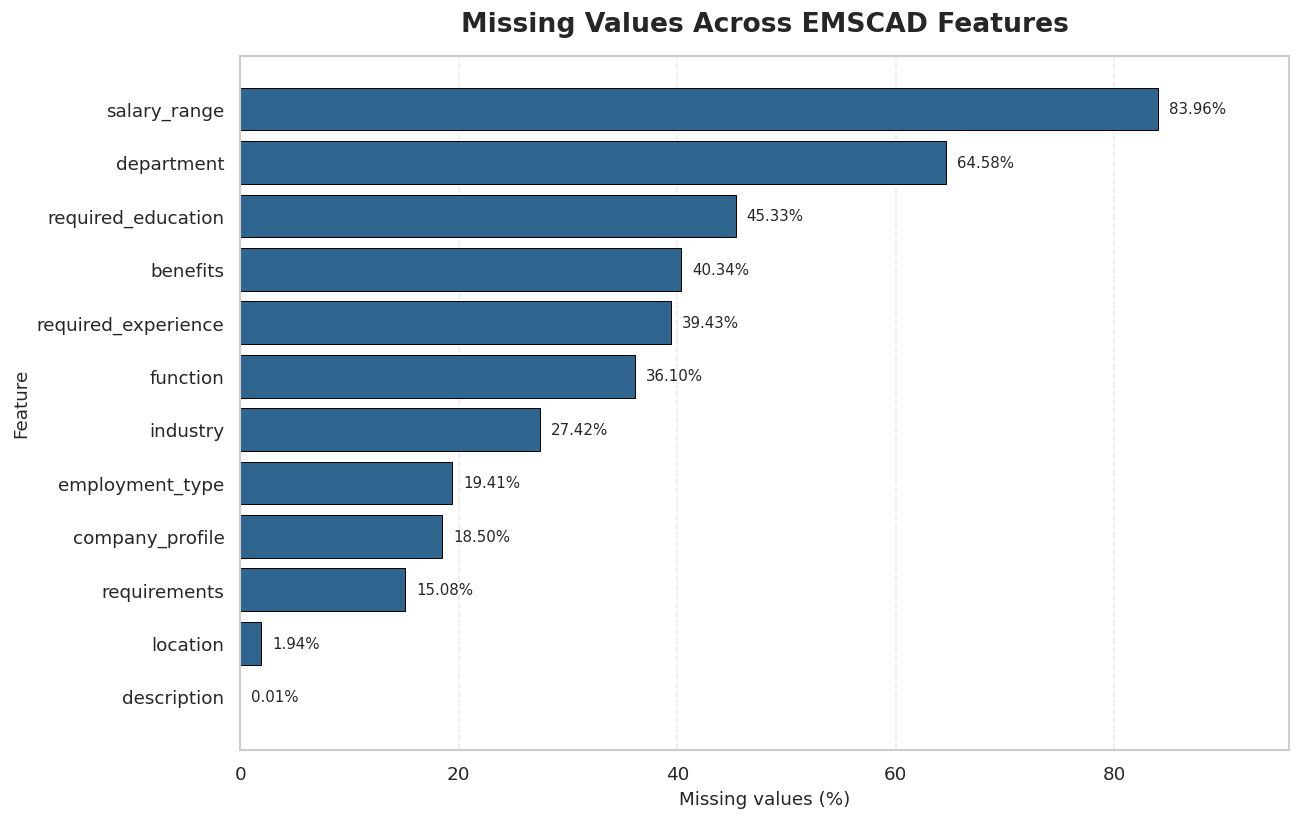

Table saved: /kaggle/working/emscad_complete_eda/tables/missing_values_summary.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/01_missing_values.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/01_missing_values.pdf


In [3]:
# ================================================================
# STEP 3: MISSING-VALUES ANALYSIS AND GRAPH
# ================================================================

import os

EDA_OUTPUT = "/kaggle/working/emscad_complete_eda"
FIGURE_DIR = os.path.join(EDA_OUTPUT, "figures")
TABLE_DIR = os.path.join(EDA_OUTPUT, "tables")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Calculate missing values
missing_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().sum().values / len(df) * 100
    )
})

# Keep only columns containing missing values
missing_summary = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Percentage",
        ascending=True
    )
    .reset_index(drop=True)
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Percentage"].round(2)
)

print("=" * 70)
print("MISSING-VALUES SUMMARY")
print("=" * 70)

display(
    missing_summary.sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

# Save the table
missing_table_path = os.path.join(
    TABLE_DIR,
    "missing_values_summary.csv"
)

missing_summary.to_csv(
    missing_table_path,
    index=False
)

# ------------------------------------------------
# Create the missing-values graph
# ------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    missing_summary["Feature"],
    missing_summary["Missing_Percentage"],
    color="#2F6690",
    edgecolor="black",
    linewidth=0.6
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    missing_summary["Missing_Percentage"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.2f}%",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Missing Values Across EMSCAD Features",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Missing values (%)",
    fontsize=11
)

ax.set_ylabel(
    "Feature",
    fontsize=11
)

ax.set_xlim(
    0,
    max(missing_summary["Missing_Percentage"]) + 12
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax.grid(
    axis="y",
    visible=False
)

plt.tight_layout()

# Save in publication-quality formats
missing_png = os.path.join(
    FIGURE_DIR,
    "01_missing_values.png"
)

missing_pdf = os.path.join(
    FIGURE_DIR,
    "01_missing_values.pdf"
)

plt.savefig(
    missing_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    missing_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", missing_table_path)
print("PNG graph saved:", missing_png)
print("PDF graph saved:", missing_pdf)

TARGET-CLASS DISTRIBUTION


,fraudulent,Class,Count,Percentage
0,0,Genuine,17014,95.16
1,1,Fraudulent,866,4.84


Genuine-to-fraudulent imbalance ratio: 19.65 : 1


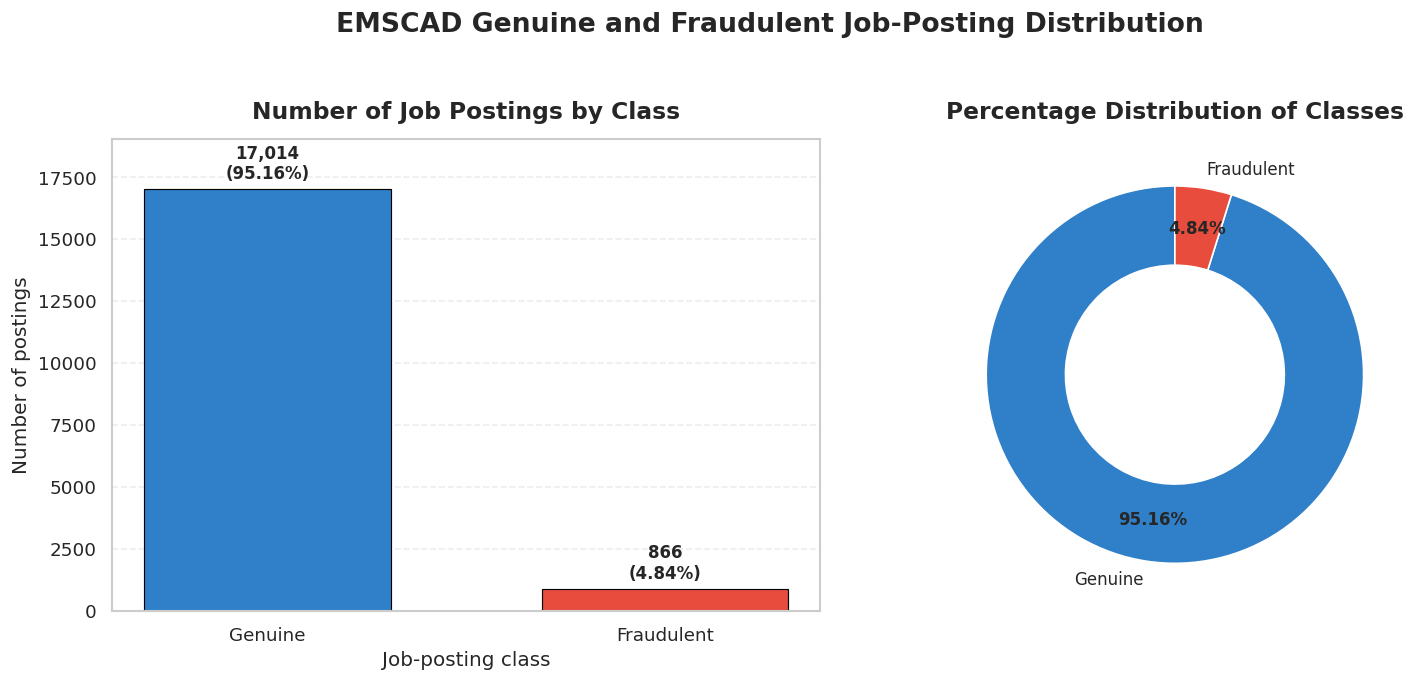

Table saved: /kaggle/working/emscad_complete_eda/tables/class_distribution.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/02_class_distribution.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/02_class_distribution.pdf


In [4]:
# ================================================================
# STEP 4: GENUINE VS FRAUDULENT CLASS DISTRIBUTION
# ================================================================

# Validate target values
target_values = set(
    df["fraudulent"]
    .dropna()
    .unique()
)

if not target_values.issubset({0, 1}):
    raise ValueError(
        "The fraudulent column contains values other than 0 and 1."
    )

# Calculate class counts
class_distribution = (
    df["fraudulent"]
    .value_counts()
    .sort_index()
    .rename_axis("fraudulent")
    .reset_index(name="Count")
)

class_distribution["Class"] = (
    class_distribution["fraudulent"]
    .map({
        0: "Genuine",
        1: "Fraudulent"
    })
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / len(df)
    * 100
).round(2)

class_distribution = class_distribution[
    [
        "fraudulent",
        "Class",
        "Count",
        "Percentage"
    ]
]

# Calculate imbalance ratio
genuine_count = int(
    class_distribution.loc[
        class_distribution["fraudulent"] == 0,
        "Count"
    ].iloc[0]
)

fraud_count = int(
    class_distribution.loc[
        class_distribution["fraudulent"] == 1,
        "Count"
    ].iloc[0]
)

imbalance_ratio = genuine_count / fraud_count

print("=" * 70)
print("TARGET-CLASS DISTRIBUTION")
print("=" * 70)

display(class_distribution)

print(
    f"Genuine-to-fraudulent imbalance ratio: "
    f"{imbalance_ratio:.2f} : 1"
)

# Save the table
class_table_path = os.path.join(
    TABLE_DIR,
    "class_distribution.csv"
)

class_distribution.to_csv(
    class_table_path,
    index=False
)

# ------------------------------------------------
# Create bar chart and donut chart
# ------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5)
)

class_colors = [
    "#2F80C9",
    "#E74C3C"
]

# Bar chart
bars = axes[0].bar(
    class_distribution["Class"],
    class_distribution["Count"],
    color=class_colors,
    edgecolor="black",
    linewidth=0.7,
    width=0.62
)

for bar, count, percentage in zip(
    bars,
    class_distribution["Count"],
    class_distribution["Percentage"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 250,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_title(
    "Number of Job Postings by Class",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel("Job-posting class")
axes[0].set_ylabel("Number of postings")
axes[0].set_ylim(0, genuine_count * 1.12)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0].grid(axis="x", visible=False)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    class_distribution["Count"],
    labels=class_distribution["Class"],
    colors=class_colors,
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 10
    }
)

for autotext in autotexts:
    autotext.set_fontweight("bold")

axes[1].set_title(
    "Percentage Distribution of Classes",
    fontsize=14,
    pad=12
)

fig.suptitle(
    "EMSCAD Genuine and Fraudulent Job-Posting Distribution",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

# Save graphs
class_png = os.path.join(
    FIGURE_DIR,
    "02_class_distribution.png"
)

class_pdf = os.path.join(
    FIGURE_DIR,
    "02_class_distribution.pdf"
)

plt.savefig(
    class_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    class_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", class_table_path)
print("PNG graph saved:", class_png)
print("PDF graph saved:", class_pdf)

DUPLICATE AND REPEATED-CONTENT CHECK


,Check,Count
0,Exact duplicate rows including job_id,0
1,Repeated-content groups excluding job_id,246
2,Rows belonging to repeated-content groups,527
3,Extra repeated copies,281
4,Largest repeated-content group,6
5,Groups having conflicting fraud labels,0
6,Rows belonging to conflicting-label groups,0


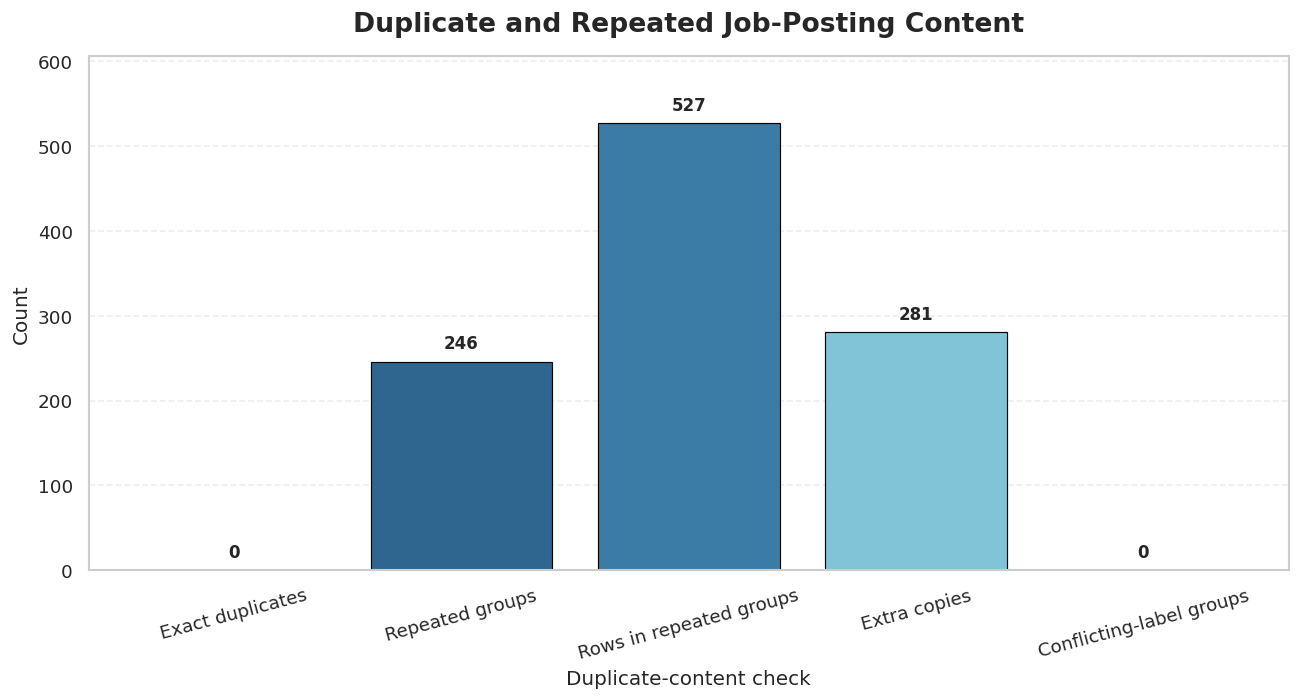

Summary saved: /kaggle/working/emscad_complete_eda/tables/duplicate_content_summary.csv
Repeated groups saved: /kaggle/working/emscad_complete_eda/tables/repeated_content_group_sizes.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/03_duplicate_content_analysis.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/03_duplicate_content_analysis.pdf


In [5]:
# ================================================================
# STEP 5: DUPLICATE AND REPEATED-CONTENT ANALYSIS
# ================================================================

# Features representing the job-posting content
# job_id is excluded because every row may have a different ID.
# fraudulent is excluded so that conflicting labels can be checked.
content_columns = [
    column
    for column in df.columns
    if column not in ["job_id", "fraudulent"]
]

# Prepare content without changing the original dataframe
content_frame = (
    df[content_columns]
    .fillna("__MISSING__")
    .astype(str)
)

# Create a content fingerprint for every row
content_fingerprint = pd.util.hash_pandas_object(
    content_frame,
    index=False
).astype(str)

# Count each repeated-content group
content_group_sizes = (
    content_fingerprint
    .value_counts()
)

repeated_group_sizes = content_group_sizes[
    content_group_sizes > 1
]

# ------------------------------------------------
# Duplicate calculations
# ------------------------------------------------

exact_duplicate_rows = int(
    df.duplicated(keep="first").sum()
)

repeated_content_groups = int(
    len(repeated_group_sizes)
)

rows_in_repeated_groups = int(
    repeated_group_sizes.sum()
)

extra_repeated_copies = int(
    (repeated_group_sizes - 1).sum()
)

largest_repeated_group = int(
    repeated_group_sizes.max()
    if len(repeated_group_sizes) > 0
    else 1
)

# Check whether identical content has different fraud labels
label_check_frame = pd.DataFrame({
    "Content_Fingerprint": content_fingerprint,
    "Fraudulent": df["fraudulent"].values
})

label_counts_per_group = (
    label_check_frame
    .groupby("Content_Fingerprint")["Fraudulent"]
    .nunique()
)

conflicting_label_groups = int(
    (label_counts_per_group > 1).sum()
)

conflicting_fingerprints = (
    label_counts_per_group[
        label_counts_per_group > 1
    ]
    .index
)

rows_in_conflicting_groups = int(
    content_fingerprint
    .isin(conflicting_fingerprints)
    .sum()
)

# ------------------------------------------------
# Create summary table
# ------------------------------------------------

duplicate_summary = pd.DataFrame({
    "Check": [
        "Exact duplicate rows including job_id",
        "Repeated-content groups excluding job_id",
        "Rows belonging to repeated-content groups",
        "Extra repeated copies",
        "Largest repeated-content group",
        "Groups having conflicting fraud labels",
        "Rows belonging to conflicting-label groups"
    ],
    "Count": [
        exact_duplicate_rows,
        repeated_content_groups,
        rows_in_repeated_groups,
        extra_repeated_copies,
        largest_repeated_group,
        conflicting_label_groups,
        rows_in_conflicting_groups
    ]
})

print("=" * 70)
print("DUPLICATE AND REPEATED-CONTENT CHECK")
print("=" * 70)

display(duplicate_summary)

# Save summary table
duplicate_table_path = os.path.join(
    TABLE_DIR,
    "duplicate_content_summary.csv"
)

duplicate_summary.to_csv(
    duplicate_table_path,
    index=False
)

# Save repeated-group sizes
repeated_groups_table = pd.DataFrame({
    "Content_Fingerprint":
        repeated_group_sizes.index.astype(str),
    "Group_Size":
        repeated_group_sizes.values
})

repeated_groups_path = os.path.join(
    TABLE_DIR,
    "repeated_content_group_sizes.csv"
)

repeated_groups_table.to_csv(
    repeated_groups_path,
    index=False
)

# ------------------------------------------------
# Create duplicate-analysis graph
# ------------------------------------------------

graph_data = duplicate_summary[
    duplicate_summary["Check"].isin([
        "Exact duplicate rows including job_id",
        "Repeated-content groups excluding job_id",
        "Rows belonging to repeated-content groups",
        "Extra repeated copies",
        "Groups having conflicting fraud labels"
    ])
].copy()

short_names = {
    "Exact duplicate rows including job_id":
        "Exact duplicates",
    "Repeated-content groups excluding job_id":
        "Repeated groups",
    "Rows belonging to repeated-content groups":
        "Rows in repeated groups",
    "Extra repeated copies":
        "Extra copies",
    "Groups having conflicting fraud labels":
        "Conflicting-label groups"
}

graph_data["Graph_Label"] = (
    graph_data["Check"].map(short_names)
)

fig, ax = plt.subplots(figsize=(11, 6))

colors = [
    "#7A9E9F",
    "#2F6690",
    "#3A7CA5",
    "#81C3D7",
    "#E74C3C"
]

bars = ax.bar(
    graph_data["Graph_Label"],
    graph_data["Count"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

for bar, count in zip(
    bars,
    graph_data["Count"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(graph_data["Count"]) * 0.02,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Duplicate and Repeated Job-Posting Content",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Duplicate-content check")
ax.set_ylabel("Count")

ax.tick_params(
    axis="x",
    rotation=15
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_ylim(
    0,
    max(graph_data["Count"]) * 1.15
)

plt.tight_layout()

duplicate_png = os.path.join(
    FIGURE_DIR,
    "03_duplicate_content_analysis.png"
)

duplicate_pdf = os.path.join(
    FIGURE_DIR,
    "03_duplicate_content_analysis.pdf"
)

plt.savefig(
    duplicate_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    duplicate_pdf,
    bbox_inches="tight"
)

plt.show()

print("Summary saved:", duplicate_table_path)
print("Repeated groups saved:", repeated_groups_path)
print("PNG graph saved:", duplicate_png)
print("PDF graph saved:", duplicate_pdf)

BINARY METADATA FRAUD-RATE ANALYSIS
Overall dataset fraud rate: 4.84%


,Feature,Feature_Name,Value,Category,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
0,telecommuting,Telecommuting,0,No,17113,802,4.69,0.97
1,telecommuting,Telecommuting,1,Yes,767,64,8.34,1.72
2,has_company_logo,Company Logo,0,No,3660,583,15.93,3.29
3,has_company_logo,Company Logo,1,Yes,14220,283,1.99,0.41
4,has_questions,Screening Questions,0,No,9088,616,6.78,1.40
5,has_questions,Screening Questions,1,Yes,8792,250,2.84,0.59


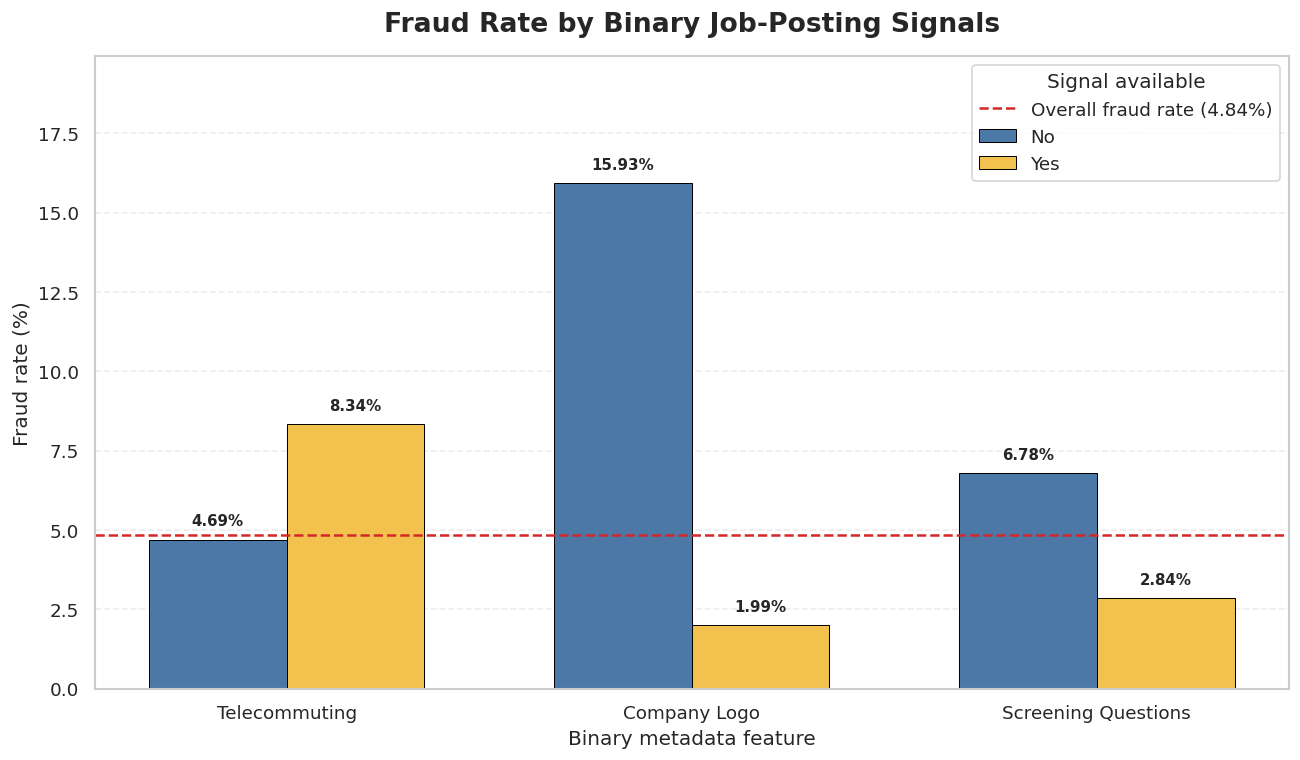

Table saved: /kaggle/working/emscad_complete_eda/tables/binary_metadata_fraud_rates.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/04_binary_metadata_fraud_rates.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/04_binary_metadata_fraud_rates.pdf


In [6]:
# ================================================================
# STEP 6: BINARY METADATA FRAUD-RATE ANALYSIS
# ================================================================

binary_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

feature_display_names = {
    "telecommuting": "Telecommuting",
    "has_company_logo": "Company Logo",
    "has_questions": "Screening Questions"
}

value_names = {
    0: "No",
    1: "Yes"
}

global_fraud_rate = (
    df["fraudulent"].mean() * 100
)

binary_rows = []

for feature in binary_features:

    grouped = (
        df.groupby(
            feature,
            dropna=False
        )["fraudulent"]
        .agg(
            Total_Posts="count",
            Fraudulent_Posts="sum"
        )
        .reset_index()
    )

    grouped["Fraud_Rate_Percentage"] = (
        grouped["Fraudulent_Posts"]
        / grouped["Total_Posts"]
        * 100
    )

    grouped["Risk_Lift"] = (
        grouped["Fraud_Rate_Percentage"]
        / global_fraud_rate
    )

    for _, row in grouped.iterrows():

        binary_rows.append({
            "Feature": feature,
            "Feature_Name":
                feature_display_names[feature],
            "Value": int(row[feature]),
            "Category":
                value_names.get(
                    int(row[feature]),
                    str(row[feature])
                ),
            "Total_Posts":
                int(row["Total_Posts"]),
            "Fraudulent_Posts":
                int(row["Fraudulent_Posts"]),
            "Fraud_Rate_Percentage":
                round(
                    row["Fraud_Rate_Percentage"],
                    2
                ),
            "Risk_Lift":
                round(row["Risk_Lift"], 2)
        })

binary_fraud_summary = pd.DataFrame(
    binary_rows
)

print("=" * 70)
print("BINARY METADATA FRAUD-RATE ANALYSIS")
print("=" * 70)

print(
    f"Overall dataset fraud rate: "
    f"{global_fraud_rate:.2f}%"
)

display(binary_fraud_summary)

# Save table
binary_table_path = os.path.join(
    TABLE_DIR,
    "binary_metadata_fraud_rates.csv"
)

binary_fraud_summary.to_csv(
    binary_table_path,
    index=False
)

# ------------------------------------------------
# Create grouped fraud-rate graph
# ------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

x_positions = np.arange(
    len(binary_features)
)

bar_width = 0.34

no_values = []
yes_values = []

for feature in binary_features:

    feature_data = binary_fraud_summary[
        binary_fraud_summary["Feature"]
        == feature
    ]

    no_rate = feature_data.loc[
        feature_data["Value"] == 0,
        "Fraud_Rate_Percentage"
    ].iloc[0]

    yes_rate = feature_data.loc[
        feature_data["Value"] == 1,
        "Fraud_Rate_Percentage"
    ].iloc[0]

    no_values.append(no_rate)
    yes_values.append(yes_rate)

no_bars = ax.bar(
    x_positions - bar_width / 2,
    no_values,
    width=bar_width,
    label="No",
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.6
)

yes_bars = ax.bar(
    x_positions + bar_width / 2,
    yes_values,
    width=bar_width,
    label="Yes",
    color="#F2C14E",
    edgecolor="black",
    linewidth=0.6
)

# Add percentage labels
for bars in [no_bars, yes_bars]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.35,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# Overall fraud-rate reference line
ax.axhline(
    global_fraud_rate,
    color="#D62728",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall fraud rate "
        f"({global_fraud_rate:.2f}%)"
    )
)

ax.set_title(
    "Fraud Rate by Binary Job-Posting Signals",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Binary metadata feature")
ax.set_ylabel("Fraud rate (%)")

ax.set_xticks(x_positions)

ax.set_xticklabels([
    feature_display_names[feature]
    for feature in binary_features
])

ax.set_ylim(
    0,
    max(no_values + yes_values) + 4
)

ax.legend(
    title="Signal available",
    frameon=True
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()

binary_png = os.path.join(
    FIGURE_DIR,
    "04_binary_metadata_fraud_rates.png"
)

binary_pdf = os.path.join(
    FIGURE_DIR,
    "04_binary_metadata_fraud_rates.pdf"
)

plt.savefig(
    binary_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    binary_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", binary_table_path)
print("PNG graph saved:", binary_png)
print("PDF graph saved:", binary_pdf)

MISSINGNESS AND FRAUD-RISK ANALYSIS
Positive rate difference: fraud is more common when the feature is missing.
Negative rate difference: fraud is less common when the feature is missing.


,Feature,Missing_Count,Missing_Fraudulent_Posts,Missing_Fraud_Rate,Present_Count,Present_Fraudulent_Posts,Present_Fraud_Rate,Rate_Difference
0,description,2,2,100.00,17878,864,4.83,95.17
1,company_profile,3308,587,17.74,14572,279,1.91,15.83
2,employment_type,3471,241,6.94,14409,625,4.34,2.61
3,required_experience,7050,435,6.17,10830,431,3.98,2.19
4,required_education,8105,451,5.56,9775,415,4.25,1.32
5,industry,4903,275,5.61,12977,591,4.55,1.05
6,requirements,2698,154,5.71,15182,712,4.69,1.02
7,location,346,19,5.49,17534,847,4.83,0.66
8,function,6455,337,5.22,11425,529,4.63,0.59
9,benefits,7220,364,5.04,10660,502,4.71,0.33


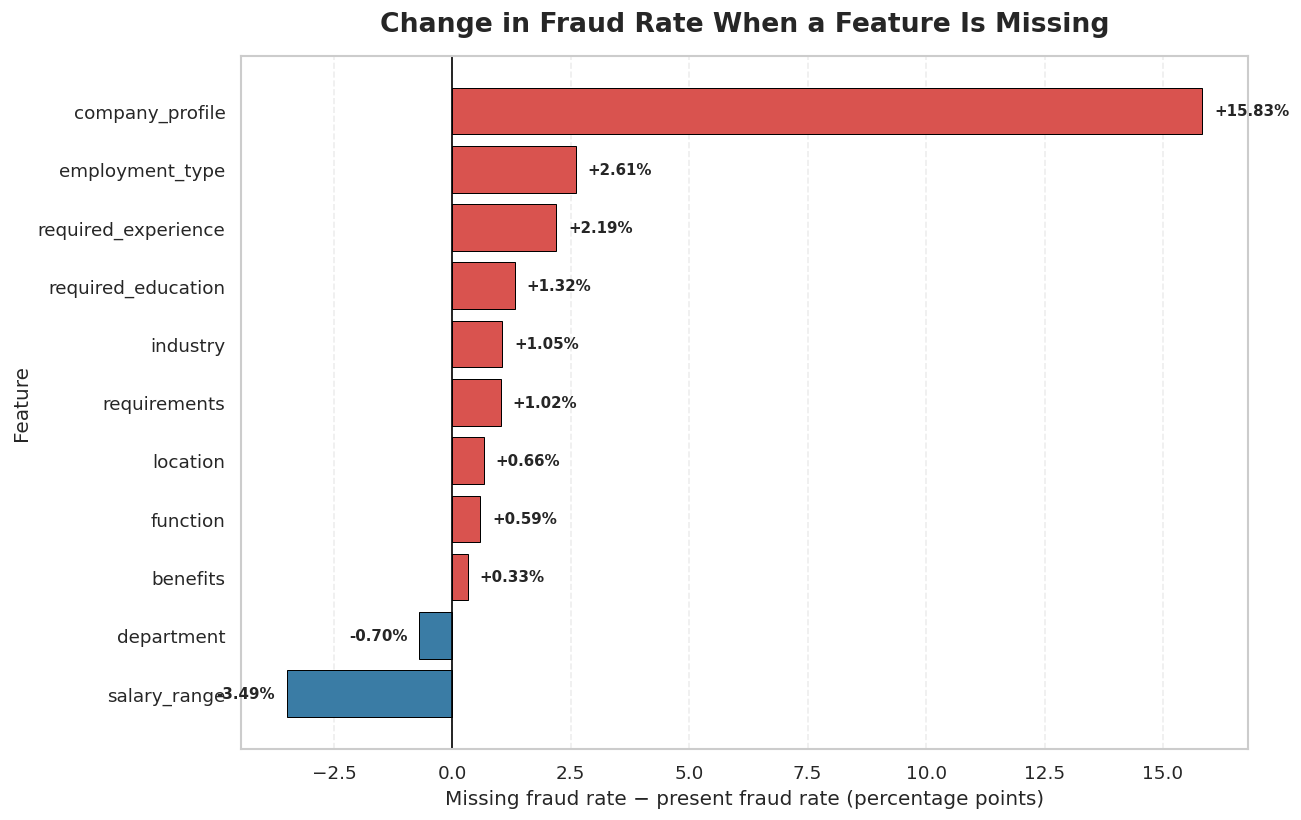

Table saved: /kaggle/working/emscad_complete_eda/tables/missingness_fraud_signal.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/05_missingness_fraud_signal.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/05_missingness_fraud_signal.pdf


In [7]:
# ================================================================
# STEP 7: MISSINGNESS AS A FRAUD SIGNAL
# ================================================================

missing_fraud_rows = []

input_features = [
    column
    for column in df.columns
    if column not in ["job_id", "fraudulent"]
]

for feature in input_features:

    # Detect NaN and empty-string values
    missing_mask = (
        df[feature].isna()
        | df[feature]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    )

    present_mask = ~missing_mask

    missing_count = int(
        missing_mask.sum()
    )

    present_count = int(
        present_mask.sum()
    )

    if missing_count > 0:

        missing_fraud_count = int(
            df.loc[
                missing_mask,
                "fraudulent"
            ].sum()
        )

        missing_fraud_rate = (
            df.loc[
                missing_mask,
                "fraudulent"
            ].mean()
            * 100
        )

    else:

        missing_fraud_count = 0
        missing_fraud_rate = np.nan

    if present_count > 0:

        present_fraud_count = int(
            df.loc[
                present_mask,
                "fraudulent"
            ].sum()
        )

        present_fraud_rate = (
            df.loc[
                present_mask,
                "fraudulent"
            ].mean()
            * 100
        )

    else:

        present_fraud_count = 0
        present_fraud_rate = np.nan

    rate_difference = (
        missing_fraud_rate
        - present_fraud_rate
        if missing_count > 0
        else np.nan
    )

    missing_fraud_rows.append({
        "Feature": feature,
        "Missing_Count": missing_count,
        "Missing_Fraudulent_Posts":
            missing_fraud_count,
        "Missing_Fraud_Rate":
            round(missing_fraud_rate, 2)
            if not np.isnan(missing_fraud_rate)
            else np.nan,
        "Present_Count": present_count,
        "Present_Fraudulent_Posts":
            present_fraud_count,
        "Present_Fraud_Rate":
            round(present_fraud_rate, 2),
        "Rate_Difference":
            round(rate_difference, 2)
            if not np.isnan(rate_difference)
            else np.nan
    })

missing_fraud_summary = (
    pd.DataFrame(missing_fraud_rows)
    .query("Missing_Count > 0")
    .sort_values(
        "Rate_Difference",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("MISSINGNESS AND FRAUD-RISK ANALYSIS")
print("=" * 70)

print(
    "Positive rate difference: fraud is more common "
    "when the feature is missing."
)

print(
    "Negative rate difference: fraud is less common "
    "when the feature is missing."
)

display(missing_fraud_summary)

# Save complete table
missing_fraud_table_path = os.path.join(
    TABLE_DIR,
    "missingness_fraud_signal.csv"
)

missing_fraud_summary.to_csv(
    missing_fraud_table_path,
    index=False
)

# ------------------------------------------------
# Use at least 30 missing rows for a stable graph
# ------------------------------------------------

graph_data = (
    missing_fraud_summary[
        missing_fraud_summary["Missing_Count"]
        >= 30
    ]
    .sort_values(
        "Rate_Difference",
        ascending=True
    )
    .copy()
)

graph_colors = [
    "#D9534F"
    if difference > 0
    else "#3A7CA5"
    for difference
    in graph_data["Rate_Difference"]
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    graph_data["Feature"],
    graph_data["Rate_Difference"],
    color=graph_colors,
    edgecolor="black",
    linewidth=0.6
)

# Add value labels
for bar, difference in zip(
    bars,
    graph_data["Rate_Difference"]
):

    if difference >= 0:

        text_x = difference + 0.25
        alignment = "left"

    else:

        text_x = difference - 0.25
        alignment = "right"

    ax.text(
        text_x,
        bar.get_y() + bar.get_height() / 2,
        f"{difference:+.2f}%",
        va="center",
        ha=alignment,
        fontsize=9,
        fontweight="bold"
    )

ax.axvline(
    0,
    color="black",
    linewidth=1
)

ax.set_title(
    "Change in Fraud Rate When a Feature Is Missing",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Missing fraud rate − present fraud rate "
    "(percentage points)"
)

ax.set_ylabel("Feature")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.grid(
    axis="y",
    visible=False
)

plt.tight_layout()

missing_signal_png = os.path.join(
    FIGURE_DIR,
    "05_missingness_fraud_signal.png"
)

missing_signal_pdf = os.path.join(
    FIGURE_DIR,
    "05_missingness_fraud_signal.pdf"
)

plt.savefig(
    missing_signal_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    missing_signal_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", missing_fraud_table_path)
print("PNG graph saved:", missing_signal_png)
print("PDF graph saved:", missing_signal_pdf)

MISSING FIELDS PER POSTING VS FRAUD RATE


,Missing_Fields,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage
0,0,773,71,9.18
1,1,2308,100,4.33
2,2,3310,112,3.38
3,3,3091,77,2.49
4,4,2211,57,2.58
5,5,1169,65,5.56
6,6,1376,84,6.10
7,7,1422,98,6.89
8,8,1293,130,10.05
9,9,604,29,4.80


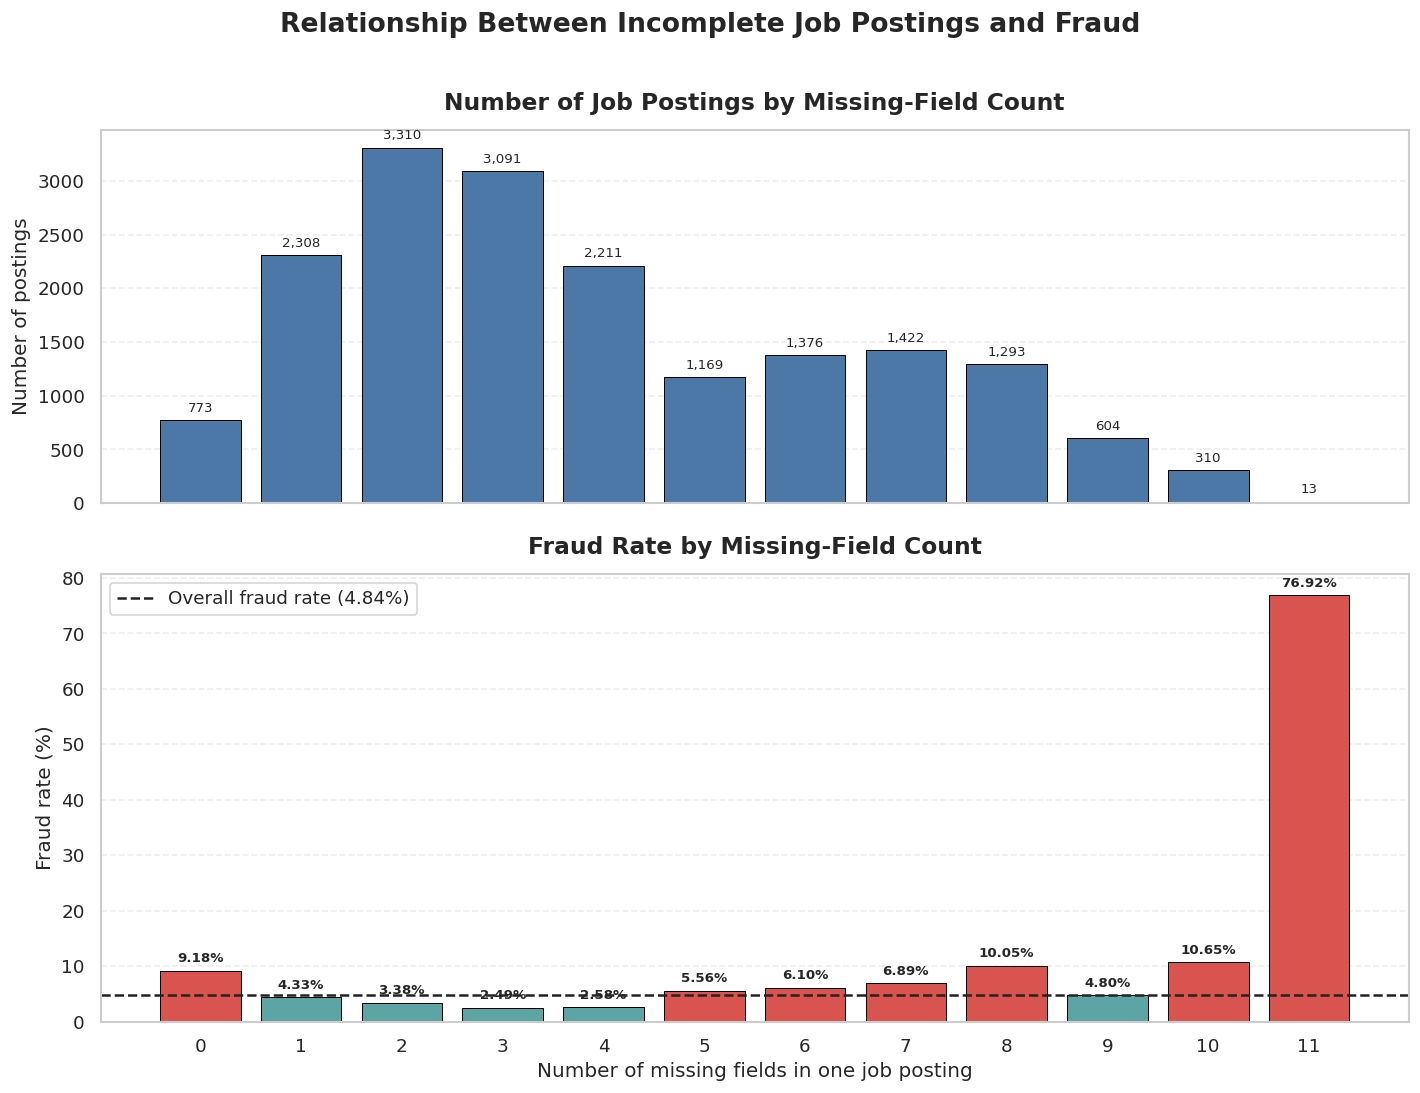

Table saved: /kaggle/working/emscad_complete_eda/tables/missing_fields_per_row_fraud_rate.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/06_missing_field_count_vs_fraud.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/06_missing_field_count_vs_fraud.pdf


In [8]:
# ================================================================
# STEP 8: MISSING-FIELD COUNT PER ROW VS FRAUD RATE
# ================================================================

analysis_features = [
    column
    for column in df.columns
    if column not in ["job_id", "fraudulent"]
]

# Build a missing-value matrix
missing_matrix = pd.DataFrame(
    index=df.index
)

for feature in analysis_features:

    missing_matrix[feature] = (
        df[feature].isna()
        | df[feature]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    )

# Count missing fields in each job posting
missing_fields_per_row = (
    missing_matrix.sum(axis=1)
)

# Create analysis dataframe without modifying df
row_missing_analysis = pd.DataFrame({
    "Missing_Fields": missing_fields_per_row,
    "Fraudulent": df["fraudulent"].values
})

# Calculate fraud rate for each missing-field count
missing_count_summary = (
    row_missing_analysis
    .groupby("Missing_Fields")["Fraudulent"]
    .agg(
        Total_Posts="count",
        Fraudulent_Posts="sum"
    )
    .reset_index()
)

missing_count_summary[
    "Fraud_Rate_Percentage"
] = (
    missing_count_summary["Fraudulent_Posts"]
    / missing_count_summary["Total_Posts"]
    * 100
).round(2)

print("=" * 70)
print("MISSING FIELDS PER POSTING VS FRAUD RATE")
print("=" * 70)

display(missing_count_summary)

# Save table
missing_count_table_path = os.path.join(
    TABLE_DIR,
    "missing_fields_per_row_fraud_rate.csv"
)

missing_count_summary.to_csv(
    missing_count_table_path,
    index=False
)

# ------------------------------------------------
# Create two-panel graph
# ------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1, 1.2]
    }
)

# Panel 1: number of postings
bars_1 = axes[0].bar(
    missing_count_summary["Missing_Fields"],
    missing_count_summary["Total_Posts"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.6
)

for bar, count in zip(
    bars_1,
    missing_count_summary["Total_Posts"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

axes[0].set_title(
    "Number of Job Postings by Missing-Field Count",
    fontsize=14,
    pad=12
)

axes[0].set_ylabel("Number of postings")

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

axes[0].grid(
    axis="x",
    visible=False
)

# Panel 2: fraud rate
fraud_rate_colors = [
    "#D9534F"
    if rate > global_fraud_rate
    else "#5DA5A4"
    for rate
    in missing_count_summary[
        "Fraud_Rate_Percentage"
    ]
]

bars_2 = axes[1].bar(
    missing_count_summary["Missing_Fields"],
    missing_count_summary[
        "Fraud_Rate_Percentage"
    ],
    color=fraud_rate_colors,
    edgecolor="black",
    linewidth=0.6
)

for bar, rate in zip(
    bars_2,
    missing_count_summary[
        "Fraud_Rate_Percentage"
    ]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

axes[1].axhline(
    global_fraud_rate,
    color="#222222",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall fraud rate "
        f"({global_fraud_rate:.2f}%)"
    )
)

axes[1].set_title(
    "Fraud Rate by Missing-Field Count",
    fontsize=14,
    pad=12
)

axes[1].set_xlabel(
    "Number of missing fields in one job posting"
)

axes[1].set_ylabel("Fraud rate (%)")

axes[1].set_xticks(
    missing_count_summary["Missing_Fields"]
)

axes[1].legend()

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

axes[1].grid(
    axis="x",
    visible=False
)

fig.suptitle(
    "Relationship Between Incomplete Job Postings and Fraud",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

missing_count_png = os.path.join(
    FIGURE_DIR,
    "06_missing_field_count_vs_fraud.png"
)

missing_count_pdf = os.path.join(
    FIGURE_DIR,
    "06_missing_field_count_vs_fraud.pdf"
)

plt.savefig(
    missing_count_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    missing_count_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", missing_count_table_path)
print("PNG graph saved:", missing_count_png)
print("PDF graph saved:", missing_count_pdf)

TEXT-LENGTH SUMMARY BY CLASS


,Feature,Class,Total_Posts,Missing_or_Empty,Mean_Words,Median_Words,P75_Words,Mean_Characters,Median_Characters
0,title,Genuine,17014,0,3.64,3.0,4.00,28.29,25.0
1,title,Fraudulent,866,0,4.10,3.0,5.00,30.43,28.0
2,company_profile,Genuine,17014,2721,97.53,86.0,140.00,640.56,587.0
3,company_profile,Fraudulent,866,587,32.14,0.0,56.00,228.42,0.0
4,description,Genuine,17014,0,176.58,152.0,231.00,1219.96,1027.0
5,description,Fraudulent,866,2,163.35,115.0,227.00,1154.26,844.5
6,requirements,Genuine,17014,2544,82.19,66.0,114.00,597.25,476.0
7,requirements,Fraudulent,866,154,60.55,34.0,87.75,445.73,249.0
8,benefits,Genuine,17014,6856,30.96,6.0,43.00,208.63,46.5
9,benefits,Fraudulent,866,364,30.12,5.0,36.00,210.12,36.0


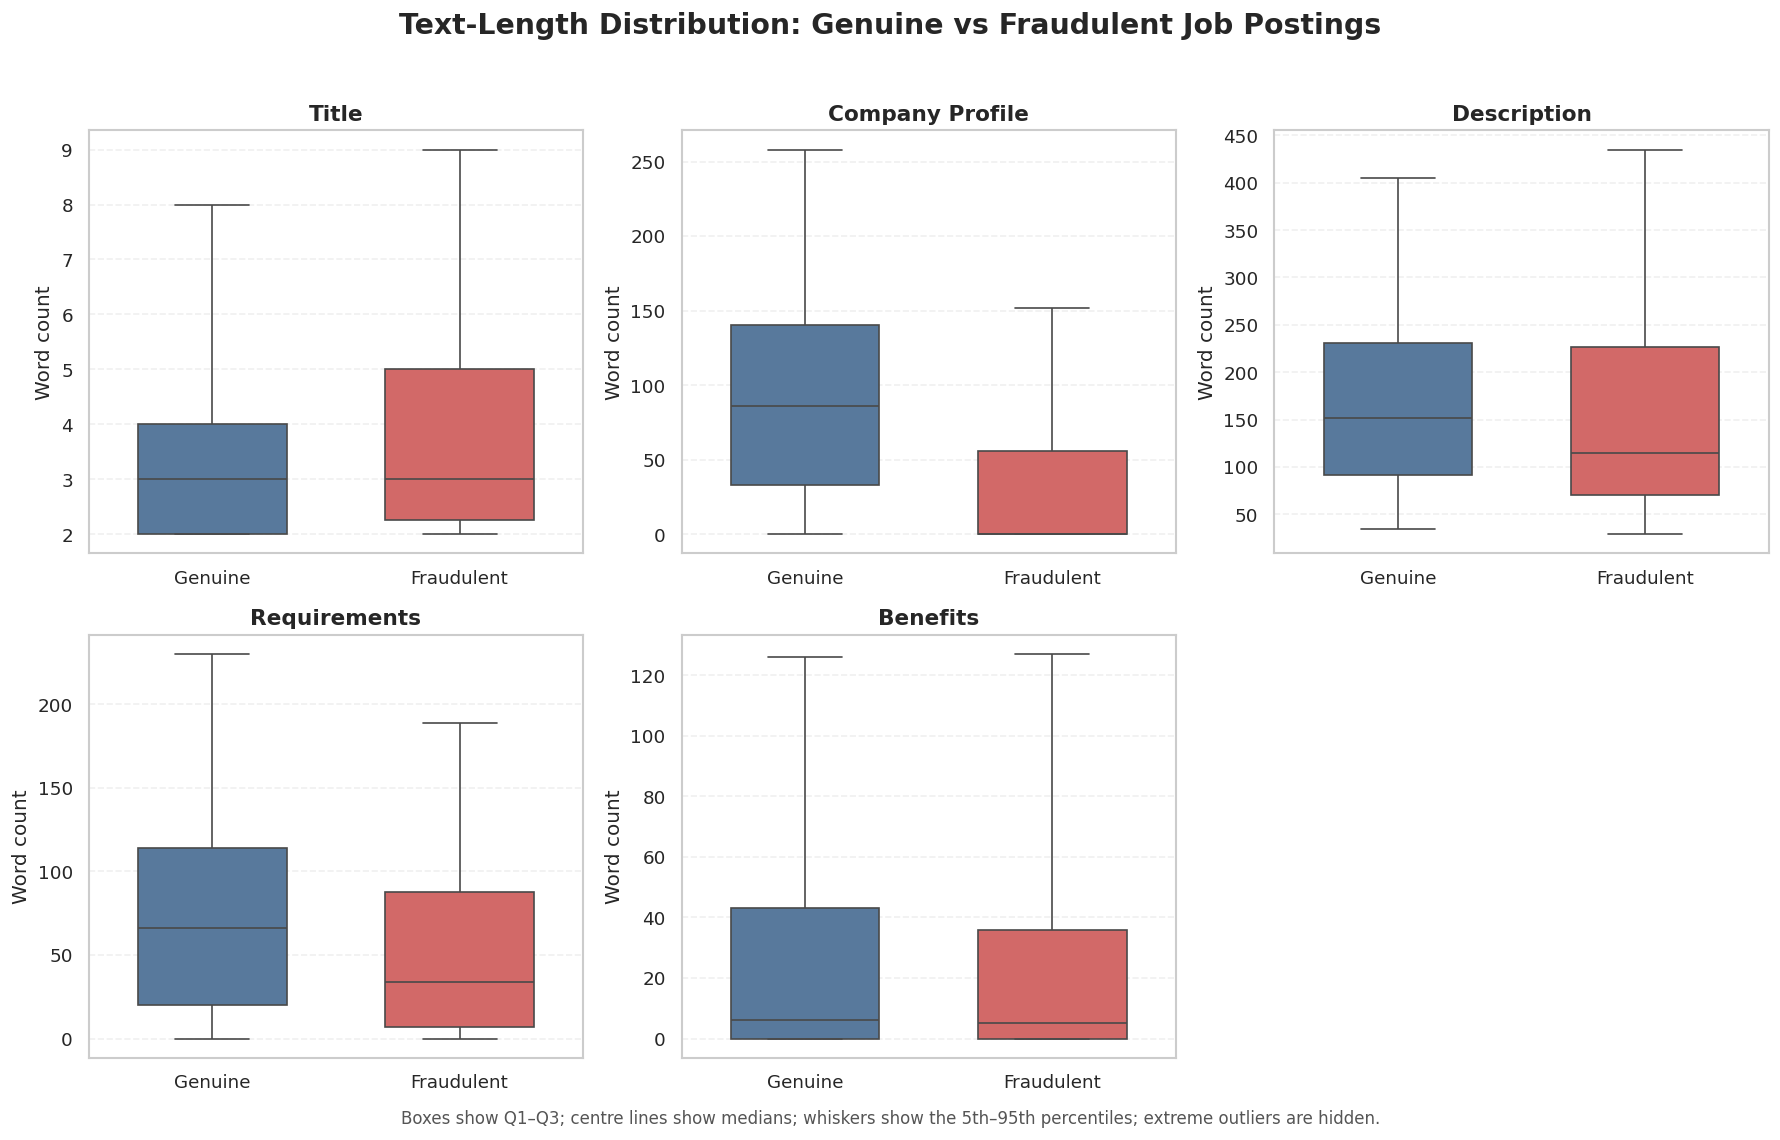

Summary saved: /kaggle/working/emscad_complete_eda/tables/text_length_summary_by_class.csv
Row-level data saved: /kaggle/working/emscad_complete_eda/tables/text_length_row_data.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/07_text_length_boxplots.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/07_text_length_boxplots.pdf


In [9]:
# ================================================================
# STEP 9: TEXT-LENGTH ANALYSIS BY CLASS
# ================================================================

text_features = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

text_length_frames = []
text_summary_rows = []

for feature in text_features:

    cleaned_text = (
        df[feature]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    word_count = (
        cleaned_text
        .str.findall(r"\b[\w'-]+\b")
        .str.len()
    )

    character_count = (
        cleaned_text.str.len()
    )

    feature_frame = pd.DataFrame({
        "source_row_index": df.index,
        "job_id": df["job_id"].values,
        "Feature": feature,
        "Fraudulent": df["fraudulent"].values,
        "Class": df["fraudulent"].map({
            0: "Genuine",
            1: "Fraudulent"
        }),
        "Word_Count": word_count.values,
        "Character_Count": character_count.values,
        "Missing_or_Empty":
            cleaned_text.eq("").values
    })

    text_length_frames.append(
        feature_frame
    )

    for class_value, class_name in [
        (0, "Genuine"),
        (1, "Fraudulent")
    ]:

        class_data = feature_frame[
            feature_frame["Fraudulent"]
            == class_value
        ]

        text_summary_rows.append({
            "Feature": feature,
            "Class": class_name,
            "Total_Posts":
                int(len(class_data)),
            "Missing_or_Empty":
                int(
                    class_data[
                        "Missing_or_Empty"
                    ].sum()
                ),
            "Mean_Words":
                round(
                    class_data[
                        "Word_Count"
                    ].mean(),
                    2
                ),
            "Median_Words":
                round(
                    class_data[
                        "Word_Count"
                    ].median(),
                    2
                ),
            "P75_Words":
                round(
                    class_data[
                        "Word_Count"
                    ].quantile(0.75),
                    2
                ),
            "Mean_Characters":
                round(
                    class_data[
                        "Character_Count"
                    ].mean(),
                    2
                ),
            "Median_Characters":
                round(
                    class_data[
                        "Character_Count"
                    ].median(),
                    2
                )
        })

text_length_data = pd.concat(
    text_length_frames,
    ignore_index=True
)

text_length_summary = pd.DataFrame(
    text_summary_rows
)

print("=" * 70)
print("TEXT-LENGTH SUMMARY BY CLASS")
print("=" * 70)

display(text_length_summary)

# Save tables
text_summary_path = os.path.join(
    TABLE_DIR,
    "text_length_summary_by_class.csv"
)

text_data_path = os.path.join(
    TABLE_DIR,
    "text_length_row_data.csv"
)

text_length_summary.to_csv(
    text_summary_path,
    index=False
)

text_length_data.to_csv(
    text_data_path,
    index=False
)

# ------------------------------------------------
# Create separate box plots for each text field
# ------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

class_palette = {
    "Genuine": "#4C78A8",
    "Fraudulent": "#E45756"
}

for index, feature in enumerate(
    text_features
):

    feature_plot_data = text_length_data[
        text_length_data["Feature"]
        == feature
    ]

    sns.boxplot(
        data=feature_plot_data,
        x="Class",
        y="Word_Count",
        order=[
            "Genuine",
            "Fraudulent"
        ],
        palette=class_palette,
        showfliers=False,
        whis=(5, 95),
        width=0.6,
        linewidth=1,
        ax=axes[index]
    )

    axes[index].set_title(
        feature.replace("_", " ").title(),
        fontsize=13,
        fontweight="bold"
    )

    axes[index].set_xlabel("")
    axes[index].set_ylabel("Word count")

    axes[index].grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    axes[index].grid(
        axis="x",
        visible=False
    )

# Remove unused sixth panel
fig.delaxes(axes[-1])

fig.suptitle(
    "Text-Length Distribution: Genuine vs Fraudulent Job Postings",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Boxes show Q1–Q3; centre lines show medians; "
    "whiskers show the 5th–95th percentiles; "
    "extreme outliers are hidden.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

text_length_png = os.path.join(
    FIGURE_DIR,
    "07_text_length_boxplots.png"
)

text_length_pdf = os.path.join(
    FIGURE_DIR,
    "07_text_length_boxplots.pdf"
)

plt.savefig(
    text_length_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    text_length_pdf,
    bbox_inches="tight"
)

plt.show()

print("Summary saved:", text_summary_path)
print("Row-level data saved:", text_data_path)
print("PNG graph saved:", text_length_png)
print("PDF graph saved:", text_length_pdf)

CATEGORICAL FEATURE FRAUD-RATE ANALYSIS

 Employment Type


,Feature,Category,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
4,employment_type,Part-time,797,74,9.28,1.92
2,employment_type,Missing,3471,241,6.94,1.43
3,employment_type,Other,227,15,6.61,1.36
1,employment_type,Full-time,11620,490,4.22,0.87
0,employment_type,Contract,1524,44,2.89,0.60
5,employment_type,Temporary,241,2,0.83,0.17



 Required Experience


,Feature,Category,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
9,required_experience,Executive,141,10,7.09,1.46
8,required_experience,Entry level,2697,179,6.64,1.37
12,required_experience,Missing,7050,435,6.17,1.27
13,required_experience,Not Applicable,1116,60,5.38,1.11
7,required_experience,Director,389,17,4.37,0.90
11,required_experience,Mid-Senior level,3809,113,2.97,0.61
10,required_experience,Internship,381,10,2.62,0.54
6,required_experience,Associate,2297,42,1.83,0.38



 Required Education


,Feature,Category,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
23,required_education,Some High School Coursework,27,20,74.07,15.29
16,required_education,Certification,170,19,11.18,2.31
18,required_education,High School or equivalent,2080,170,8.17,1.69
19,required_education,Master's Degree,416,31,7.45,1.54
20,required_education,Missing,8105,451,5.56,1.15
21,required_education,Professional,74,4,5.41,1.12
24,required_education,Unspecified,1397,61,4.37,0.90
17,required_education,Doctorate,26,1,3.85,0.79
22,required_education,Some College Coursework Completed,102,3,2.94,0.61
14,required_education,Associate Degree,274,6,2.19,0.45


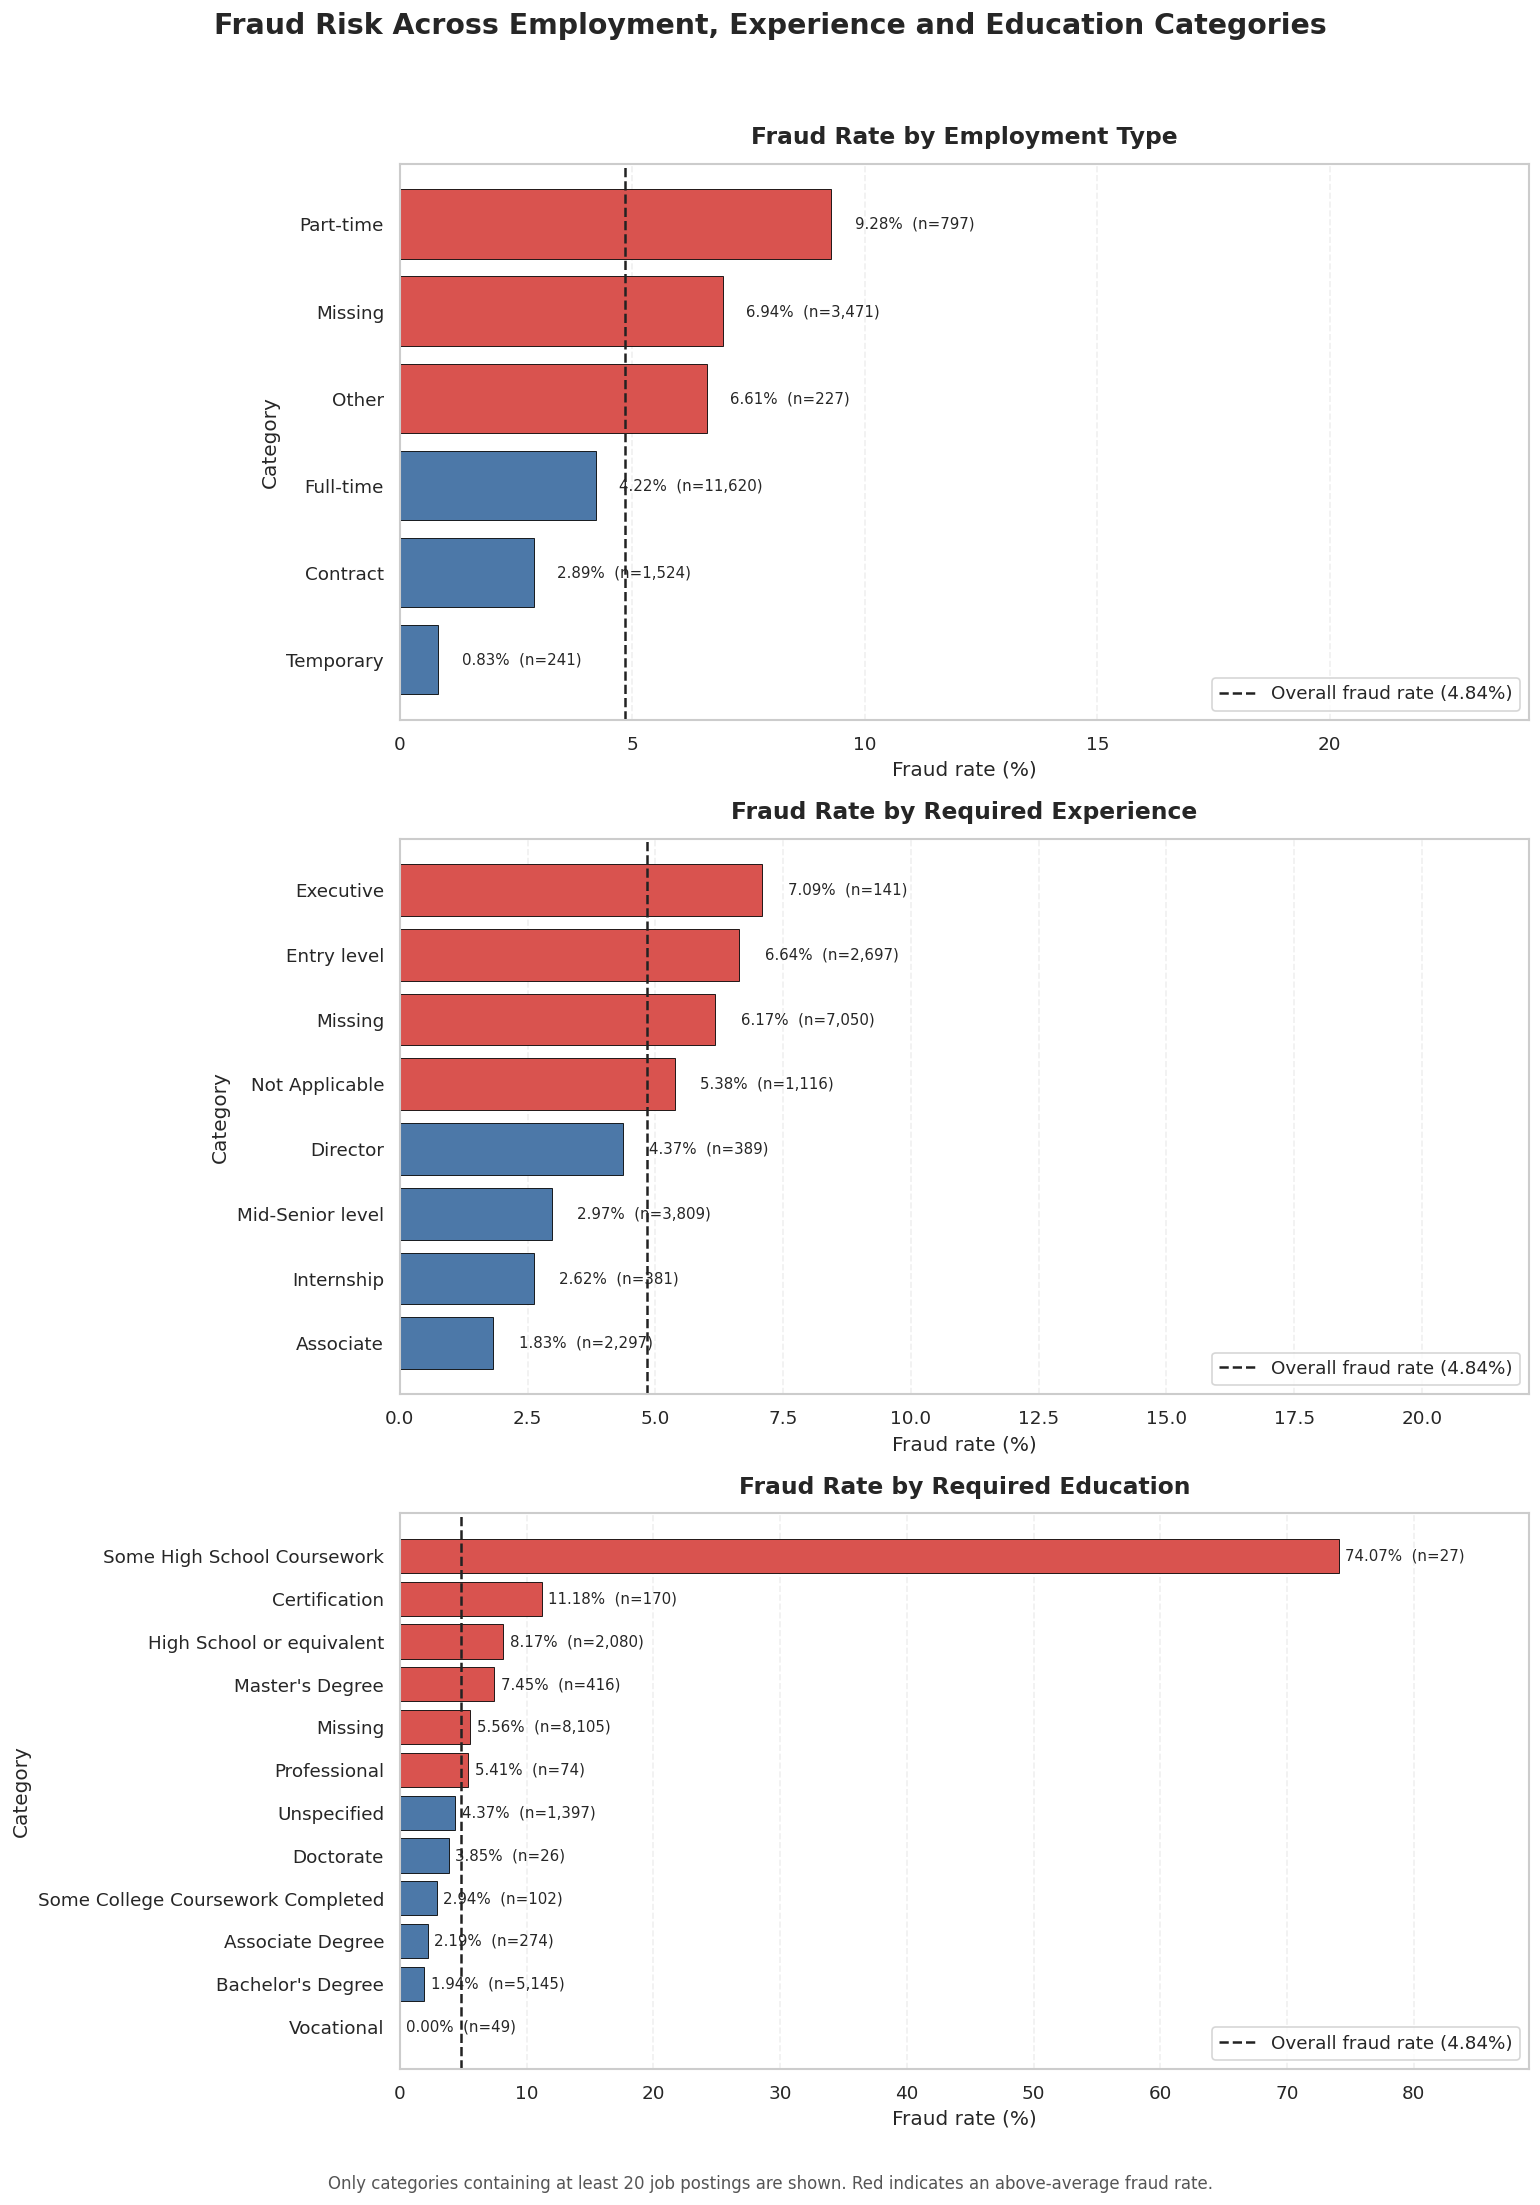

Table saved: /kaggle/working/emscad_complete_eda/tables/categorical_feature_fraud_rates.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/08_categorical_feature_fraud_rates.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/08_categorical_feature_fraud_rates.pdf


In [10]:
# ================================================================
# STEP 10: CATEGORICAL FEATURE FRAUD-RATE ANALYSIS
# ================================================================

categorical_features = [
    "employment_type",
    "required_experience",
    "required_education"
]

categorical_display_names = {
    "employment_type": "Employment Type",
    "required_experience": "Required Experience",
    "required_education": "Required Education"
}

categorical_summary_frames = []

for feature in categorical_features:

    category_values = (
        df[feature]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
    )

    feature_summary = (
        pd.DataFrame({
            "Category": category_values,
            "Fraudulent":
                df["fraudulent"].values
        })
        .groupby(
            "Category",
            dropna=False
        )["Fraudulent"]
        .agg(
            Total_Posts="count",
            Fraudulent_Posts="sum"
        )
        .reset_index()
    )

    feature_summary[
        "Fraud_Rate_Percentage"
    ] = (
        feature_summary[
            "Fraudulent_Posts"
        ]
        / feature_summary["Total_Posts"]
        * 100
    ).round(2)

    feature_summary["Risk_Lift"] = (
        feature_summary[
            "Fraud_Rate_Percentage"
        ]
        / global_fraud_rate
    ).round(2)

    feature_summary.insert(
        0,
        "Feature",
        feature
    )

    categorical_summary_frames.append(
        feature_summary
    )

categorical_fraud_summary = pd.concat(
    categorical_summary_frames,
    ignore_index=True
)

print("=" * 70)
print("CATEGORICAL FEATURE FRAUD-RATE ANALYSIS")
print("=" * 70)

for feature in categorical_features:

    print(
        "\n",
        categorical_display_names[feature]
    )

    display(
        categorical_fraud_summary[
            categorical_fraud_summary[
                "Feature"
            ] == feature
        ].sort_values(
            "Fraud_Rate_Percentage",
            ascending=False
        )
    )

# Save complete table
categorical_table_path = os.path.join(
    TABLE_DIR,
    "categorical_feature_fraud_rates.csv"
)

categorical_fraud_summary.to_csv(
    categorical_table_path,
    index=False
)

# ------------------------------------------------
# Create three fraud-rate graphs
# Only show categories having at least 20 posts
# ------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 18)
)

for ax, feature in zip(
    axes,
    categorical_features
):

    graph_data = (
        categorical_fraud_summary[
            (
                categorical_fraud_summary[
                    "Feature"
                ] == feature
            )
            & (
                categorical_fraud_summary[
                    "Total_Posts"
                ] >= 20
            )
        ]
        .sort_values(
            "Fraud_Rate_Percentage",
            ascending=True
        )
        .copy()
    )

    colors = [
        "#D9534F"
        if rate > global_fraud_rate
        else "#4C78A8"
        for rate
        in graph_data[
            "Fraud_Rate_Percentage"
        ]
    ]

    bars = ax.barh(
        graph_data["Category"],
        graph_data[
            "Fraud_Rate_Percentage"
        ],
        color=colors,
        edgecolor="black",
        linewidth=0.5
    )

    for bar, rate, total in zip(
        bars,
        graph_data[
            "Fraud_Rate_Percentage"
        ],
        graph_data["Total_Posts"]
    ):

        ax.text(
            bar.get_width() + 0.5,
            bar.get_y()
            + bar.get_height() / 2,
            f"{rate:.2f}%  (n={total:,})",
            va="center",
            fontsize=9
        )

    ax.axvline(
        global_fraud_rate,
        color="#222222",
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Overall fraud rate "
            f"({global_fraud_rate:.2f}%)"
        )
    )

    ax.set_title(
        (
            f"Fraud Rate by "
            f"{categorical_display_names[feature]}"
        ),
        fontsize=14,
        pad=12
    )

    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("Category")

    maximum_rate = max(
        graph_data[
            "Fraud_Rate_Percentage"
        ].max(),
        global_fraud_rate
    )

    ax.set_xlim(
        0,
        maximum_rate + 15
    )

    ax.legend(
        loc="lower right",
        frameon=True
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.grid(
        axis="y",
        visible=False
    )

fig.suptitle(
    "Fraud Risk Across Employment, Experience and Education Categories",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

fig.text(
    0.5,
    0.002,
    "Only categories containing at least 20 job postings are shown. "
    "Red indicates an above-average fraud rate.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout(
    rect=[0, 0.02, 1, 0.99]
)

categorical_png = os.path.join(
    FIGURE_DIR,
    "08_categorical_feature_fraud_rates.png"
)

categorical_pdf = os.path.join(
    FIGURE_DIR,
    "08_categorical_feature_fraud_rates.pdf"
)

plt.savefig(
    categorical_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    categorical_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", categorical_table_path)
print("PNG graph saved:", categorical_png)
print("PDF graph saved:", categorical_pdf)

INDUSTRY AND JOB-FUNCTION FRAUD RISK

Highest-risk Industry categories


,Feature,Category,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
89,industry,Oil & Energy,287,109,37.98,7.84
0,industry,Accounting,159,57,35.85,7.40
108,industry,Real Estate,175,24,13.71,2.83
49,industry,"Health, Wellness and Fitness",127,15,11.81,2.44
51,industry,Hospital & Health Care,497,51,10.26,2.12
120,industry,Telecommunications,342,26,7.60,1.57
26,industry,Consumer Services,358,24,6.70,1.38
119,industry,Staffing and Recruiting,127,8,6.30,1.30
83,industry,Missing,4903,275,5.61,1.16
53,industry,Human Resources,108,6,5.56,1.15



Highest-risk Job Function categories


,Feature,Category,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
133,function,Administrative,630,119,18.89,3.90
132,function,Accounting/Auditing,212,29,13.68,2.82
156,function,Other,325,32,9.85,2.03
145,function,Finance,172,15,8.72,1.80
144,function,Engineering,1348,113,8.38,1.73
137,function,Business Development,228,13,5.70,1.18
159,function,Project Management,183,10,5.46,1.13
139,function,Customer Service,1229,67,5.45,1.13
155,function,Missing,6455,337,5.22,1.08
149,function,Human Resources,205,9,4.39,0.91


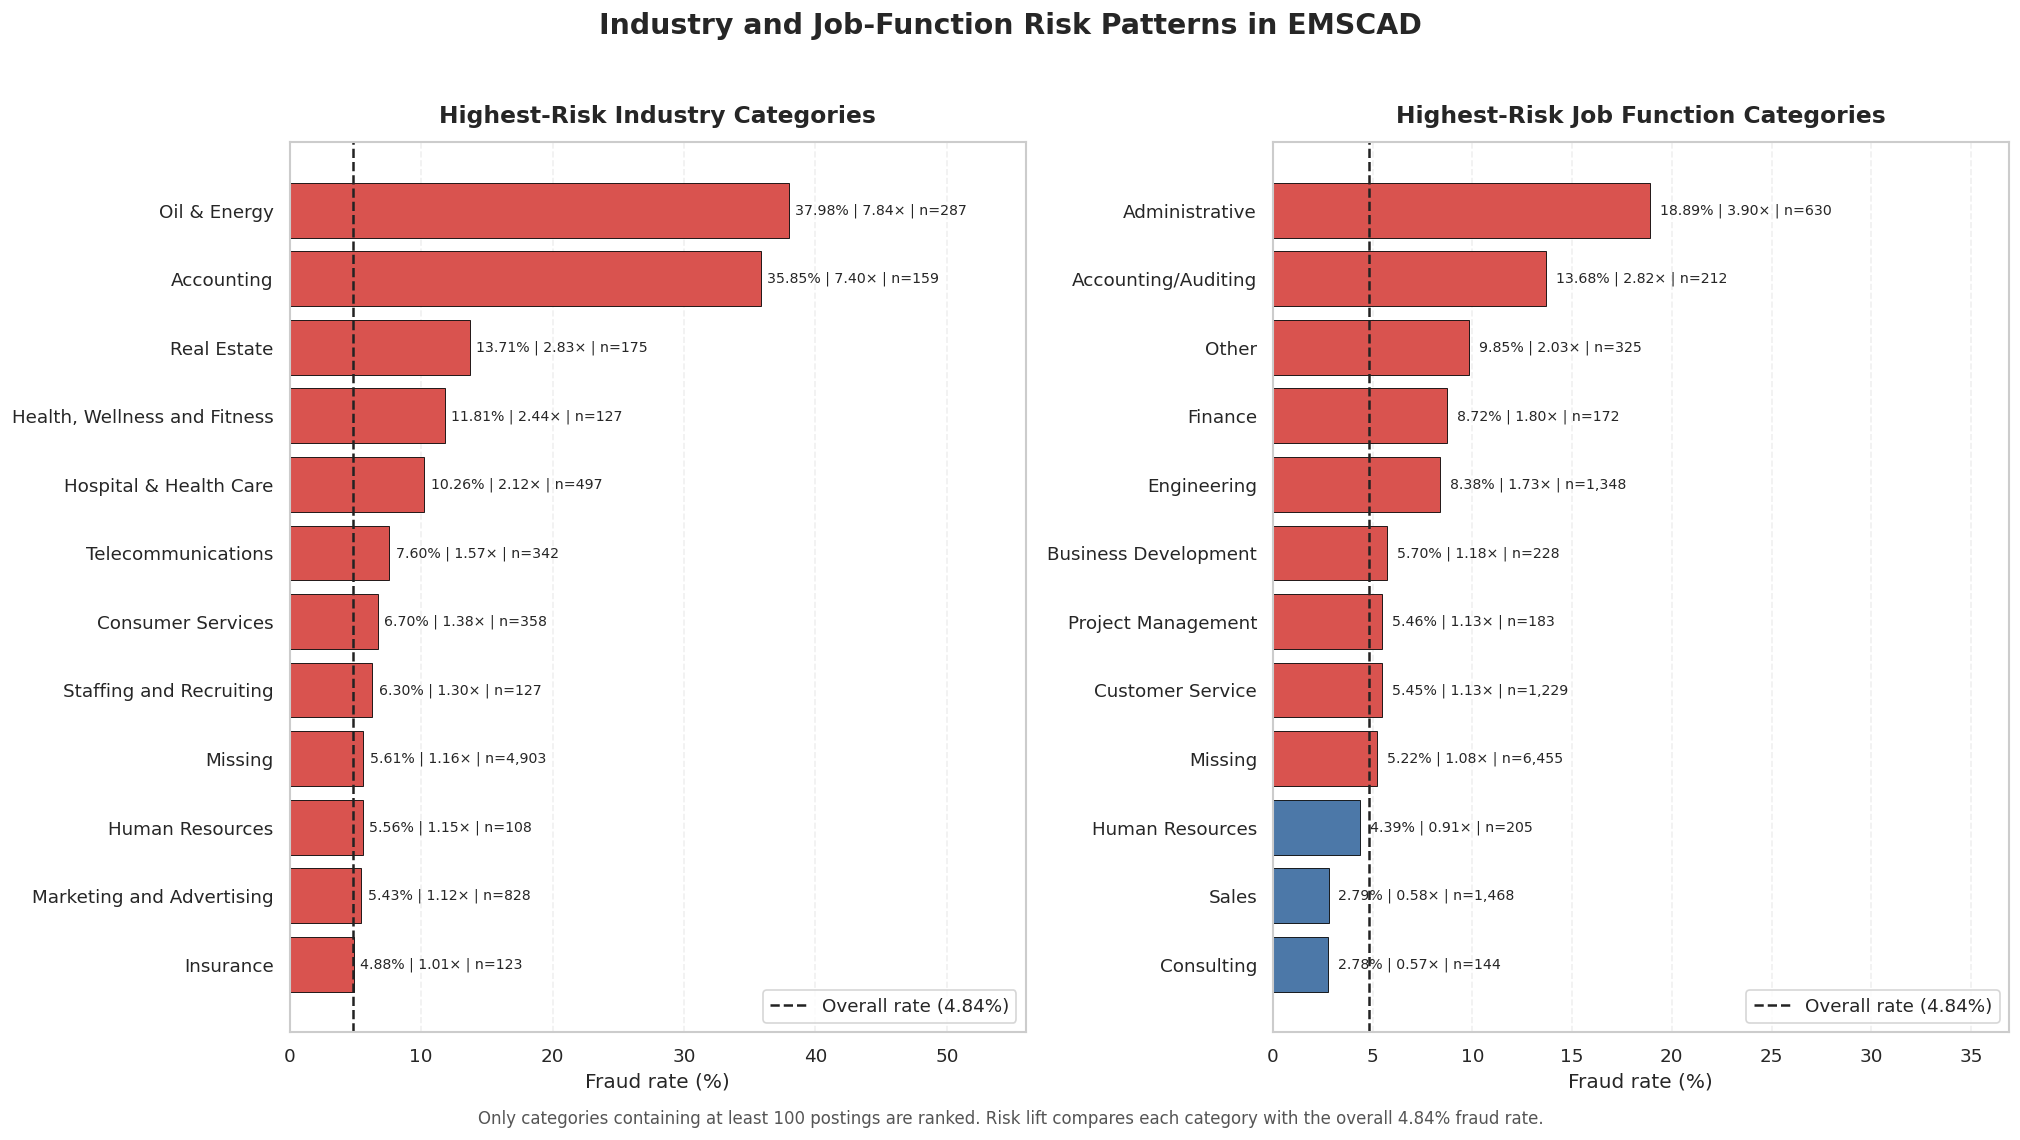

Table saved: /kaggle/working/emscad_complete_eda/tables/industry_function_fraud_risk.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/09_industry_function_fraud_risk.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/09_industry_function_fraud_risk.pdf


In [11]:
# ================================================================
# STEP 11: INDUSTRY AND JOB-FUNCTION FRAUD-RISK ANALYSIS
# ================================================================

risk_features = [
    "industry",
    "function"
]

risk_display_names = {
    "industry": "Industry",
    "function": "Job Function"
}

risk_summary_frames = []

for feature in risk_features:

    category_values = (
        df[feature]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
    )

    feature_summary = (
        pd.DataFrame({
            "Category": category_values,
            "Fraudulent":
                df["fraudulent"].values
        })
        .groupby("Category")["Fraudulent"]
        .agg(
            Total_Posts="count",
            Fraudulent_Posts="sum"
        )
        .reset_index()
    )

    feature_summary[
        "Fraud_Rate_Percentage"
    ] = (
        feature_summary[
            "Fraudulent_Posts"
        ]
        / feature_summary["Total_Posts"]
        * 100
    ).round(2)

    feature_summary["Risk_Lift"] = (
        feature_summary[
            "Fraud_Rate_Percentage"
        ]
        / global_fraud_rate
    ).round(2)

    feature_summary.insert(
        0,
        "Feature",
        feature
    )

    risk_summary_frames.append(
        feature_summary
    )

industry_function_summary = pd.concat(
    risk_summary_frames,
    ignore_index=True
)

print("=" * 70)
print("INDUSTRY AND JOB-FUNCTION FRAUD RISK")
print("=" * 70)

for feature in risk_features:

    print(
        f"\nHighest-risk "
        f"{risk_display_names[feature]} categories"
    )

    display(
        industry_function_summary[
            (
                industry_function_summary[
                    "Feature"
                ] == feature
            )
            & (
                industry_function_summary[
                    "Total_Posts"
                ] >= 100
            )
        ]
        .sort_values(
            "Fraud_Rate_Percentage",
            ascending=False
        )
        .head(15)
    )

# Save all categories
industry_function_table_path = (
    os.path.join(
        TABLE_DIR,
        "industry_function_fraud_risk.csv"
    )
)

industry_function_summary.to_csv(
    industry_function_table_path,
    index=False
)

# ------------------------------------------------
# Plot top 12 categories with at least 100 posts
# ------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 9)
)

for ax, feature in zip(
    axes,
    risk_features
):

    graph_data = (
        industry_function_summary[
            (
                industry_function_summary[
                    "Feature"
                ] == feature
            )
            & (
                industry_function_summary[
                    "Total_Posts"
                ] >= 100
            )
        ]
        .nlargest(
            12,
            "Fraud_Rate_Percentage"
        )
        .sort_values(
            "Fraud_Rate_Percentage",
            ascending=True
        )
        .copy()
    )

    colors = [
        "#D9534F"
        if rate > global_fraud_rate
        else "#4C78A8"
        for rate
        in graph_data[
            "Fraud_Rate_Percentage"
        ]
    ]

    bars = ax.barh(
        graph_data["Category"],
        graph_data[
            "Fraud_Rate_Percentage"
        ],
        color=colors,
        edgecolor="black",
        linewidth=0.5
    )

    for bar, rate, total, lift in zip(
        bars,
        graph_data[
            "Fraud_Rate_Percentage"
        ],
        graph_data["Total_Posts"],
        graph_data["Risk_Lift"]
    ):

        ax.text(
            bar.get_width() + 0.5,
            bar.get_y()
            + bar.get_height() / 2,
            (
                f"{rate:.2f}% | "
                f"{lift:.2f}× | "
                f"n={total:,}"
            ),
            va="center",
            fontsize=8.5
        )

    ax.axvline(
        global_fraud_rate,
        color="#222222",
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Overall rate "
            f"({global_fraud_rate:.2f}%)"
        )
    )

    ax.set_title(
        (
            f"Highest-Risk "
            f"{risk_display_names[feature]} Categories"
        ),
        fontsize=14,
        pad=12
    )

    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("")

    maximum_rate = graph_data[
        "Fraud_Rate_Percentage"
    ].max()

    ax.set_xlim(
        0,
        maximum_rate + 18
    )

    ax.legend(
        loc="lower right"
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.grid(
        axis="y",
        visible=False
    )

fig.suptitle(
    "Industry and Job-Function Risk Patterns in EMSCAD",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Only categories containing at least 100 postings are ranked. "
    "Risk lift compares each category with the overall 4.84% fraud rate.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

industry_function_png = os.path.join(
    FIGURE_DIR,
    "09_industry_function_fraud_risk.png"
)

industry_function_pdf = os.path.join(
    FIGURE_DIR,
    "09_industry_function_fraud_risk.pdf"
)

plt.savefig(
    industry_function_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    industry_function_pdf,
    bbox_inches="tight"
)

plt.show()

print(
    "Table saved:",
    industry_function_table_path
)

print(
    "PNG graph saved:",
    industry_function_png
)

print(
    "PDF graph saved:",
    industry_function_pdf
)

COUNTRY-WISE JOB-POSTING ANALYSIS

Countries with the most postings:


,Country,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
0,US,10656,730,6.85,1.41
1,GB,2384,23,0.96,0.20
2,GR,940,0,0.00,0.00
3,CA,457,12,2.63,0.54
4,DE,383,0,0.00,0.00
5,MISSING,346,19,5.49,1.13
6,NZ,333,0,0.00,0.00
7,IN,276,4,1.45,0.30
8,AU,214,40,18.69,3.86
9,PH,132,1,0.76,0.16



Highest fraud rates among countries with at least 100 postings:


,Country,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
8,AU,214,40,18.69,3.86
0,US,10656,730,6.85,1.41
5,MISSING,346,19,5.49,1.13
3,CA,457,12,2.63,0.54
7,IN,276,4,1.45,0.30
1,GB,2384,23,0.96,0.20
9,PH,132,1,0.76,0.16
4,DE,383,0,0.00,0.00
2,GR,940,0,0.00,0.00
6,NZ,333,0,0.00,0.00


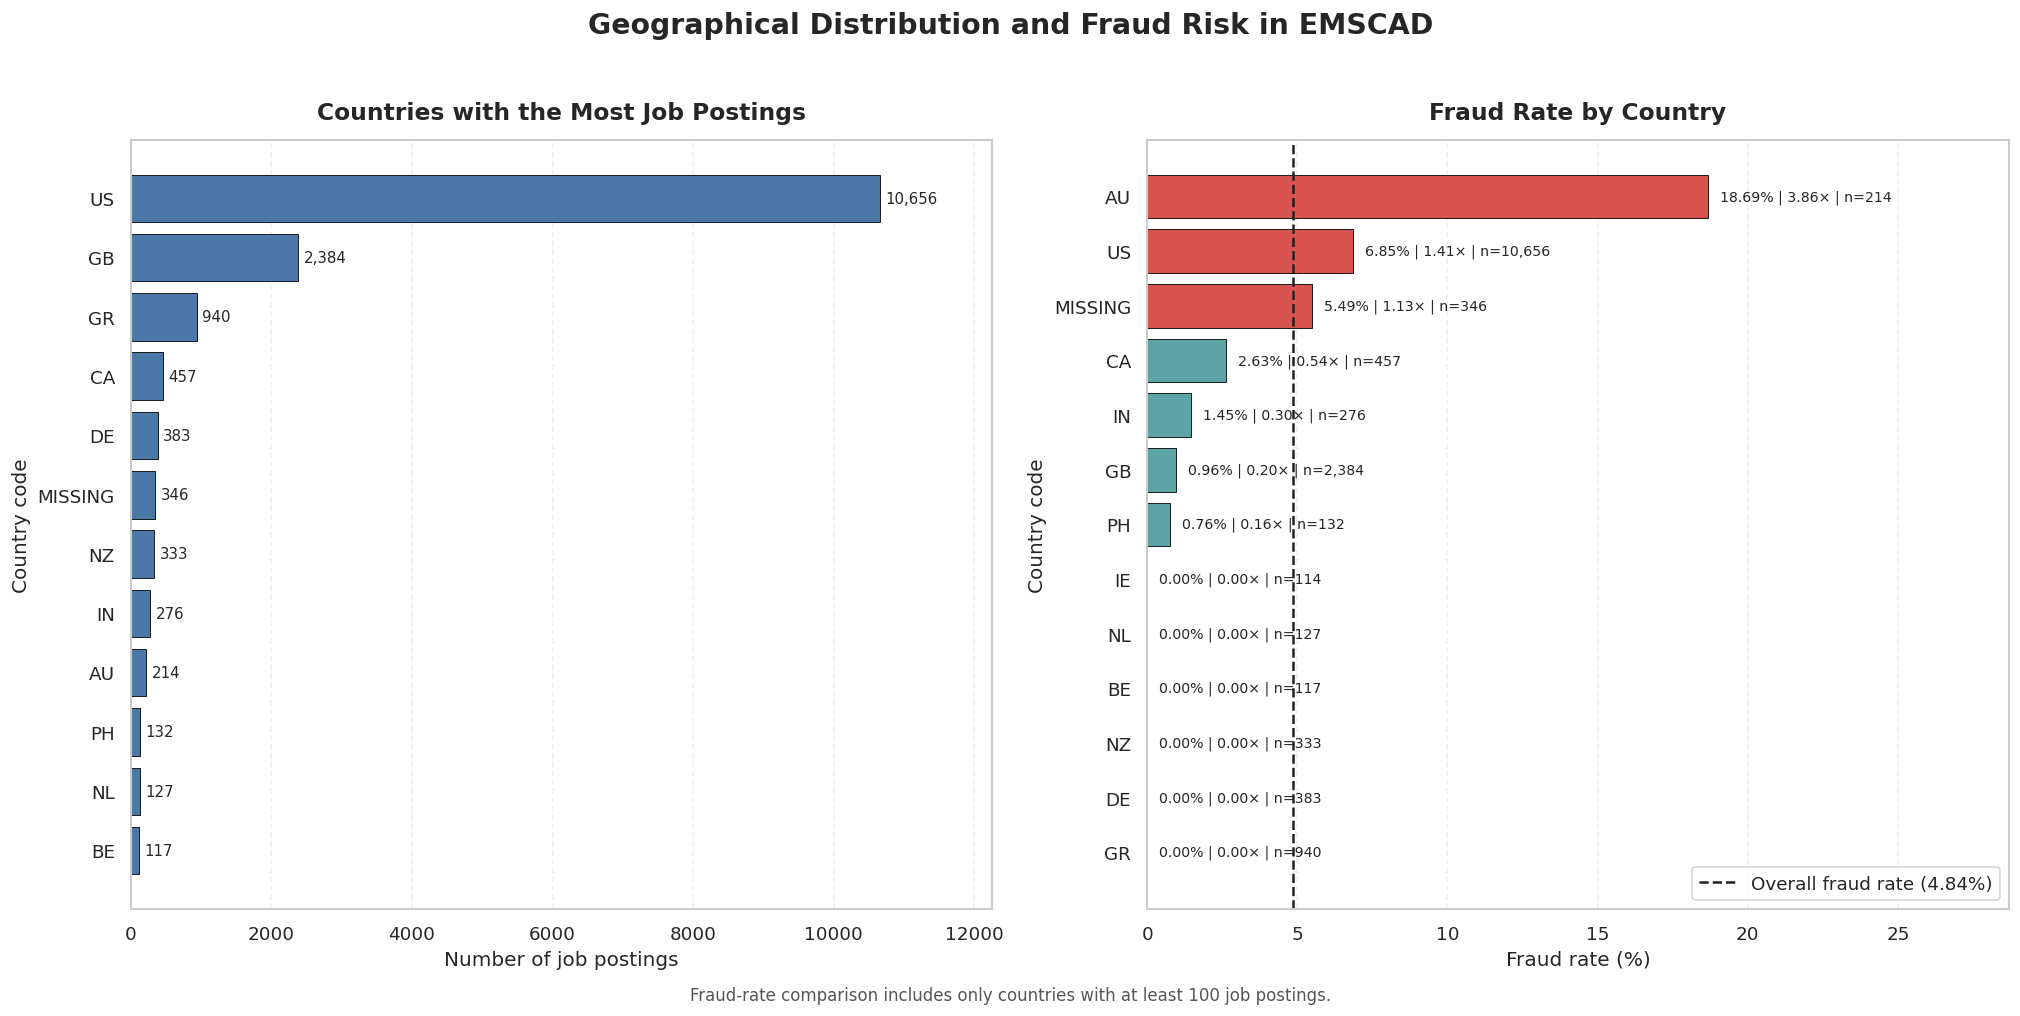

Table saved: /kaggle/working/emscad_complete_eda/tables/country_fraud_risk.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/10_country_distribution_fraud_risk.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/10_country_distribution_fraud_risk.pdf


In [12]:
# ================================================================
# STEP 12: COUNTRY-WISE FRAUD-RISK ANALYSIS
# ================================================================

# Extract the first part of location as the country code
country = (
    df["location"]
    .fillna("Missing")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
    .str.upper()
    .replace({
        "": "MISSING",
        "NAN": "MISSING"
    })
)

country_analysis = pd.DataFrame({
    "Country": country,
    "Fraudulent": df["fraudulent"].values
})

country_summary = (
    country_analysis
    .groupby("Country")["Fraudulent"]
    .agg(
        Total_Posts="count",
        Fraudulent_Posts="sum"
    )
    .reset_index()
)

country_summary[
    "Fraud_Rate_Percentage"
] = (
    country_summary["Fraudulent_Posts"]
    / country_summary["Total_Posts"]
    * 100
).round(2)

country_summary["Risk_Lift"] = (
    country_summary[
        "Fraud_Rate_Percentage"
    ]
    / global_fraud_rate
).round(2)

country_summary = country_summary.sort_values(
    "Total_Posts",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("COUNTRY-WISE JOB-POSTING ANALYSIS")
print("=" * 70)

print("\nCountries with the most postings:")

display(
    country_summary.head(20)
)

print(
    "\nHighest fraud rates among countries "
    "with at least 100 postings:"
)

display(
    country_summary[
        country_summary["Total_Posts"] >= 100
    ]
    .sort_values(
        "Fraud_Rate_Percentage",
        ascending=False
    )
)

# Save table
country_table_path = os.path.join(
    TABLE_DIR,
    "country_fraud_risk.csv"
)

country_summary.to_csv(
    country_table_path,
    index=False
)

# ------------------------------------------------
# Prepare graph data
# ------------------------------------------------

top_count_countries = (
    country_summary
    .head(12)
    .sort_values(
        "Total_Posts",
        ascending=True
    )
)

country_risk_graph = (
    country_summary[
        country_summary["Total_Posts"] >= 100
    ]
    .sort_values(
        "Fraud_Rate_Percentage",
        ascending=True
    )
)

# ------------------------------------------------
# Create two-panel graph
# ------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8)
)

# Panel 1: number of postings
count_bars = axes[0].barh(
    top_count_countries["Country"],
    top_count_countries["Total_Posts"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.5
)

for bar, count in zip(
    count_bars,
    top_count_countries["Total_Posts"]
):

    axes[0].text(
        bar.get_width() + 80,
        bar.get_y()
        + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=9
    )

axes[0].set_title(
    "Countries with the Most Job Postings",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel("Number of job postings")
axes[0].set_ylabel("Country code")

axes[0].set_xlim(
    0,
    top_count_countries[
        "Total_Posts"
    ].max() * 1.15
)

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].grid(
    axis="y",
    visible=False
)

# Panel 2: fraud rate
risk_colors = [
    "#D9534F"
    if rate > global_fraud_rate
    else "#5DA5A4"
    for rate
    in country_risk_graph[
        "Fraud_Rate_Percentage"
    ]
]

risk_bars = axes[1].barh(
    country_risk_graph["Country"],
    country_risk_graph[
        "Fraud_Rate_Percentage"
    ],
    color=risk_colors,
    edgecolor="black",
    linewidth=0.5
)

for bar, rate, total, lift in zip(
    risk_bars,
    country_risk_graph[
        "Fraud_Rate_Percentage"
    ],
    country_risk_graph["Total_Posts"],
    country_risk_graph["Risk_Lift"]
):

    axes[1].text(
        bar.get_width() + 0.4,
        bar.get_y()
        + bar.get_height() / 2,
        (
            f"{rate:.2f}% | "
            f"{lift:.2f}× | "
            f"n={total:,}"
        ),
        va="center",
        fontsize=8.5
    )

axes[1].axvline(
    global_fraud_rate,
    color="#222222",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall fraud rate "
        f"({global_fraud_rate:.2f}%)"
    )
)

axes[1].set_title(
    "Fraud Rate by Country",
    fontsize=14,
    pad=12
)

axes[1].set_xlabel("Fraud rate (%)")
axes[1].set_ylabel("Country code")

axes[1].set_xlim(
    0,
    country_risk_graph[
        "Fraud_Rate_Percentage"
    ].max() + 10
)

axes[1].legend(
    loc="lower right"
)

axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[1].grid(
    axis="y",
    visible=False
)

fig.suptitle(
    "Geographical Distribution and Fraud Risk in EMSCAD",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Fraud-rate comparison includes only countries with at least "
    "100 job postings.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

country_png = os.path.join(
    FIGURE_DIR,
    "10_country_distribution_fraud_risk.png"
)

country_pdf = os.path.join(
    FIGURE_DIR,
    "10_country_distribution_fraud_risk.pdf"
)

plt.savefig(
    country_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    country_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", country_table_path)
print("PNG graph saved:", country_png)
print("PDF graph saved:", country_pdf)

SALARY-RANGE ANALYSIS

Salary availability and fraud rates:


,Salary_Status,Total_Posts,Fraudulent_Posts,Fraud_Rate_Percentage,Risk_Lift
0,Missing,15012,643,4.28,0.88
1,Provided but unparsed,27,1,3.70,0.76
2,Valid numeric range,2841,222,7.81,1.61



Valid numeric salary ranges by class:


,Class,Total_Posts,Median_Minimum,Median_Maximum,Median_Width
0,Fraudulent,222,30000.0,45000.0,10000.0
1,Genuine,2619,36000.0,50000.0,10000.0


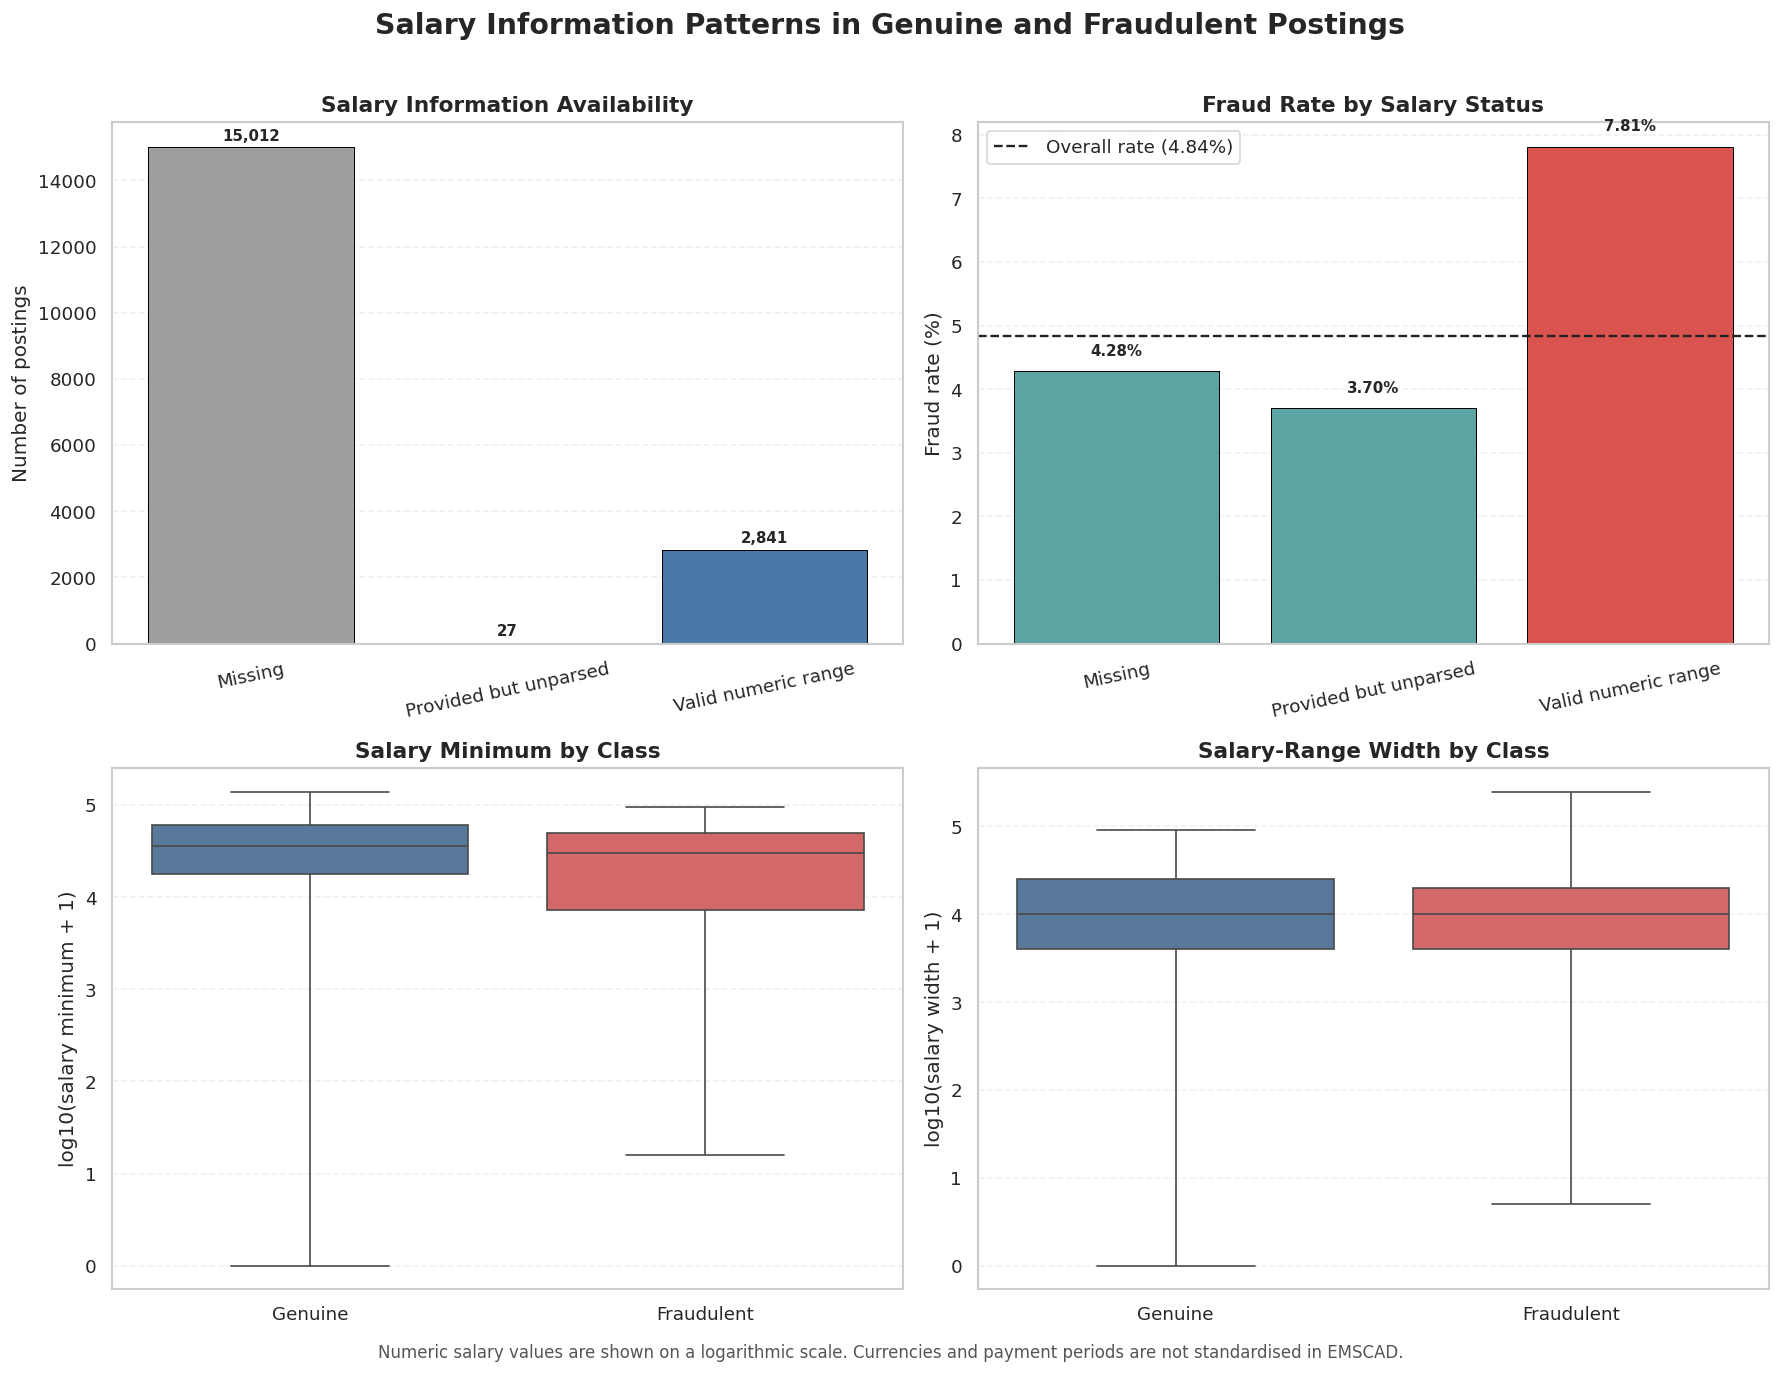

Salary-status table saved: /kaggle/working/emscad_complete_eda/tables/salary_status_fraud_rate.csv
Valid-salary table saved: /kaggle/working/emscad_complete_eda/tables/valid_salary_summary_by_class.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/11_salary_range_analysis.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/11_salary_range_analysis.pdf


In [13]:
# ================================================================
# STEP 13: SALARY-RANGE AVAILABILITY AND FRAUD ANALYSIS
# ================================================================

import re

def parse_salary_range(value):

    if pd.isna(value):
        return "Missing", np.nan, np.nan

    text = str(value).strip()

    if text == "":
        return "Missing", np.nan, np.nan

    # Extract numeric values such as:
    # 50000-60000 or $50,000-$60,000
    number_strings = re.findall(
        r"\d[\d,]*(?:\.\d+)?",
        text
    )

    numbers = []

    for number_string in number_strings:

        try:
            numbers.append(
                float(
                    number_string.replace(",", "")
                )
            )
        except ValueError:
            continue

    if len(numbers) >= 2:

        salary_minimum = numbers[0]
        salary_maximum = numbers[1]

        # Correct reversed ranges
        if salary_maximum < salary_minimum:
            salary_minimum, salary_maximum = (
                salary_maximum,
                salary_minimum
            )

        return (
            "Valid numeric range",
            salary_minimum,
            salary_maximum
        )

    return (
        "Provided but unparsed",
        np.nan,
        np.nan
    )


parsed_salary = df["salary_range"].apply(
    parse_salary_range
)

salary_analysis = pd.DataFrame(
    parsed_salary.tolist(),
    columns=[
        "Salary_Status",
        "Salary_Minimum",
        "Salary_Maximum"
    ],
    index=df.index
)

salary_analysis["Salary_Width"] = (
    salary_analysis["Salary_Maximum"]
    - salary_analysis["Salary_Minimum"]
)

salary_analysis["Fraudulent"] = (
    df["fraudulent"].values
)

salary_analysis["Class"] = (
    df["fraudulent"]
    .map({
        0: "Genuine",
        1: "Fraudulent"
    })
    .values
)

# Log-transformed values for readable graphs
salary_analysis["Salary_Minimum_Log10"] = (
    np.log10(
        salary_analysis["Salary_Minimum"] + 1
    )
)

salary_analysis["Salary_Width_Log10"] = (
    np.log10(
        salary_analysis["Salary_Width"] + 1
    )
)

# ------------------------------------------------
# Salary-status summary
# ------------------------------------------------

salary_status_summary = (
    salary_analysis
    .groupby("Salary_Status")["Fraudulent"]
    .agg(
        Total_Posts="count",
        Fraudulent_Posts="sum"
    )
    .reset_index()
)

salary_status_summary[
    "Fraud_Rate_Percentage"
] = (
    salary_status_summary[
        "Fraudulent_Posts"
    ]
    / salary_status_summary["Total_Posts"]
    * 100
).round(2)

salary_status_summary["Risk_Lift"] = (
    salary_status_summary[
        "Fraud_Rate_Percentage"
    ]
    / global_fraud_rate
).round(2)

status_order = [
    "Missing",
    "Provided but unparsed",
    "Valid numeric range"
]

salary_status_summary[
    "Salary_Status"
] = pd.Categorical(
    salary_status_summary[
        "Salary_Status"
    ],
    categories=status_order,
    ordered=True
)

salary_status_summary = (
    salary_status_summary
    .sort_values("Salary_Status")
    .reset_index(drop=True)
)

# ------------------------------------------------
# Valid salary summary by class
# ------------------------------------------------

valid_salary_data = salary_analysis[
    salary_analysis["Salary_Status"]
    == "Valid numeric range"
].copy()

valid_salary_summary = (
    valid_salary_data
    .groupby("Class")
    .agg(
        Total_Posts=(
            "Salary_Minimum",
            "count"
        ),
        Median_Minimum=(
            "Salary_Minimum",
            "median"
        ),
        Median_Maximum=(
            "Salary_Maximum",
            "median"
        ),
        Median_Width=(
            "Salary_Width",
            "median"
        )
    )
    .reset_index()
)

print("=" * 70)
print("SALARY-RANGE ANALYSIS")
print("=" * 70)

print("\nSalary availability and fraud rates:")

display(salary_status_summary)

print("\nValid numeric salary ranges by class:")

display(valid_salary_summary)

# Save tables
salary_status_path = os.path.join(
    TABLE_DIR,
    "salary_status_fraud_rate.csv"
)

valid_salary_path = os.path.join(
    TABLE_DIR,
    "valid_salary_summary_by_class.csv"
)

salary_status_summary.to_csv(
    salary_status_path,
    index=False
)

valid_salary_summary.to_csv(
    valid_salary_path,
    index=False
)

# ------------------------------------------------
# Create four-panel figure
# ------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11)
)

status_colors = [
    "#9E9E9E",
    "#F2C14E",
    "#4C78A8"
]

# Panel 1: salary-status counts
count_bars = axes[0, 0].bar(
    salary_status_summary[
        "Salary_Status"
    ].astype(str),
    salary_status_summary[
        "Total_Posts"
    ],
    color=status_colors,
    edgecolor="black",
    linewidth=0.6
)

for bar, count in zip(
    count_bars,
    salary_status_summary[
        "Total_Posts"
    ]
):

    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

axes[0, 0].set_title(
    "Salary Information Availability",
    fontsize=13
)

axes[0, 0].set_ylabel("Number of postings")
axes[0, 0].tick_params(
    axis="x",
    rotation=12
)

axes[0, 0].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

axes[0, 0].grid(
    axis="x",
    visible=False
)

# Panel 2: fraud rates by salary status
fraud_colors = [
    "#D9534F"
    if rate > global_fraud_rate
    else "#5DA5A4"
    for rate
    in salary_status_summary[
        "Fraud_Rate_Percentage"
    ]
]

rate_bars = axes[0, 1].bar(
    salary_status_summary[
        "Salary_Status"
    ].astype(str),
    salary_status_summary[
        "Fraud_Rate_Percentage"
    ],
    color=fraud_colors,
    edgecolor="black",
    linewidth=0.6
)

for bar, rate in zip(
    rate_bars,
    salary_status_summary[
        "Fraud_Rate_Percentage"
    ]
):

    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"{rate:.2f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

axes[0, 1].axhline(
    global_fraud_rate,
    color="#222222",
    linestyle="--",
    linewidth=1.4,
    label=(
        f"Overall rate "
        f"({global_fraud_rate:.2f}%)"
    )
)

axes[0, 1].set_title(
    "Fraud Rate by Salary Status",
    fontsize=13
)

axes[0, 1].set_ylabel("Fraud rate (%)")

axes[0, 1].tick_params(
    axis="x",
    rotation=12
)

axes[0, 1].legend()

axes[0, 1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

axes[0, 1].grid(
    axis="x",
    visible=False
)

# Panel 3: salary minimum boxplot
sns.boxplot(
    data=valid_salary_data,
    x="Class",
    y="Salary_Minimum_Log10",
    order=[
        "Genuine",
        "Fraudulent"
    ],
    palette={
        "Genuine": "#4C78A8",
        "Fraudulent": "#E45756"
    },
    showfliers=False,
    whis=(5, 95),
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Salary Minimum by Class",
    fontsize=13
)

axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel(
    "log10(salary minimum + 1)"
)

axes[1, 0].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

axes[1, 0].grid(
    axis="x",
    visible=False
)

# Panel 4: salary-width boxplot
sns.boxplot(
    data=valid_salary_data,
    x="Class",
    y="Salary_Width_Log10",
    order=[
        "Genuine",
        "Fraudulent"
    ],
    palette={
        "Genuine": "#4C78A8",
        "Fraudulent": "#E45756"
    },
    showfliers=False,
    whis=(5, 95),
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Salary-Range Width by Class",
    fontsize=13
)

axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel(
    "log10(salary width + 1)"
)

axes[1, 1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

axes[1, 1].grid(
    axis="x",
    visible=False
)

fig.suptitle(
    "Salary Information Patterns in Genuine and Fraudulent Postings",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

fig.text(
    0.5,
    -0.01,
    "Numeric salary values are shown on a logarithmic scale. "
    "Currencies and payment periods are not standardised in EMSCAD.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

salary_png = os.path.join(
    FIGURE_DIR,
    "11_salary_range_analysis.png"
)

salary_pdf = os.path.join(
    FIGURE_DIR,
    "11_salary_range_analysis.pdf"
)

plt.savefig(
    salary_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    salary_pdf,
    bbox_inches="tight"
)

plt.show()

print("Salary-status table saved:", salary_status_path)
print("Valid-salary table saved:", valid_salary_path)
print("PNG graph saved:", salary_png)
print("PDF graph saved:", salary_pdf)

SUSPICIOUS TEXT-SIGNAL ANALYSIS


,Signal,Posts_With_Signal,Fraudulent_Posts,With_Signal_Fraud_Rate,Without_Signal_Fraud_Rate,Rate_Difference,Risk_Lift,Dataset_Prevalence
0,Work-from-home language,301,88,29.24,4.43,24.81,6.04,1.68
1,No-experience language,161,44,27.33,4.64,22.69,5.64,0.90
2,Money or earning language,4795,384,8.01,3.68,4.32,1.65,26.82
3,Excessive uppercase text,3191,234,7.33,4.30,3.03,1.51,17.85
4,Contains phone-like number,3070,153,4.98,4.81,0.17,1.03,17.17
5,Multiple exclamation marks,340,10,2.94,4.88,-1.94,0.61,1.90
6,Contains URL,291,6,2.06,4.89,-2.83,0.43,1.63
7,Contains email,2,0,0.00,4.84,-4.84,0.00,0.01
8,WhatsApp or Telegram,57,0,0.00,4.86,-4.86,0.00,0.32


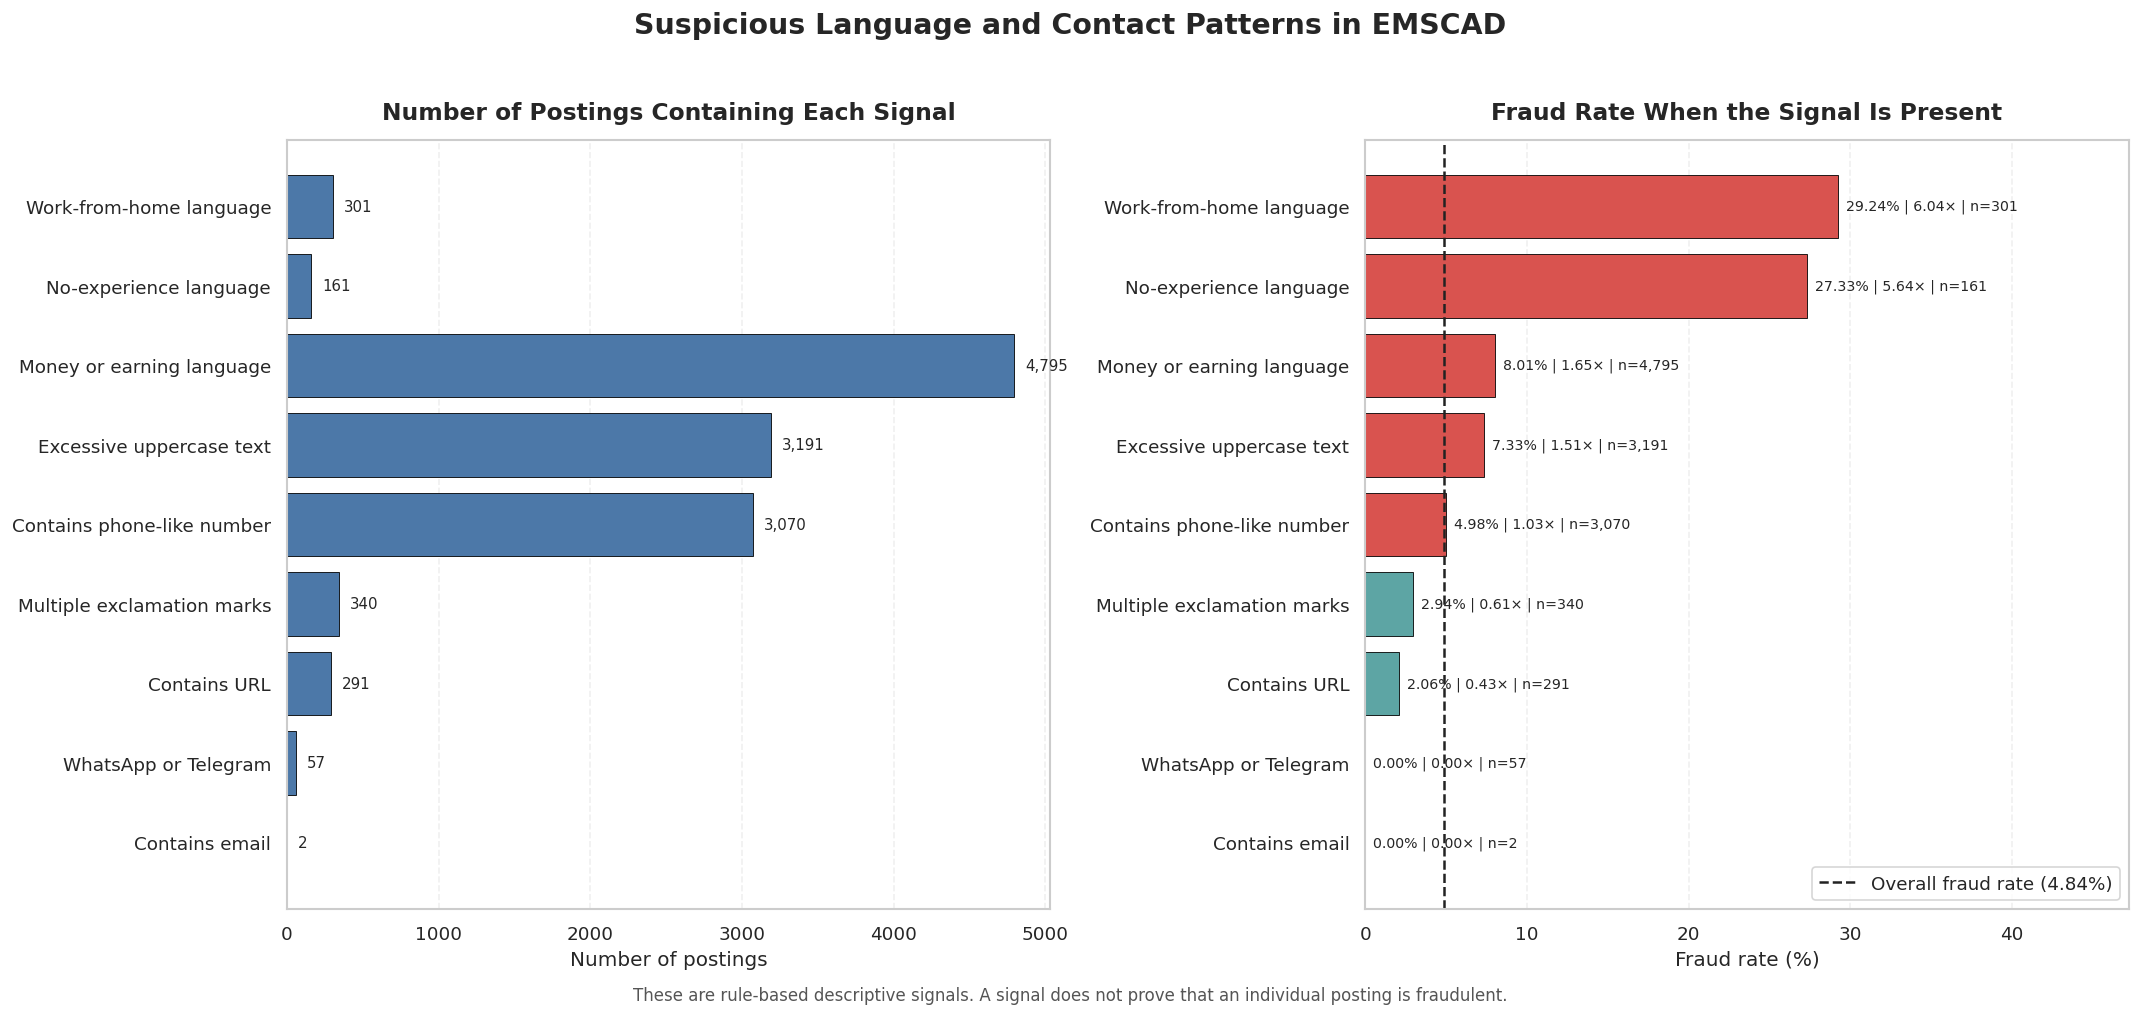

Summary saved: /kaggle/working/emscad_complete_eda/tables/suspicious_text_signal_summary.csv
Signal flags saved: /kaggle/working/emscad_complete_eda/tables/suspicious_text_signal_flags.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/12_suspicious_text_signals.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/12_suspicious_text_signals.pdf


In [14]:
# ================================================================
# STEP 14: SUSPICIOUS TEXT AND CONTACT-SIGNAL ANALYSIS
# ================================================================

combined_text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Combine all important text sections
combined_text_raw = (
    df[combined_text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

combined_text_lower = (
    combined_text_raw.str.lower()
)

# ------------------------------------------------
# Define transparent text-signal rules
# ------------------------------------------------

signal_flags = pd.DataFrame(
    index=df.index
)

signal_flags[
    "Work-from-home language"
] = combined_text_lower.str.contains(
    r"\bwork\s*from\s*home\b"
    r"|\bwork[-\s]?at[-\s]?home\b"
    r"|\bremote\s+work\b",
    regex=True,
    na=False
)

signal_flags[
    "No-experience language"
] = combined_text_lower.str.contains(
    r"\bno\s+experience\b"
    r"|\bwithout\s+experience\b"
    r"|\bexperience\s+not\s+required\b"
    r"|\bno\s+prior\s+experience\b",
    regex=True,
    na=False
)

signal_flags[
    "Money or earning language"
] = combined_text_lower.str.contains(
    r"\bearn(?:ing|ings|ed|s)?\b"
    r"|\bmoney\b"
    r"|\bincome\b"
    r"|\bpayment\b"
    r"|\bpaid\b"
    r"|\bwages?\b",
    regex=True,
    na=False
)

signal_flags[
    "Contains URL"
] = combined_text_lower.str.contains(
    r"https?://"
    r"|www\."
    r"|[a-z0-9-]+\.(?:com|org|net|co|io)\b",
    regex=True,
    na=False
)

signal_flags[
    "Contains email"
] = combined_text_lower.str.contains(
    r"\b[a-z0-9._%+-]+"
    r"@[a-z0-9.-]+"
    r"\.[a-z]{2,}\b",
    regex=True,
    na=False
)

signal_flags[
    "Contains phone-like number"
] = combined_text_raw.str.contains(
    r"(?:\+?\d[\d\s().-]{7,}\d)",
    regex=True,
    na=False
)

signal_flags[
    "Multiple exclamation marks"
] = combined_text_raw.str.contains(
    r"!{2,}",
    regex=True,
    na=False
)

signal_flags[
    "WhatsApp or Telegram"
] = combined_text_lower.str.contains(
    r"\bwhats?app\b"
    r"|\btelegram\b",
    regex=True,
    na=False
)

# Count uppercase words containing at least 3 letters
uppercase_word_count = (
    combined_text_raw
    .str.findall(r"\b[A-Z]{3,}\b")
    .str.len()
)

signal_flags[
    "Excessive uppercase text"
] = uppercase_word_count >= 8

# ------------------------------------------------
# Calculate fraud rates
# ------------------------------------------------

signal_summary_rows = []

for signal in signal_flags.columns:

    with_signal = signal_flags[signal]
    without_signal = ~with_signal

    posts_with_signal = int(
        with_signal.sum()
    )

    fraud_with_signal = int(
        df.loc[
            with_signal,
            "fraudulent"
        ].sum()
    )

    fraud_rate_with_signal = (
        df.loc[
            with_signal,
            "fraudulent"
        ].mean()
        * 100
        if posts_with_signal > 0
        else np.nan
    )

    posts_without_signal = int(
        without_signal.sum()
    )

    fraud_rate_without_signal = (
        df.loc[
            without_signal,
            "fraudulent"
        ].mean()
        * 100
        if posts_without_signal > 0
        else np.nan
    )

    signal_summary_rows.append({
        "Signal": signal,
        "Posts_With_Signal":
            posts_with_signal,
        "Fraudulent_Posts":
            fraud_with_signal,
        "With_Signal_Fraud_Rate":
            round(
                fraud_rate_with_signal,
                2
            ),
        "Without_Signal_Fraud_Rate":
            round(
                fraud_rate_without_signal,
                2
            ),
        "Rate_Difference":
            round(
                fraud_rate_with_signal
                - fraud_rate_without_signal,
                2
            ),
        "Risk_Lift":
            round(
                fraud_rate_with_signal
                / global_fraud_rate,
                2
            ),
        "Dataset_Prevalence":
            round(
                posts_with_signal
                / len(df)
                * 100,
                2
            )
    })

signal_summary = (
    pd.DataFrame(signal_summary_rows)
    .sort_values(
        "With_Signal_Fraud_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("SUSPICIOUS TEXT-SIGNAL ANALYSIS")
print("=" * 70)

display(signal_summary)

# Save tables
signal_summary_path = os.path.join(
    TABLE_DIR,
    "suspicious_text_signal_summary.csv"
)

signal_flags_path = os.path.join(
    TABLE_DIR,
    "suspicious_text_signal_flags.csv"
)

signal_summary.to_csv(
    signal_summary_path,
    index=False
)

signal_flags_output = signal_flags.copy()

signal_flags_output.insert(
    0,
    "source_row_index",
    df.index
)

signal_flags_output.insert(
    1,
    "job_id",
    df["job_id"].values
)

signal_flags_output.insert(
    2,
    "fraudulent",
    df["fraudulent"].values
)

signal_flags_output.to_csv(
    signal_flags_path,
    index=False
)

# ------------------------------------------------
# Create two-panel figure
# ------------------------------------------------

plot_data = signal_summary.sort_values(
    "With_Signal_Fraud_Rate",
    ascending=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

# Panel 1: posts containing each signal
count_bars = axes[0].barh(
    plot_data["Signal"],
    plot_data["Posts_With_Signal"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.5
)

for bar, count in zip(
    count_bars,
    plot_data["Posts_With_Signal"]
):

    axes[0].text(
        bar.get_width()
        + max(plot_data["Posts_With_Signal"])
        * 0.015,
        bar.get_y()
        + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=9
    )

axes[0].set_title(
    "Number of Postings Containing Each Signal",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel("Number of postings")
axes[0].set_ylabel("")

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].grid(
    axis="y",
    visible=False
)

# Panel 2: fraud rates
signal_colors = [
    "#D9534F"
    if rate > global_fraud_rate
    else "#5DA5A4"
    for rate
    in plot_data[
        "With_Signal_Fraud_Rate"
    ]
]

rate_bars = axes[1].barh(
    plot_data["Signal"],
    plot_data[
        "With_Signal_Fraud_Rate"
    ],
    color=signal_colors,
    edgecolor="black",
    linewidth=0.5
)

for bar, rate, count, lift in zip(
    rate_bars,
    plot_data[
        "With_Signal_Fraud_Rate"
    ],
    plot_data["Posts_With_Signal"],
    plot_data["Risk_Lift"]
):

    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y()
        + bar.get_height() / 2,
        (
            f"{rate:.2f}% | "
            f"{lift:.2f}× | "
            f"n={count:,}"
        ),
        va="center",
        fontsize=8.5
    )

axes[1].axvline(
    global_fraud_rate,
    color="#222222",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall fraud rate "
        f"({global_fraud_rate:.2f}%)"
    )
)

axes[1].set_title(
    "Fraud Rate When the Signal Is Present",
    fontsize=14,
    pad=12
)

axes[1].set_xlabel("Fraud rate (%)")
axes[1].set_ylabel("")

axes[1].set_xlim(
    0,
    plot_data[
        "With_Signal_Fraud_Rate"
    ].max() + 18
)

axes[1].legend(
    loc="lower right"
)

axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[1].grid(
    axis="y",
    visible=False
)

fig.suptitle(
    "Suspicious Language and Contact Patterns in EMSCAD",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "These are rule-based descriptive signals. "
    "A signal does not prove that an individual posting is fraudulent.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

signal_png = os.path.join(
    FIGURE_DIR,
    "12_suspicious_text_signals.png"
)

signal_pdf = os.path.join(
    FIGURE_DIR,
    "12_suspicious_text_signals.pdf"
)

plt.savefig(
    signal_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    signal_pdf,
    bbox_inches="tight"
)

plt.show()

print("Summary saved:", signal_summary_path)
print("Signal flags saved:", signal_flags_path)
print("PNG graph saved:", signal_png)
print("PDF graph saved:", signal_pdf)

SPEARMAN CORRELATION ANALYSIS


,Feature,Spearman_Correlation_With_Fraud
13,suspicious_signal_count,0.101191
12,missing_fields_count,0.051315
11,title_words,0.036017
10,telecommuting,0.034523
9,digit_count,0.023634
8,exclamation_count,0.007537
7,uppercase_word_count,0.006505
6,benefits_words,-0.009436
5,description_words,-0.047271
4,requirements_words,-0.073287


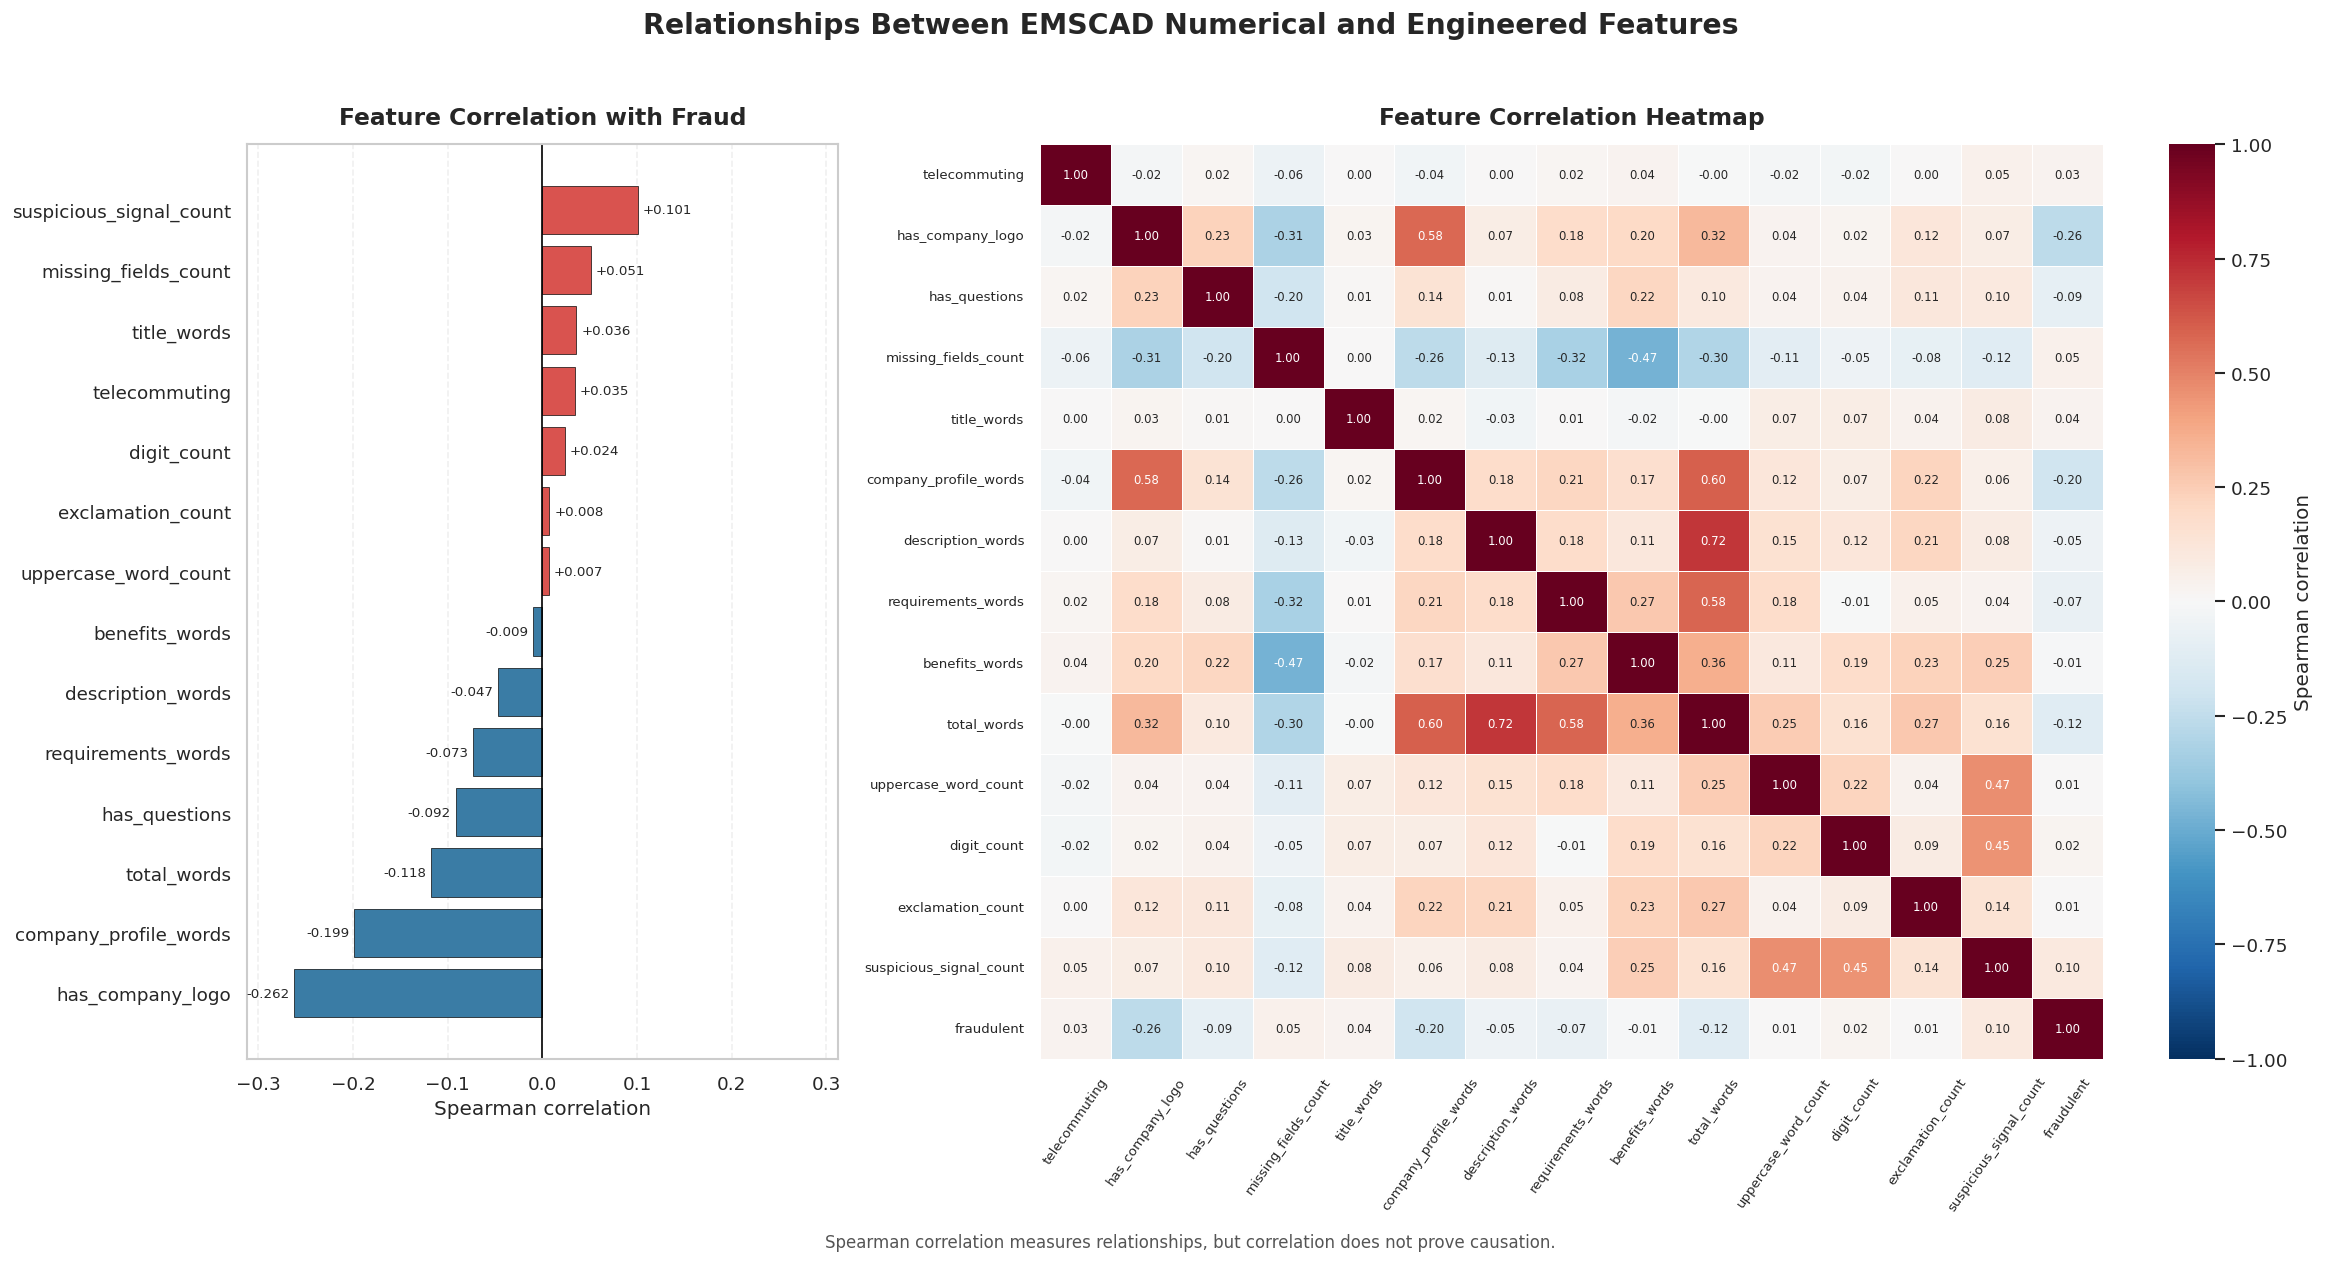

Correlation matrix saved: /kaggle/working/emscad_complete_eda/tables/spearman_correlation_matrix.csv
Fraud correlations saved: /kaggle/working/emscad_complete_eda/tables/feature_correlations_with_fraud.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/13_correlation_heatmap.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/13_correlation_heatmap.pdf


In [19]:
# ================================================================
# STEP 15: CORRELATION HEATMAP — CORRECTED VERSION
# ================================================================

def calculate_word_count(series):
    cleaned_series = series.fillna("").astype(str)

    return (
        cleaned_series
        .str.findall(r"\b[\w'-]+\b")
        .str.len()
    )


# Create a separate dataframe for correlation analysis
correlation_data = pd.DataFrame(index=df.index)

# Original binary features
correlation_data["telecommuting"] = df["telecommuting"]
correlation_data["has_company_logo"] = df["has_company_logo"]
correlation_data["has_questions"] = df["has_questions"]

# Missing-field count
correlation_data["missing_fields_count"] = (
    missing_fields_per_row
)

# Word-count features
correlation_data["title_words"] = (
    calculate_word_count(df["title"])
)

correlation_data["company_profile_words"] = (
    calculate_word_count(df["company_profile"])
)

correlation_data["description_words"] = (
    calculate_word_count(df["description"])
)

correlation_data["requirements_words"] = (
    calculate_word_count(df["requirements"])
)

correlation_data["benefits_words"] = (
    calculate_word_count(df["benefits"])
)

correlation_data["total_words"] = (
    correlation_data[
        [
            "title_words",
            "company_profile_words",
            "description_words",
            "requirements_words",
            "benefits_words"
        ]
    ].sum(axis=1)
)

# Character-pattern features
correlation_data["uppercase_word_count"] = (
    uppercase_word_count
)

correlation_data["digit_count"] = (
    combined_text_raw.str.count(r"\d")
)

correlation_data["exclamation_count"] = (
    combined_text_raw.str.count(r"!")
)

correlation_data["suspicious_signal_count"] = (
    signal_flags.sum(axis=1)
)

# Target column
correlation_data["fraudulent"] = df["fraudulent"]

# Calculate Spearman correlation
correlation_matrix = correlation_data.corr(
    method="spearman"
)

fraud_correlations = (
    correlation_matrix["fraudulent"]
    .drop("fraudulent")
    .sort_values()
    .reset_index()
)

fraud_correlations.columns = [
    "Feature",
    "Spearman_Correlation_With_Fraud"
]

print("=" * 70)
print("SPEARMAN CORRELATION ANALYSIS")
print("=" * 70)

display(
    fraud_correlations.sort_values(
        "Spearman_Correlation_With_Fraud",
        ascending=False
    )
)

# Save tables
correlation_matrix_path = os.path.join(
    TABLE_DIR,
    "spearman_correlation_matrix.csv"
)

fraud_correlation_path = os.path.join(
    TABLE_DIR,
    "feature_correlations_with_fraud.csv"
)

correlation_matrix.to_csv(
    correlation_matrix_path
)

fraud_correlations.to_csv(
    fraud_correlation_path,
    index=False
)

# ------------------------------------------------
# Create graphs
# ------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 10),
    gridspec_kw={"width_ratios": [0.8, 1.8]}
)

# Correlations with fraud
correlation_colors = [
    "#D9534F" if value > 0 else "#3A7CA5"
    for value in fraud_correlations[
        "Spearman_Correlation_With_Fraud"
    ]
]

bars = axes[0].barh(
    fraud_correlations["Feature"],
    fraud_correlations[
        "Spearman_Correlation_With_Fraud"
    ],
    color=correlation_colors,
    edgecolor="black",
    linewidth=0.4
)

for bar, value in zip(
    bars,
    fraud_correlations[
        "Spearman_Correlation_With_Fraud"
    ]
):
    if value >= 0:
        text_position = value + 0.005
        text_alignment = "left"
    else:
        text_position = value - 0.005
        text_alignment = "right"

    axes[0].text(
        text_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.3f}",
        va="center",
        ha=text_alignment,
        fontsize=8
    )

axes[0].axvline(
    0,
    color="black",
    linewidth=1
)

axes[0].set_title(
    "Feature Correlation with Fraud",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel("Spearman correlation")
axes[0].set_ylabel("")

maximum_correlation = (
    fraud_correlations[
        "Spearman_Correlation_With_Fraud"
    ]
    .abs()
    .max()
)

axes[0].set_xlim(
    -maximum_correlation - 0.05,
    maximum_correlation + 0.05
)

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].grid(
    axis="y",
    visible=False
)

# Complete heatmap
sns.heatmap(
    correlation_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 7},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "label": "Spearman correlation"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Feature Correlation Heatmap",
    fontsize=14,
    pad=12
)

axes[1].tick_params(
    axis="x",
    rotation=55,
    labelsize=8
)

axes[1].tick_params(
    axis="y",
    rotation=0,
    labelsize=8
)

fig.suptitle(
    "Relationships Between EMSCAD Numerical and Engineered Features",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Spearman correlation measures relationships, "
    "but correlation does not prove causation.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

correlation_png = os.path.join(
    FIGURE_DIR,
    "13_correlation_heatmap.png"
)

correlation_pdf = os.path.join(
    FIGURE_DIR,
    "13_correlation_heatmap.pdf"
)

plt.savefig(
    correlation_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    correlation_pdf,
    bbox_inches="tight"
)

plt.show()

print("Correlation matrix saved:", correlation_matrix_path)
print("Fraud correlations saved:", fraud_correlation_path)
print("PNG graph saved:", correlation_png)
print("PDF graph saved:", correlation_pdf)

LEXICAL TERM ANALYSIS
Rows before removing repeated copies: 17880
Unique-content rows used: 17599

Terms associated with fraudulent posts:


,Term,Fraud_Document_Count,Genuine_Document_Count,Fraud_Document_Percentage,Genuine_Document_Percentage,Fraud_Log_Odds
0,leveraging career,78,0,9.112,0.0,8.125
1,aptitude staffing,61,0,7.126,0.0,7.859
2,encouraged participate,56,0,6.542,0.0,7.768
3,expert negotiations,56,0,6.542,0.0,7.768
4,following perks,56,0,6.542,0.0,7.768
5,participate referral,56,0,6.542,0.0,7.768
6,represented candidates,56,0,6.542,0.0,7.768
7,services town,56,0,6.542,0.0,7.768
8,aker,51,0,5.958,0.0,7.669
9,aker solutions,51,0,5.958,0.0,7.669



Terms associated with genuine posts:


,Term,Fraud_Document_Count,Genuine_Document_Count,Fraud_Document_Percentage,Genuine_Document_Percentage,Fraud_Log_Odds
0,university degree,0,987,0.0,5.895,-4.676
1,asia,0,942,0.0,5.626,-4.627
2,amp secure,0,749,0.0,4.474,-4.385
3,medium large,0,739,0.0,4.414,-4.371
4,teaching experience,0,739,0.0,4.414,-4.371
5,tefl,0,732,0.0,4.372,-4.361
6,help teachers,0,729,0.0,4.354,-4.357
7,tesol,0,729,0.0,4.354,-4.357
8,tefl tesol,0,727,0.0,4.342,-4.354
9,celta,0,726,0.0,4.336,-4.353


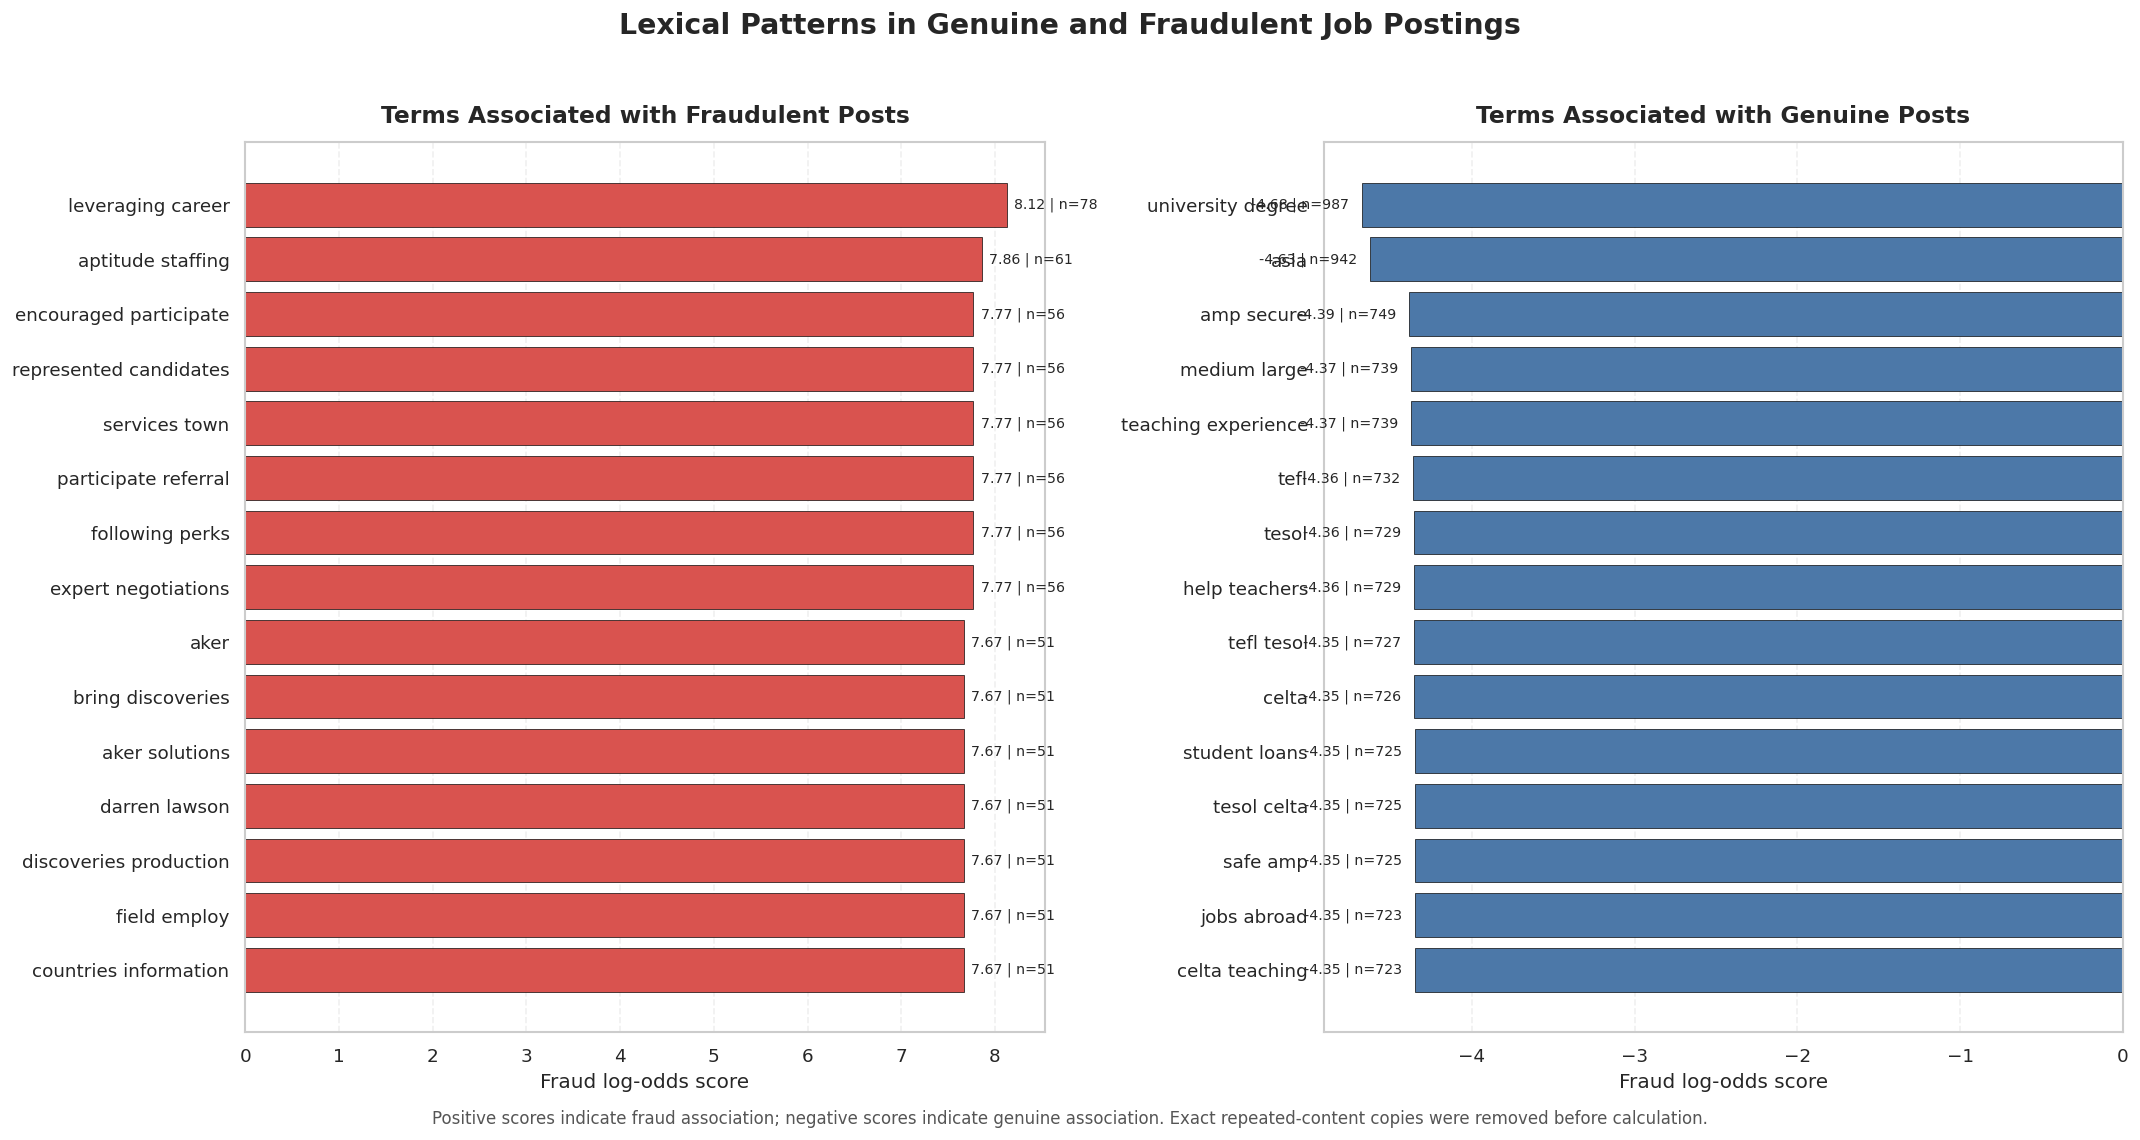

All term scores saved: /kaggle/working/emscad_complete_eda/tables/all_term_association_scores.csv
Fraud terms saved: /kaggle/working/emscad_complete_eda/tables/top_fraud_associated_terms.csv
Genuine terms saved: /kaggle/working/emscad_complete_eda/tables/top_genuine_associated_terms.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/14_term_association_analysis.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/14_term_association_analysis.pdf


In [20]:
# ================================================================
# STEP 16: FRAUD-ASSOCIATED WORDS AND PHRASES
# ================================================================

from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------
# Remove exact repeated-content copies
# This prevents repeated templates from dominating.
# ------------------------------------------------

unique_content_mask = (
    ~content_fingerprint.duplicated(
        keep="first"
    )
)

term_text = (
    combined_text_raw[
        unique_content_mask
    ]
    .fillna("")
    .astype(str)
    .str.replace(
        r"<[^>]+>",
        " ",
        regex=True
    )
    .str.replace(
        r"https?://\S+|www\.\S+",
        " URL ",
        regex=True
    )
)

term_labels = (
    df.loc[
        unique_content_mask,
        "fraudulent"
    ]
    .astype(int)
)

print("=" * 70)
print("LEXICAL TERM ANALYSIS")
print("=" * 70)

print(
    "Rows before removing repeated copies:",
    len(df)
)

print(
    "Unique-content rows used:",
    len(term_text)
)

# ------------------------------------------------
# Build binary document-term matrix
# ------------------------------------------------

term_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=30000,
    binary=True,
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

term_matrix = term_vectorizer.fit_transform(
    term_text
)

term_names = np.array(
    term_vectorizer.get_feature_names_out()
)

fraud_mask = (
    term_labels.values == 1
)

genuine_mask = (
    term_labels.values == 0
)

fraud_document_count = int(
    fraud_mask.sum()
)

genuine_document_count = int(
    genuine_mask.sum()
)

# Number of documents containing each term
fraud_term_counts = np.asarray(
    term_matrix[
        fraud_mask
    ].sum(axis=0)
).ravel()

genuine_term_counts = np.asarray(
    term_matrix[
        genuine_mask
    ].sum(axis=0)
).ravel()

# Document percentages
fraud_document_percentage = (
    fraud_term_counts
    / fraud_document_count
    * 100
)

genuine_document_percentage = (
    genuine_term_counts
    / genuine_document_count
    * 100
)

# ------------------------------------------------
# Smoothed log-odds association
# Positive = fraud-associated
# Negative = genuine-associated
# ------------------------------------------------

smoothing = 0.5

fraud_log_odds = np.log(
    (
        fraud_term_counts
        + smoothing
    )
    /
    (
        fraud_document_count
        - fraud_term_counts
        + smoothing
    )
)

genuine_log_odds = np.log(
    (
        genuine_term_counts
        + smoothing
    )
    /
    (
        genuine_document_count
        - genuine_term_counts
        + smoothing
    )
)

association_score = (
    fraud_log_odds
    - genuine_log_odds
)

term_association_table = pd.DataFrame({
    "Term": term_names,
    "Fraud_Document_Count":
        fraud_term_counts.astype(int),
    "Genuine_Document_Count":
        genuine_term_counts.astype(int),
    "Fraud_Document_Percentage":
        fraud_document_percentage,
    "Genuine_Document_Percentage":
        genuine_document_percentage,
    "Fraud_Log_Odds":
        association_score
})

# Require at least 5 fraud documents for fraud terms
fraud_associated_terms = (
    term_association_table[
        term_association_table[
            "Fraud_Document_Count"
        ] >= 5
    ]
    .nlargest(
        20,
        "Fraud_Log_Odds"
    )
    .reset_index(drop=True)
)

# Require at least 20 genuine documents
genuine_associated_terms = (
    term_association_table[
        term_association_table[
            "Genuine_Document_Count"
        ] >= 20
    ]
    .nsmallest(
        20,
        "Fraud_Log_Odds"
    )
    .reset_index(drop=True)
)

print("\nTerms associated with fraudulent posts:")

display(
    fraud_associated_terms.round(3)
)

print("\nTerms associated with genuine posts:")

display(
    genuine_associated_terms.round(3)
)

# Save complete and top-term tables
all_terms_path = os.path.join(
    TABLE_DIR,
    "all_term_association_scores.csv"
)

fraud_terms_path = os.path.join(
    TABLE_DIR,
    "top_fraud_associated_terms.csv"
)

genuine_terms_path = os.path.join(
    TABLE_DIR,
    "top_genuine_associated_terms.csv"
)

term_association_table.to_csv(
    all_terms_path,
    index=False
)

fraud_associated_terms.to_csv(
    fraud_terms_path,
    index=False
)

genuine_associated_terms.to_csv(
    genuine_terms_path,
    index=False
)

# ------------------------------------------------
# Create two-panel term-association graph
# ------------------------------------------------

fraud_plot = (
    fraud_associated_terms
    .head(15)
    .sort_values(
        "Fraud_Log_Odds",
        ascending=True
    )
)

genuine_plot = (
    genuine_associated_terms
    .head(15)
    .sort_values(
        "Fraud_Log_Odds",
        ascending=False
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 9)
)

# Fraud terms
fraud_bars = axes[0].barh(
    fraud_plot["Term"],
    fraud_plot["Fraud_Log_Odds"],
    color="#D9534F",
    edgecolor="black",
    linewidth=0.4
)

for bar, score, count in zip(
    fraud_bars,
    fraud_plot["Fraud_Log_Odds"],
    fraud_plot["Fraud_Document_Count"]
):
    axes[0].text(
        bar.get_width() + 0.08,
        bar.get_y()
        + bar.get_height() / 2,
        f"{score:.2f} | n={count}",
        va="center",
        fontsize=8.5
    )

axes[0].set_title(
    "Terms Associated with Fraudulent Posts",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel(
    "Fraud log-odds score"
)

axes[0].set_ylabel("")

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].grid(
    axis="y",
    visible=False
)

# Genuine terms
genuine_bars = axes[1].barh(
    genuine_plot["Term"],
    genuine_plot["Fraud_Log_Odds"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.4
)

for bar, score, count in zip(
    genuine_bars,
    genuine_plot["Fraud_Log_Odds"],
    genuine_plot[
        "Genuine_Document_Count"
    ]
):
    axes[1].text(
        bar.get_width() - 0.08,
        bar.get_y()
        + bar.get_height() / 2,
        f"{score:.2f} | n={count}",
        va="center",
        ha="right",
        fontsize=8.5
    )

axes[1].set_title(
    "Terms Associated with Genuine Posts",
    fontsize=14,
    pad=12
)

axes[1].set_xlabel(
    "Fraud log-odds score"
)

axes[1].set_ylabel("")

axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[1].grid(
    axis="y",
    visible=False
)

fig.suptitle(
    "Lexical Patterns in Genuine and Fraudulent Job Postings",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Positive scores indicate fraud association; negative scores "
    "indicate genuine association. Exact repeated-content copies "
    "were removed before calculation.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

term_png = os.path.join(
    FIGURE_DIR,
    "14_term_association_analysis.png"
)

term_pdf = os.path.join(
    FIGURE_DIR,
    "14_term_association_analysis.pdf"
)

plt.savefig(
    term_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    term_pdf,
    bbox_inches="tight"
)

plt.show()

print("All term scores saved:", all_terms_path)
print("Fraud terms saved:", fraud_terms_path)
print("Genuine terms saved:", genuine_terms_path)
print("PNG graph saved:", term_png)
print("PDF graph saved:", term_pdf)

REPEATED TEMPLATE AND CAMPAIGN ANALYSIS


,Feature,Non_Empty_Rows,Unique_Templates,Unique_Percentage,Repeated_Template_Groups,Rows_In_Repeated_Groups,Repeated_Row_Percentage,Largest_Template_Group,Fraud_Only_Groups,Genuine_Only_Groups,Mixed_Label_Groups,Rows_In_Mixed_Groups
0,title,17880,10688,59.78,1750,8942,50.01,406,101,1574,75,1230
1,company_profile,14572,1707,11.71,1173,14038,96.34,726,35,1138,0,0
2,description,17878,14591,81.61,1263,4550,25.45,380,86,1176,1,3
3,requirements,15182,11840,77.99,1088,4430,29.18,410,91,992,5,49
4,benefits,10660,5954,55.85,1267,5973,56.03,726,64,1195,8,66


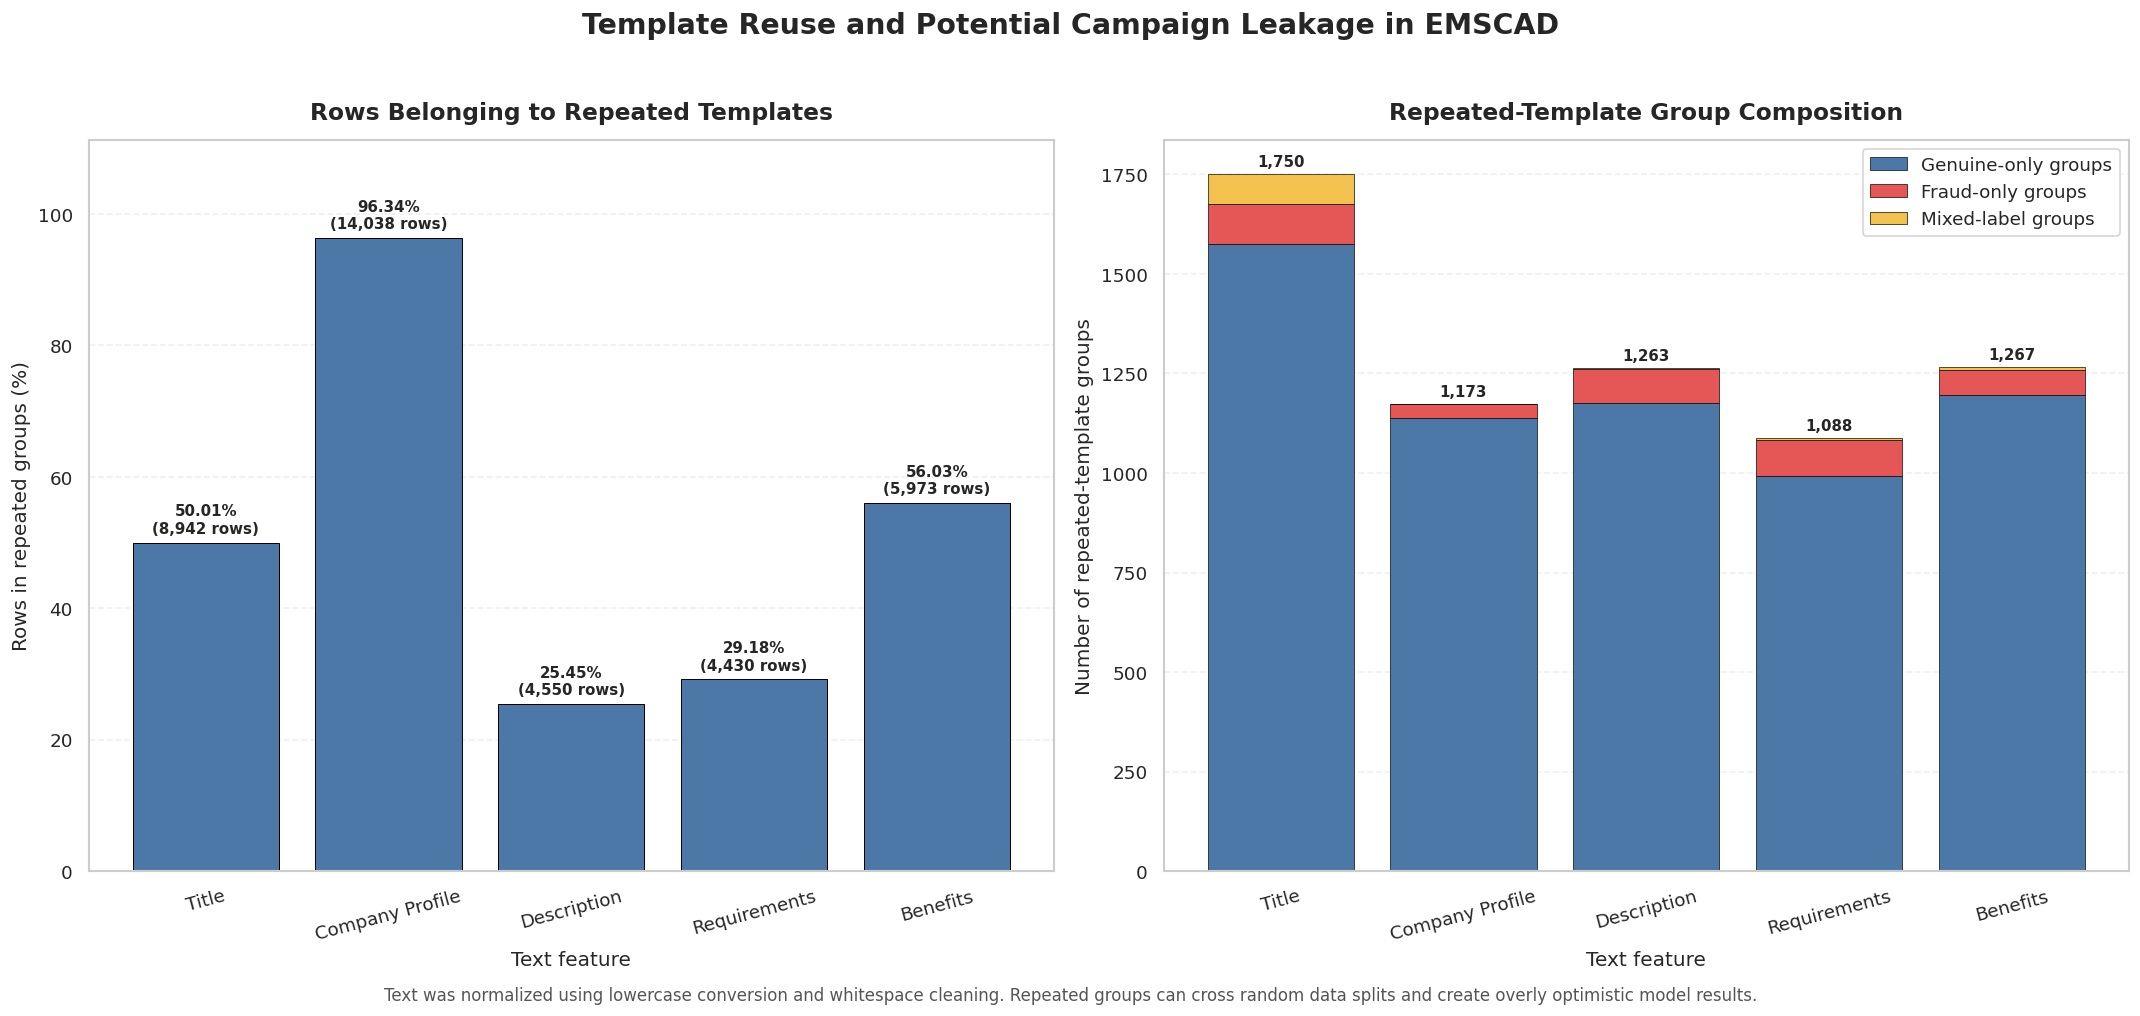

Table saved: /kaggle/working/emscad_complete_eda/tables/repeated_template_summary.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/15_repeated_template_analysis.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/15_repeated_template_analysis.pdf


In [21]:
# ================================================================
# STEP 17: REPEATED TEMPLATE AND CAMPAIGN ANALYSIS
# ================================================================

template_features = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

template_summary_rows = []

for feature in template_features:

    # Normalize only case and unnecessary spacing
    normalized_templates = (
        df[feature]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )

    non_empty_mask = (
        normalized_templates.ne("")
    )

    template_frame = pd.DataFrame({
        "Template":
            normalized_templates[
                non_empty_mask
            ],
        "Fraudulent":
            df.loc[
                non_empty_mask,
                "fraudulent"
            ].values
    })

    template_groups = (
        template_frame
        .groupby("Template")["Fraudulent"]
        .agg(
            Group_Size="count",
            Minimum_Label="min",
            Maximum_Label="max",
            Unique_Labels="nunique"
        )
        .reset_index()
    )

    repeated_groups = template_groups[
        template_groups["Group_Size"] > 1
    ].copy()

    non_empty_rows = int(
        non_empty_mask.sum()
    )

    unique_templates = int(
        template_groups.shape[0]
    )

    repeated_template_groups = int(
        repeated_groups.shape[0]
    )

    rows_in_repeated_groups = int(
        repeated_groups[
            "Group_Size"
        ].sum()
    )

    largest_template_group = int(
        repeated_groups[
            "Group_Size"
        ].max()
        if repeated_template_groups > 0
        else 1
    )

    fraud_only_groups = int(
        (
            (repeated_groups["Minimum_Label"] == 1)
            & (repeated_groups["Maximum_Label"] == 1)
        ).sum()
    )

    genuine_only_groups = int(
        (
            (repeated_groups["Minimum_Label"] == 0)
            & (repeated_groups["Maximum_Label"] == 0)
        ).sum()
    )

    mixed_label_groups = int(
        (
            repeated_groups["Unique_Labels"] > 1
        ).sum()
    )

    rows_in_mixed_groups = int(
        repeated_groups.loc[
            repeated_groups[
                "Unique_Labels"
            ] > 1,
            "Group_Size"
        ].sum()
    )

    template_summary_rows.append({
        "Feature": feature,
        "Non_Empty_Rows":
            non_empty_rows,
        "Unique_Templates":
            unique_templates,
        "Unique_Percentage":
            round(
                unique_templates
                / non_empty_rows
                * 100,
                2
            ),
        "Repeated_Template_Groups":
            repeated_template_groups,
        "Rows_In_Repeated_Groups":
            rows_in_repeated_groups,
        "Repeated_Row_Percentage":
            round(
                rows_in_repeated_groups
                / non_empty_rows
                * 100,
                2
            ),
        "Largest_Template_Group":
            largest_template_group,
        "Fraud_Only_Groups":
            fraud_only_groups,
        "Genuine_Only_Groups":
            genuine_only_groups,
        "Mixed_Label_Groups":
            mixed_label_groups,
        "Rows_In_Mixed_Groups":
            rows_in_mixed_groups
    })

template_summary = pd.DataFrame(
    template_summary_rows
)

print("=" * 70)
print("REPEATED TEMPLATE AND CAMPAIGN ANALYSIS")
print("=" * 70)

display(template_summary)

# Save table
template_summary_path = os.path.join(
    TABLE_DIR,
    "repeated_template_summary.csv"
)

template_summary.to_csv(
    template_summary_path,
    index=False
)

# ------------------------------------------------
# Create two-panel graph
# ------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

feature_labels = (
    template_summary["Feature"]
    .str.replace("_", " ")
    .str.title()
)

# Panel 1: percentage of rows in repeated groups
repeat_bars = axes[0].bar(
    feature_labels,
    template_summary[
        "Repeated_Row_Percentage"
    ],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.6
)

for bar, percentage, rows in zip(
    repeat_bars,
    template_summary[
        "Repeated_Row_Percentage"
    ],
    template_summary[
        "Rows_In_Repeated_Groups"
    ]
):

    axes[0].text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 1,
        (
            f"{percentage:.2f}%\n"
            f"({rows:,} rows)"
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

axes[0].set_title(
    "Rows Belonging to Repeated Templates",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel("Text feature")
axes[0].set_ylabel(
    "Rows in repeated groups (%)"
)

axes[0].tick_params(
    axis="x",
    rotation=15
)

axes[0].set_ylim(
    0,
    template_summary[
        "Repeated_Row_Percentage"
    ].max() + 15
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

axes[0].grid(
    axis="x",
    visible=False
)

# Panel 2: repeated-group label composition
genuine_values = (
    template_summary[
        "Genuine_Only_Groups"
    ]
)

fraud_values = (
    template_summary[
        "Fraud_Only_Groups"
    ]
)

mixed_values = (
    template_summary[
        "Mixed_Label_Groups"
    ]
)

axes[1].bar(
    feature_labels,
    genuine_values,
    label="Genuine-only groups",
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.4
)

axes[1].bar(
    feature_labels,
    fraud_values,
    bottom=genuine_values,
    label="Fraud-only groups",
    color="#E45756",
    edgecolor="black",
    linewidth=0.4
)

axes[1].bar(
    feature_labels,
    mixed_values,
    bottom=(
        genuine_values
        + fraud_values
    ),
    label="Mixed-label groups",
    color="#F2C14E",
    edgecolor="black",
    linewidth=0.4
)

for index, total in enumerate(
    template_summary[
        "Repeated_Template_Groups"
    ]
):

    axes[1].text(
        index,
        total + 20,
        f"{total:,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

axes[1].set_title(
    "Repeated-Template Group Composition",
    fontsize=14,
    pad=12
)

axes[1].set_xlabel("Text feature")
axes[1].set_ylabel(
    "Number of repeated-template groups"
)

axes[1].tick_params(
    axis="x",
    rotation=15
)

axes[1].legend(
    loc="upper right"
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

axes[1].grid(
    axis="x",
    visible=False
)

fig.suptitle(
    "Template Reuse and Potential Campaign Leakage in EMSCAD",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Text was normalized using lowercase conversion and whitespace "
    "cleaning. Repeated groups can cross random data splits and "
    "create overly optimistic model results.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

template_png = os.path.join(
    FIGURE_DIR,
    "15_repeated_template_analysis.png"
)

template_pdf = os.path.join(
    FIGURE_DIR,
    "15_repeated_template_analysis.pdf"
)

plt.savefig(
    template_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    template_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", template_summary_path)
print("PNG graph saved:", template_png)
print("PDF graph saved:", template_pdf)

FEATURE CARDINALITY AND UNIQUENESS


,Feature,Non_Empty_Values,Missing_or_Empty,Unique_Values,Repeated_Value_Count,Unique_Percentage,Cardinality_Type
0,description,17878,2,14665,3213,82.03,High-cardinality
1,requirements,15182,2698,11898,3284,78.37,High-cardinality
2,title,17880,0,10915,6965,61.05,High-cardinality
3,benefits,10660,7220,6079,4581,57.03,High-cardinality
4,location,17534,346,2990,14544,17.05,Medium-cardinality
5,company_profile,14572,3308,1708,12864,11.72,Medium-cardinality
6,department,6327,11553,1276,5051,20.17,Medium-cardinality
7,salary_range,2868,15012,874,1994,30.47,Medium-cardinality
8,industry,12977,4903,131,12846,1.01,Low-cardinality
9,function,11425,6455,37,11388,0.32,Low-cardinality


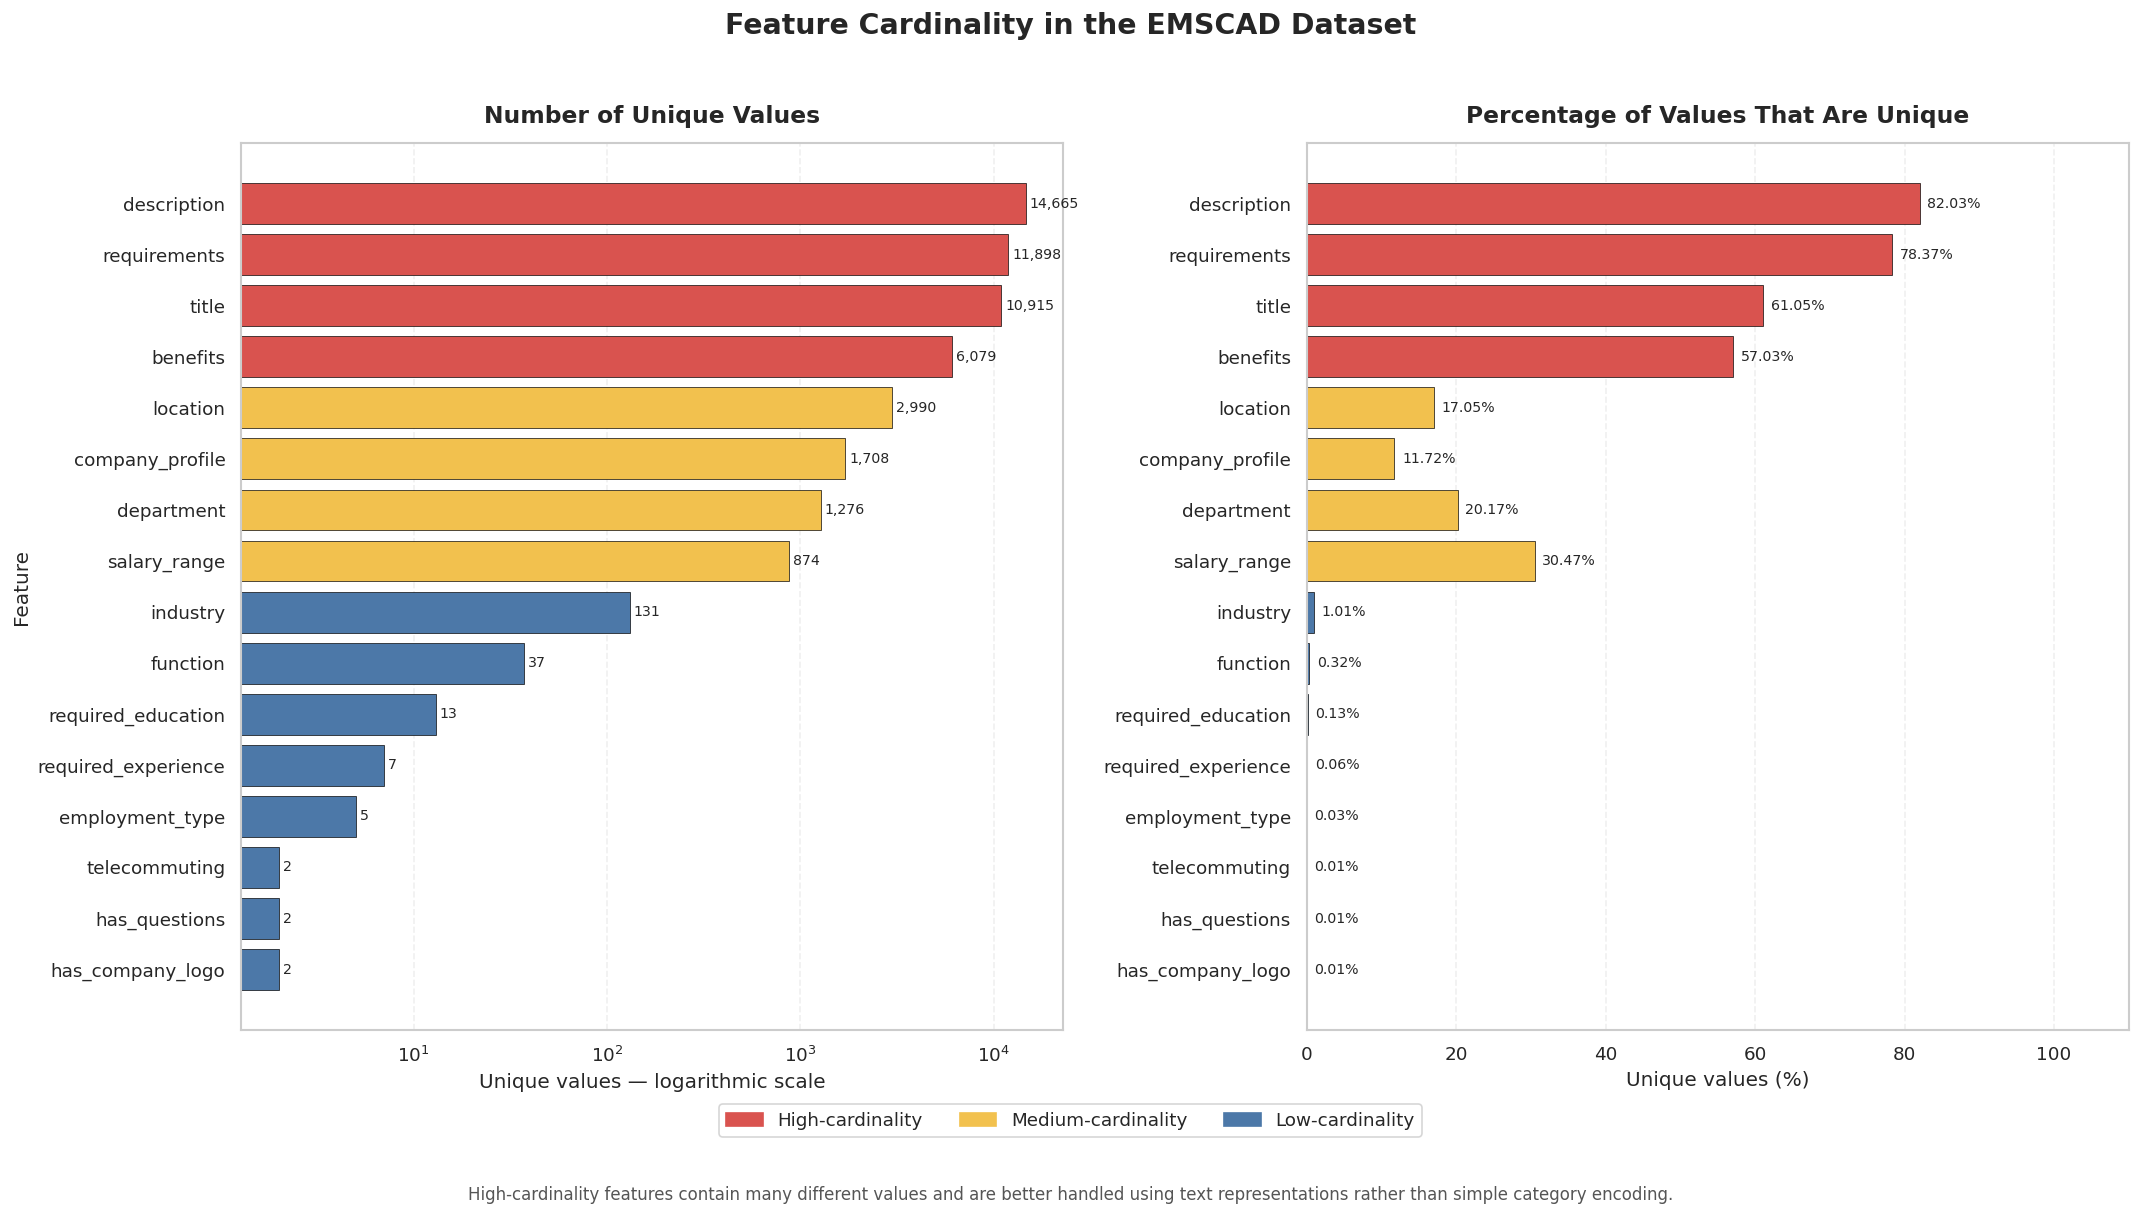

Table saved: /kaggle/working/emscad_complete_eda/tables/feature_cardinality_summary.csv
PNG graph saved: /kaggle/working/emscad_complete_eda/figures/16_feature_cardinality.png
PDF graph saved: /kaggle/working/emscad_complete_eda/figures/16_feature_cardinality.pdf


In [22]:
# ================================================================
# STEP 18: FEATURE CARDINALITY AND UNIQUENESS ANALYSIS
# ================================================================

cardinality_rows = []

feature_columns = [
    column
    for column in df.columns
    if column not in [
        "job_id",
        "fraudulent"
    ]
]

for feature in feature_columns:

    feature_values = (
        df[feature]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    non_empty_values = feature_values[
        feature_values.ne("")
    ]

    non_empty_count = int(
        len(non_empty_values)
    )

    unique_count = int(
        non_empty_values.nunique()
    )

    repeated_value_count = int(
        non_empty_count
        - unique_count
    )

    uniqueness_percentage = (
        unique_count
        / non_empty_count
        * 100
        if non_empty_count > 0
        else 0
    )

    if uniqueness_percentage >= 50:
        feature_type = "High-cardinality"
    elif uniqueness_percentage >= 5:
        feature_type = "Medium-cardinality"
    else:
        feature_type = "Low-cardinality"

    cardinality_rows.append({
        "Feature": feature,
        "Non_Empty_Values":
            non_empty_count,
        "Missing_or_Empty":
            int(len(df) - non_empty_count),
        "Unique_Values":
            unique_count,
        "Repeated_Value_Count":
            repeated_value_count,
        "Unique_Percentage":
            round(
                uniqueness_percentage,
                2
            ),
        "Cardinality_Type":
            feature_type
    })

cardinality_summary = (
    pd.DataFrame(cardinality_rows)
    .sort_values(
        "Unique_Values",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("FEATURE CARDINALITY AND UNIQUENESS")
print("=" * 70)

display(cardinality_summary)

# Save table
cardinality_table_path = os.path.join(
    TABLE_DIR,
    "feature_cardinality_summary.csv"
)

cardinality_summary.to_csv(
    cardinality_table_path,
    index=False
)

# ------------------------------------------------
# Prepare graph data
# ------------------------------------------------

graph_data = cardinality_summary.sort_values(
    "Unique_Values",
    ascending=True
)

cardinality_colors = {
    "High-cardinality": "#D9534F",
    "Medium-cardinality": "#F2C14E",
    "Low-cardinality": "#4C78A8"
}

bar_colors = [
    cardinality_colors[value]
    for value
    in graph_data["Cardinality_Type"]
]

# ------------------------------------------------
# Create two-panel graph
# ------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 9)
)

# Panel 1: unique-value count
unique_bars = axes[0].barh(
    graph_data["Feature"],
    graph_data["Unique_Values"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)

for bar, count in zip(
    unique_bars,
    graph_data["Unique_Values"]
):

    axes[0].text(
        bar.get_width() * 1.05,
        bar.get_y()
        + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=8.5
    )

axes[0].set_xscale("log")

axes[0].set_title(
    "Number of Unique Values",
    fontsize=14,
    pad=12
)

axes[0].set_xlabel(
    "Unique values — logarithmic scale"
)

axes[0].set_ylabel("Feature")

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].grid(
    axis="y",
    visible=False
)

# Panel 2: uniqueness percentage
percentage_bars = axes[1].barh(
    graph_data["Feature"],
    graph_data["Unique_Percentage"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)

for bar, percentage in zip(
    percentage_bars,
    graph_data["Unique_Percentage"]
):

    axes[1].text(
        bar.get_width() + 1,
        bar.get_y()
        + bar.get_height() / 2,
        f"{percentage:.2f}%",
        va="center",
        fontsize=8.5
    )

axes[1].set_title(
    "Percentage of Values That Are Unique",
    fontsize=14,
    pad=12
)

axes[1].set_xlabel("Unique values (%)")
axes[1].set_ylabel("")

axes[1].set_xlim(
    0,
    110
)

axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[1].grid(
    axis="y",
    visible=False
)

# Shared legend
legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=color,
        label=label
    )
    for label, color
    in cardinality_colors.items()
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Feature Cardinality in the EMSCAD Dataset",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.08,
    "High-cardinality features contain many different values and "
    "are better handled using text representations rather than "
    "simple category encoding.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

cardinality_png = os.path.join(
    FIGURE_DIR,
    "16_feature_cardinality.png"
)

cardinality_pdf = os.path.join(
    FIGURE_DIR,
    "16_feature_cardinality.pdf"
)

plt.savefig(
    cardinality_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    cardinality_pdf,
    bbox_inches="tight"
)

plt.show()

print("Table saved:", cardinality_table_path)
print("PNG graph saved:", cardinality_png)
print("PDF graph saved:", cardinality_pdf)

In [23]:
"""Final EMSCAD EDA statistical tests, PDF report, and ZIP exporter.

Paste this entire file into one Kaggle notebook code cell after the previous
EDA cells and run it once. It does not train a model or use validation/test
labels; it summarizes the full EMSCAD dataset for exploratory analysis only.
"""

from __future__ import annotations

import hashlib
import json
import math
import os
import re
import textwrap
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------------
# 1. Paths and dataset loading
# ---------------------------------------------------------------------------

KAGGLE_WORKING = Path("/kaggle/working")
WORKING_ROOT = KAGGLE_WORKING if KAGGLE_WORKING.exists() else Path.cwd()
EDA_OUTPUT = WORKING_ROOT / "emscad_complete_eda"
FIGURE_DIR = EDA_OUTPUT / "figures"
TABLE_DIR = EDA_OUTPUT / "tables"
REPORT_DIR = EDA_OUTPUT / "report"

for directory in (EDA_OUTPUT, FIGURE_DIR, TABLE_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def find_dataset() -> Path:
    """Find the EMSCAD CSV without depending on a hard-coded Kaggle owner."""
    preferred = Path(
        "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    )
    if preferred.exists():
        return preferred

    search_roots = [
        Path("/kaggle/input"),
        Path.cwd(),
        Path.cwd() / "upload",
        Path.cwd() / "tmp",
    ]
    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(root.rglob("fake_job_postings.csv"))

    candidates = sorted({path.resolve() for path in candidates})
    if not candidates:
        raise FileNotFoundError(
            "fake_job_postings.csv was not found. Add the Kaggle dataset first."
        )
    return candidates[0]


if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
    df = globals()["df"].copy(deep=True)
    dataset_path = Path("notebook-memory:df")
else:
    dataset_path = find_dataset()
    df = pd.read_csv(dataset_path)

required_columns = {"job_id", "fraudulent"}
missing_required = required_columns.difference(df.columns)
if missing_required:
    raise KeyError(f"Dataset is missing required columns: {sorted(missing_required)}")

if not set(pd.Series(df["fraudulent"]).dropna().unique()).issubset({0, 1}):
    raise ValueError("The fraudulent target must contain only 0 and 1.")

df = df.reset_index(drop=True)
target = df["fraudulent"].astype(int)


# ---------------------------------------------------------------------------
# 2. Rebuild only the EDA features required by this final report
# ---------------------------------------------------------------------------

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
]

for column in text_columns:
    if column not in df.columns:
        df[column] = ""


def clean_text(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()


def missing_or_empty(series: pd.Series) -> pd.Series:
    return series.isna() | series.fillna("").astype(str).str.strip().eq("")


clean_sections = {column: clean_text(df[column]) for column in text_columns}
combined_text = pd.Series("", index=df.index, dtype="object")
for column in text_columns:
    combined_text = combined_text.str.cat(clean_sections[column], sep=" ")
combined_text = clean_text(combined_text)

input_columns = [column for column in df.columns if column not in {"job_id", "fraudulent"}]
missing_fields_count = pd.Series(0, index=df.index, dtype="int64")
for column in input_columns:
    missing_fields_count += missing_or_empty(df[column]).astype(int)

continuous_features = pd.DataFrame(index=df.index)
for column in text_columns:
    continuous_features[f"{column}_word_count"] = (
        clean_sections[column].str.findall(r"\b\w+\b").str.len().astype(float)
    )

continuous_features["total_words"] = (
    combined_text.str.findall(r"\b\w+\b").str.len().astype(float)
)
continuous_features["missing_fields_count"] = missing_fields_count.astype(float)
continuous_features["uppercase_word_count"] = (
    combined_text.str.findall(r"\b[A-Z]{3,}\b").str.len().astype(float)
)
continuous_features["digit_count"] = combined_text.str.count(r"\d").astype(float)
continuous_features["exclamation_count"] = combined_text.str.count(r"!").astype(float)

signal_patterns = {
    "work_from_home_language": r"\b(work\s*from\s*home|work\s*at\s*home|remote\s+work)\b",
    "no_experience_language": r"\b(no\s+experience|experience\s+not\s+required)\b",
    "money_language": r"\b(earn|income|money|weekly\s+pay|daily\s+pay|quick\s+cash)\b",
    "phone_like_number": r"(?:\+?\d[\d\s().-]{7,}\d)",
    "multiple_exclamation_marks": r"!{2,}",
    "contains_url": r"(?:https?://|www\.)",
    "contains_email": r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b",
    "whatsapp_or_telegram": r"\b(whatsapp|telegram)\b",
}

signal_frame = pd.DataFrame(index=df.index)
for signal_name, pattern in signal_patterns.items():
    signal_frame[signal_name] = combined_text.str.contains(
        pattern, case=False, regex=True, na=False
    ).astype(int)
continuous_features["suspicious_signal_count"] = signal_frame.sum(axis=1).astype(float)


def extract_country(location_series: pd.Series) -> pd.Series:
    return (
        location_series.fillna("Missing").astype(str).str.split(",").str[0]
        .str.strip().replace("", "Missing")
    )


def salary_status(value: object) -> str:
    if pd.isna(value) or not str(value).strip():
        return "Missing"
    numbers = re.findall(r"\d+(?:\.\d+)?", str(value).replace(",", ""))
    return "Valid numeric range" if len(numbers) >= 2 else "Provided but unparsed"


categorical_feature_series = {}
for column in [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
]:
    if column in df.columns:
        categorical_feature_series[column] = df[column]

if "location" in df.columns:
    categorical_feature_series["country"] = extract_country(df["location"])
if "salary_range" in df.columns:
    categorical_feature_series["salary_status"] = df["salary_range"].map(salary_status)


# ---------------------------------------------------------------------------
# 3. Statistical significance and effect-size tests
# ---------------------------------------------------------------------------

def benjamini_hochberg(p_values: pd.Series) -> pd.Series:
    values = pd.to_numeric(p_values, errors="coerce").to_numpy(dtype=float)
    adjusted = np.full(len(values), np.nan, dtype=float)
    valid = np.isfinite(values)
    if not valid.any():
        return pd.Series(adjusted, index=p_values.index)
    valid_values = values[valid]
    order = np.argsort(valid_values)
    ranked = valid_values[order]
    count = len(ranked)
    corrected = ranked * count / np.arange(1, count + 1)
    corrected = np.minimum.accumulate(corrected[::-1])[::-1]
    corrected = np.clip(corrected, 0.0, 1.0)
    restored = np.empty(count, dtype=float)
    restored[order] = corrected
    adjusted[np.where(valid)[0]] = restored
    return pd.Series(adjusted, index=p_values.index)


def effect_label(value: float) -> str:
    magnitude = abs(float(value))
    if magnitude < 0.10:
        return "Negligible"
    if magnitude < 0.30:
        return "Small"
    if magnitude < 0.50:
        return "Medium"
    return "Large"


categorical_rows = []
for feature_name, original_series in categorical_feature_series.items():
    series = original_series.fillna("Missing").astype(str).str.strip().replace("", "Missing")
    counts = series.value_counts(dropna=False)
    retained = counts[counts >= 20].index
    grouped = series.where(series.isin(retained), "Other_or_Rare")
    table = pd.crosstab(grouped, target)

    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    chi_square, p_value, degrees_freedom, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    phi_squared = chi_square / n
    rows, columns = table.shape
    corrected_phi = max(0.0, phi_squared - ((columns - 1) * (rows - 1)) / (n - 1))
    corrected_rows = rows - ((rows - 1) ** 2) / (n - 1)
    corrected_columns = columns - ((columns - 1) ** 2) / (n - 1)
    denominator = max(1e-12, min(corrected_columns - 1, corrected_rows - 1))
    cramers_v = math.sqrt(corrected_phi / denominator)

    categorical_rows.append(
        {
            "Feature": feature_name,
            "Levels_After_Rare_Grouping": int(rows),
            "Chi_Square": float(chi_square),
            "Degrees_of_Freedom": int(degrees_freedom),
            "P_Value": float(p_value),
            "Cramers_V": float(cramers_v),
            "Effect_Size": effect_label(cramers_v),
        }
    )

categorical_tests = pd.DataFrame(categorical_rows)
if not categorical_tests.empty:
    categorical_tests["Adjusted_P_Value_BH"] = benjamini_hochberg(categorical_tests["P_Value"])
    categorical_tests["Significant_After_BH_0.05"] = categorical_tests[
        "Adjusted_P_Value_BH"
    ].lt(0.05)
    categorical_tests = categorical_tests.sort_values(
        ["Cramers_V", "Adjusted_P_Value_BH"], ascending=[False, True]
    ).reset_index(drop=True)

continuous_rows = []
for feature_name in continuous_features.columns:
    values = pd.to_numeric(continuous_features[feature_name], errors="coerce")
    genuine = values[target.eq(0)].dropna().to_numpy(dtype=float)
    fraud = values[target.eq(1)].dropna().to_numpy(dtype=float)
    if len(genuine) == 0 or len(fraud) == 0:
        continue
    u_statistic, p_value = mannwhitneyu(fraud, genuine, alternative="two-sided")
    rank_biserial = (2.0 * u_statistic) / (len(fraud) * len(genuine)) - 1.0
    continuous_rows.append(
        {
            "Feature": feature_name,
            "Genuine_Median": float(np.median(genuine)),
            "Fraud_Median": float(np.median(fraud)),
            "Mann_Whitney_U": float(u_statistic),
            "P_Value": float(p_value),
            "Rank_Biserial_Correlation": float(rank_biserial),
            "Effect_Size": effect_label(rank_biserial),
        }
    )

continuous_tests = pd.DataFrame(continuous_rows)
if not continuous_tests.empty:
    continuous_tests["Adjusted_P_Value_BH"] = benjamini_hochberg(continuous_tests["P_Value"])
    continuous_tests["Significant_After_BH_0.05"] = continuous_tests[
        "Adjusted_P_Value_BH"
    ].lt(0.05)
    continuous_tests["Absolute_Effect"] = continuous_tests[
        "Rank_Biserial_Correlation"
    ].abs()
    continuous_tests = continuous_tests.sort_values(
        ["Absolute_Effect", "Adjusted_P_Value_BH"], ascending=[False, True]
    ).reset_index(drop=True)

categorical_csv = TABLE_DIR / "17_categorical_significance_tests.csv"
continuous_csv = TABLE_DIR / "18_continuous_significance_tests.csv"
categorical_tests.to_csv(categorical_csv, index=False)
continuous_tests.to_csv(continuous_csv, index=False)


# ---------------------------------------------------------------------------
# 4. Data-driven final EDA findings
# ---------------------------------------------------------------------------

row_count, column_count = df.shape
fraud_count = int(target.sum())
genuine_count = int((target == 0).sum())
fraud_rate = 100.0 * fraud_count / row_count
imbalance_ratio = genuine_count / max(1, fraud_count)

missing_summary = pd.DataFrame(
    {
        "Feature": input_columns,
        "Missing_Count": [int(missing_or_empty(df[column]).sum()) for column in input_columns],
    }
)
missing_summary["Missing_Percentage"] = 100.0 * missing_summary["Missing_Count"] / row_count
missing_summary = missing_summary.sort_values("Missing_Percentage", ascending=False).reset_index(drop=True)

top_missing = missing_summary.iloc[0] if not missing_summary.empty else None
top_categorical = categorical_tests.iloc[0] if not categorical_tests.empty else None
top_continuous = continuous_tests.iloc[0] if not continuous_tests.empty else None

exact_duplicates = int(df.duplicated().sum())
duplicate_excluding_id = int(df.drop(columns=["job_id"], errors="ignore").duplicated().sum())

findings = [
    f"The EMSCAD dataset contains {row_count:,} job posts and {column_count} columns.",
    f"Fraud is rare: {fraud_count:,} posts ({fraud_rate:.2f}%) versus "
    f"{genuine_count:,} genuine posts, an imbalance of about {imbalance_ratio:.1f}:1.",
    f"There are {exact_duplicates:,} exact duplicate rows and {duplicate_excluding_id:,} "
    "extra duplicate copies when job_id is ignored.",
]

if top_missing is not None:
    findings.append(
        f"The most incomplete field is {top_missing['Feature']} "
        f"({top_missing['Missing_Percentage']:.2f}% missing or empty)."
    )
if top_categorical is not None:
    findings.append(
        f"The strongest tested categorical association is {top_categorical['Feature']} "
        f"(bias-corrected Cramer's V = {top_categorical['Cramers_V']:.3f}, "
        f"BH-adjusted p = {top_categorical['Adjusted_P_Value_BH']:.3g})."
    )
if top_continuous is not None:
    findings.append(
        f"The strongest tested numeric/text difference is {top_continuous['Feature']} "
        f"(rank-biserial correlation = {top_continuous['Rank_Biserial_Correlation']:.3f}, "
        f"BH-adjusted p = {top_continuous['Adjusted_P_Value_BH']:.3g})."
    )

findings.extend(
    [
        "Missingness, short or repeated text, metadata, and suspicious wording are useful "
        "candidate signals, but none should be interpreted as proof of fraud by itself.",
        "Repeated templates can leak across random splits. Model experiments should therefore "
        "use campaign/template-group isolation as the primary research protocol.",
        "All feature selection, threshold choice, and model tuning must use training/validation "
        "data only; the untouched test set must remain sealed until the final evaluation.",
    ]
)

summary_rows = [
    ("Rows", row_count),
    ("Columns", column_count),
    ("Genuine posts", genuine_count),
    ("Fraudulent posts", fraud_count),
    ("Fraud rate (%)", round(fraud_rate, 4)),
    ("Genuine-to-fraud ratio", round(imbalance_ratio, 4)),
    ("Exact duplicate rows", exact_duplicates),
    ("Duplicate copies excluding job_id", duplicate_excluding_id),
    ("Categorical tests", len(categorical_tests)),
    ("Continuous tests", len(continuous_tests)),
]
final_summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
final_summary.to_csv(TABLE_DIR / "19_final_eda_summary.csv", index=False)
missing_summary.to_csv(TABLE_DIR / "20_final_missingness_summary.csv", index=False)

findings_text_path = REPORT_DIR / "final_eda_findings.txt"
findings_text_path.write_text("\n".join(f"- {item}" for item in findings), encoding="utf-8")


# ---------------------------------------------------------------------------
# 5. Create a clear multi-page PDF report
# ---------------------------------------------------------------------------

PDF_PATH = REPORT_DIR / "EMSCAD_Complete_EDA_Report.pdf"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "figure.facecolor": "white",
    }
)

NAVY = "#123B5D"
BLUE = "#245B86"
GOLD = "#E7B53B"
LIGHT = "#F3F6F8"
TEXT = "#1E2933"

page_counter = 0


def finish_page(pdf: PdfPages, figure: plt.Figure, page_title: str) -> None:
    global page_counter
    page_counter += 1
    figure.text(0.965, 0.025, f"Page {page_counter}", ha="right", va="bottom", fontsize=8, color="#66727C")
    figure.text(0.035, 0.025, "EMSCAD Fraudulent Job Posting EDA", ha="left", va="bottom", fontsize=8, color="#66727C")
    pdf.savefig(figure, bbox_inches="tight", facecolor="white")
    plt.close(figure)


def add_text_page(pdf: PdfPages, title: str, paragraphs: list[str]) -> None:
    figure = plt.figure(figsize=(11.69, 8.27))
    figure.patches.extend(
        [plt.Rectangle((0, 0.91), 1, 0.09, transform=figure.transFigure, color=NAVY, zorder=-1)]
    )
    figure.text(0.045, 0.945, title, color="white", fontsize=20, weight="bold", va="center")
    y = 0.855
    for paragraph in paragraphs:
        wrapped = textwrap.fill(str(paragraph), width=118)
        line_count = wrapped.count("\n") + 1
        figure.text(0.06, y, wrapped, fontsize=11, color=TEXT, va="top", linespacing=1.45)
        y -= 0.048 * line_count + 0.035
        if y < 0.09:
            break
    finish_page(pdf, figure, title)


def add_table_pages(
    pdf: PdfPages,
    title: str,
    frame: pd.DataFrame,
    columns: list[str],
    rows_per_page: int = 14,
) -> None:
    if frame.empty:
        add_text_page(pdf, title, ["No valid results were available for this table."])
        return
    display_frame = frame.loc[:, [column for column in columns if column in frame.columns]].copy()
    for column in display_frame.select_dtypes(include=["float"]).columns:
        display_frame[column] = display_frame[column].map(lambda value: f"{value:.4g}")

    total_parts = math.ceil(len(display_frame) / rows_per_page)
    for part in range(total_parts):
        subset = display_frame.iloc[part * rows_per_page : (part + 1) * rows_per_page]
        figure, axis = plt.subplots(figsize=(11.69, 8.27))
        axis.axis("off")
        part_title = title if total_parts == 1 else f"{title} ({part + 1}/{total_parts})"
        figure.suptitle(part_title, fontsize=18, weight="bold", color=NAVY, y=0.95)
        table = axis.table(
            cellText=subset.values,
            colLabels=subset.columns,
            cellLoc="center",
            colLoc="center",
            bbox=[0.02, 0.10, 0.96, 0.76],
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8.2)
        for (row, column), cell in table.get_celld().items():
            cell.set_edgecolor("#D4DDE3")
            if row == 0:
                cell.set_facecolor(BLUE)
                cell.set_text_props(color="white", weight="bold")
            elif row % 2 == 0:
                cell.set_facecolor(LIGHT)
        finish_page(pdf, figure, part_title)


figure_captions = {
    "01": "Missing values show which EMSCAD fields require explicit missingness handling.",
    "02": "The target is severely imbalanced, so accuracy alone is not an adequate metric.",
    "03": "Duplicate and repeated content can create optimistic results under random splitting.",
    "04": "Binary metadata indicators have different observed fraud rates.",
    "05": "Missingness itself can be predictive and should be represented explicitly.",
    "06": "Fraud rate changes with the number of missing fields, but the relationship is not monotonic.",
    "07": "Text-length distributions differ across genuine and fraudulent job posts.",
    "08": "Selected categorical levels show different fraud rates; small groups need cautious interpretation.",
    "09": "Industry and function risk lifts highlight concentrated categories, not causal effects.",
    "10": "Country-level fraud rates are affected by geography and sample size.",
    "11": "Salary availability and parseability provide a useful structural signal.",
    "12": "Suspicious-language rules are interpretable candidate features, not final decisions.",
    "13": "The correlation view identifies redundant engineered numeric features.",
    "14": "Lexical association highlights terms that differ between the two classes.",
    "15": "Repeated templates motivate campaign-isolated validation and test splits.",
    "16": "Feature cardinality guides encoding choices for categorical and text fields.",
}


def add_figure_page(pdf: PdfPages, image_path: Path) -> None:
    prefix = image_path.stem.split("_")[0]
    caption = figure_captions.get(prefix, image_path.stem.replace("_", " ").title())
    figure = plt.figure(figsize=(11.69, 8.27))
    figure.suptitle(image_path.stem.replace("_", " ").title(), fontsize=17, weight="bold", color=NAVY, y=0.96)
    axis = figure.add_axes([0.055, 0.13, 0.89, 0.75])
    axis.axis("off")
    image = plt.imread(image_path)
    axis.imshow(image)
    figure.text(0.055, 0.075, textwrap.fill(caption, width=125), fontsize=9.5, color=TEXT, va="top")
    finish_page(pdf, figure, image_path.stem)


figure_files = sorted(FIGURE_DIR.glob("*.png"))

with PdfPages(PDF_PATH) as pdf:
    metadata = pdf.infodict()
    metadata["Title"] = "Comprehensive Exploratory Data Analysis of EMSCAD"
    metadata["Author"] = "SAGE-FJD Research Project"
    metadata["Subject"] = "Fraudulent job posting detection - EMSCAD exploratory analysis"
    metadata["Keywords"] = "EMSCAD, fake jobs, fraud detection, EDA, machine learning"
    metadata["CreationDate"] = datetime.now(timezone.utc)

    cover = plt.figure(figsize=(11.69, 8.27))
    cover.patch.set_facecolor("white")
    cover.patches.extend(
        [
            plt.Rectangle((0, 0.58), 1, 0.42, transform=cover.transFigure, color=NAVY, zorder=-1),
            plt.Rectangle((0, 0.55), 1, 0.03, transform=cover.transFigure, color=GOLD, zorder=-1),
        ]
    )
    cover.text(0.07, 0.80, "EMSCAD", fontsize=31, color=GOLD, weight="bold")
    cover.text(0.07, 0.70, "Comprehensive Exploratory Data Analysis", fontsize=25, color="white", weight="bold")
    cover.text(0.07, 0.625, "Fraudulent Job Posting Detection", fontsize=18, color="white")
    cover.text(0.07, 0.45, f"Dataset: {row_count:,} rows | {column_count} columns", fontsize=15, color=TEXT)
    cover.text(0.07, 0.39, f"Fraudulent posts: {fraud_count:,} ({fraud_rate:.2f}%)", fontsize=15, color=TEXT)
    cover.text(0.07, 0.29, "Purpose", fontsize=14, color=NAVY, weight="bold")
    cover.text(
        0.07,
        0.245,
        textwrap.fill(
            "Document data quality, class imbalance, missingness, textual structure, "
            "categorical risk, suspicious-language signals, repeated templates, and "
            "statistical evidence before leakage-safe model development.",
            width=95,
        ),
        fontsize=11.5,
        color=TEXT,
        va="top",
        linespacing=1.5,
    )
    finish_page(pdf, cover, "Cover")

    add_text_page(pdf, "Dataset Overview", [f"{metric}: {value}" for metric, value in summary_rows])
    add_text_page(pdf, "Evidence-Based EDA Findings", findings)

    add_table_pages(
        pdf,
        "Categorical Association Tests",
        categorical_tests,
        ["Feature", "Levels_After_Rare_Grouping", "Cramers_V", "Effect_Size", "Adjusted_P_Value_BH", "Significant_After_BH_0.05"],
    )
    add_table_pages(
        pdf,
        "Continuous and Text Feature Tests",
        continuous_tests,
        ["Feature", "Genuine_Median", "Fraud_Median", "Rank_Biserial_Correlation", "Effect_Size", "Adjusted_P_Value_BH", "Significant_After_BH_0.05"],
    )

    for figure_path in figure_files:
        try:
            add_figure_page(pdf, figure_path)
        except Exception as error:
            add_text_page(
                pdf,
                f"Figure could not be embedded: {figure_path.name}",
                [f"Reason: {type(error).__name__}: {error}"],
            )

    add_text_page(
        pdf,
        "Methodological Boundaries and Next Steps",
        [
            "This report is exploratory. Statistical significance does not prove causation, and "
            "large samples can make small effects statistically significant.",
            "Rare categorical levels were grouped when they contained fewer than 20 rows. P-values "
            "were adjusted with the Benjamini-Hochberg procedure to limit false discoveries.",
            "The Mann-Whitney U test was used because engineered text/count features are not assumed "
            "to follow a normal distribution. Rank-biserial correlation reports effect direction and size.",
            "Do not use full-dataset EDA to choose features after viewing locked validation or test results. "
            "Confirm every modelling claim under the pre-registered campaign-isolated protocol.",
            "For model reporting, prioritize fraud-class precision, recall, F1, PR-AUC, balanced accuracy, "
            "MCC, calibration, confusion counts, and confidence intervals alongside ordinary accuracy.",
        ],
    )


# ---------------------------------------------------------------------------
# 6. Validate outputs, write manifest, and create one downloadable ZIP
# ---------------------------------------------------------------------------

if not PDF_PATH.exists() or PDF_PATH.stat().st_size < 20_000:
    raise RuntimeError("PDF creation failed or produced an unexpectedly small file.")


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_source": str(dataset_path),
    "dataset_rows": row_count,
    "dataset_columns": column_count,
    "fraudulent_rows": fraud_count,
    "fraud_rate_percentage": round(fraud_rate, 6),
    "pdf_pages_created": page_counter,
    "figures_embedded": len(figure_files),
    "categorical_tests": len(categorical_tests),
    "continuous_tests": len(continuous_tests),
    "pdf": str(PDF_PATH),
    "pdf_size_bytes": PDF_PATH.stat().st_size,
    "pdf_sha256": sha256(PDF_PATH),
    "important_note": "EDA only; no model training, threshold tuning, validation-label use, or test-label use.",
}

manifest_path = REPORT_DIR / "report_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

ZIP_PATH = WORKING_ROOT / "EMSCAD_Complete_EDA_Package.zip"
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for file_path in sorted(EDA_OUTPUT.rglob("*")):
        if file_path.is_file():
            archive.write(file_path, arcname=str(file_path.relative_to(EDA_OUTPUT.parent)))

if not ZIP_PATH.exists() or ZIP_PATH.stat().st_size < 10_000:
    raise RuntimeError("ZIP package validation failed.")

print("=" * 76)
print("FINAL EMSCAD EDA PACKAGE COMPLETED")
print("=" * 76)
print(f"Dataset rows: {row_count:,}")
print(f"Fraudulent rows: {fraud_count:,} ({fraud_rate:.2f}%)")
print(f"Categorical tests: {len(categorical_tests)}")
print(f"Continuous tests: {len(continuous_tests)}")
print(f"Existing EDA figures embedded: {len(figure_files)}")
print(f"PDF pages created: {page_counter}")
print(f"PDF: {PDF_PATH}")
print(f"ZIP: {ZIP_PATH}")
print("No model was trained. Validation and test labels were not used.")
print("=" * 76)

try:
    from IPython.display import FileLink, display

    display(FileLink(str(PDF_PATH)))
    display(FileLink(str(ZIP_PATH)))
except Exception:
    pass

FINAL EMSCAD EDA PACKAGE COMPLETED
Dataset rows: 17,880
Fraudulent rows: 866 (4.84%)
Categorical tests: 10
Continuous tests: 11
Existing EDA figures embedded: 16
PDF pages created: 22
PDF: /kaggle/working/emscad_complete_eda/report/EMSCAD_Complete_EDA_Report.pdf
ZIP: /kaggle/working/EMSCAD_Complete_EDA_Package.zip
No model was trained. Validation and test labels were not used.


/kaggle/working/emscad_complete_eda/report/EMSCAD_Complete_EDA_Report.pdf

/kaggle/working/EMSCAD_Complete_EDA_Package.zip

In [25]:
from pathlib import Path
from IPython.display import display, FileLink

pdf_files = sorted(
    Path("/kaggle/working").rglob("*.pdf")
)

if pdf_files:
    print("✅ PDF files found:\n")

    for pdf_file in pdf_files:
        print(pdf_file)
        display(FileLink(str(pdf_file)))
else:
    print("❌ No PDF was generated.")
    print("Send me the final output/error of the PDF-generation cell.")

✅ PDF files found:

/kaggle/working/emscad_complete_eda/figures/01_missing_values.pdf


/kaggle/working/emscad_complete_eda/figures/01_missing_values.pdf

/kaggle/working/emscad_complete_eda/figures/02_class_distribution.pdf


/kaggle/working/emscad_complete_eda/figures/02_class_distribution.pdf

/kaggle/working/emscad_complete_eda/figures/03_duplicate_content_analysis.pdf


...

/kaggle/working/emscad_complete_eda/figures/15_repeated_template_analysis.pdf

/kaggle/working/emscad_complete_eda/figures/16_feature_cardinality.pdf


/kaggle/working/emscad_complete_eda/figures/16_feature_cardinality.pdf

/kaggle/working/emscad_complete_eda/report/EMSCAD_Complete_EDA_Report.pdf


/kaggle/working/emscad_complete_eda/report/EMSCAD_Complete_EDA_Report.pdf

In [26]:
from pathlib import Path
import shutil
import zipfile

working_dir = Path("/kaggle/working")

# Find generated PDFs
pdf_files = [
    path for path in working_dir.rglob("*.pdf")
    if path.name != "EMSCAD_Complete_EDA_Report.pdf"
]

if not pdf_files:
    raise FileNotFoundError(
        "No PDF found. The PDF-generation code did not create a PDF."
    )

source_pdf = pdf_files[0]

final_pdf = working_dir / "EMSCAD_Complete_EDA_Report.pdf"
shutil.copy2(source_pdf, final_pdf)

zip_file = working_dir / "EMSCAD_Complete_EDA_Report.zip"

with zipfile.ZipFile(
    zip_file,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archive:
    archive.write(
        final_pdf,
        arcname=final_pdf.name
    )

print("✅ PDF recovered successfully")
print("PDF:", final_pdf)
print("ZIP:", zip_file)
print("\nRefresh the Kaggle Output section and download the ZIP file.")

✅ PDF recovered successfully
PDF: /kaggle/working/EMSCAD_Complete_EDA_Report.pdf
ZIP: /kaggle/working/EMSCAD_Complete_EDA_Report.zip

Refresh the Kaggle Output section and download the ZIP file.


In [27]:
from pathlib import Path

root = Path("/kaggle/working/emscad_complete_eda")
figure_dir = root / "figures"
table_dir = root / "tables"

figure_files = sorted([
    file for file in figure_dir.rglob("*")
    if file.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

table_files = sorted([
    file for file in table_dir.rglob("*")
    if file.suffix.lower() in [".csv", ".xlsx"]
])

print("=" * 70)
print("EDA FIGURES")
print("=" * 70)

for number, file in enumerate(figure_files, start=1):
    print(f"{number}. {file.name}")

print("\nTotal figures:", len(figure_files))

print("\n" + "=" * 70)
print("EDA TABLES")
print("=" * 70)

for number, file in enumerate(table_files, start=1):
    print(f"{number}. {file.name}")

print("\nTotal tables:", len(table_files))

EDA FIGURES
1. 01_missing_values.png
2. 02_class_distribution.png
3. 03_duplicate_content_analysis.png
4. 04_binary_metadata_fraud_rates.png
5. 05_missingness_fraud_signal.png
6. 06_missing_field_count_vs_fraud.png
7. 07_text_length_boxplots.png
8. 08_categorical_feature_fraud_rates.png
9. 09_industry_function_fraud_risk.png
10. 10_country_distribution_fraud_risk.png
11. 11_salary_range_analysis.png
12. 12_suspicious_text_signals.png
13. 13_correlation_heatmap.png
14. 14_term_association_analysis.png
15. 15_repeated_template_analysis.png
16. 16_feature_cardinality.png

Total figures: 16

EDA TABLES
1. 17_categorical_significance_tests.csv
2. 18_continuous_significance_tests.csv
3. 19_final_eda_summary.csv
4. 20_final_missingness_summary.csv
5. all_term_association_scores.csv
6. binary_metadata_fraud_rates.csv
7. categorical_feature_fraud_rates.csv
8. class_distribution.csv
9. country_fraud_risk.csv
10. duplicate_content_summary.csv
11. feature_cardinality_summary.csv
12. feature_correl

In [28]:
# ================================================================
# COMPLETE EMSCAD EDA REPORT
# Text + 16 Graphs + Explanations + Tables + Conclusion
# ================================================================

from pathlib import Path
from datetime import date
import textwrap
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image

# ------------------------------------------------
# 1. PATHS
# ------------------------------------------------

ROOT = Path("/kaggle/working/emscad_complete_eda")
FIGURE_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"

OUTPUT_PDF = Path(
    "/kaggle/working/EMSCAD_Complete_EDA_Text_and_Graphs.pdf"
)

OUTPUT_ZIP = Path(
    "/kaggle/working/EMSCAD_Complete_EDA_Text_and_Graphs.zip"
)

EXPECTED_FIGURES = [
    "01_missing_values.png",
    "02_class_distribution.png",
    "03_duplicate_content_analysis.png",
    "04_binary_metadata_fraud_rates.png",
    "05_missingness_fraud_signal.png",
    "06_missing_field_count_vs_fraud.png",
    "07_text_length_boxplots.png",
    "08_categorical_feature_fraud_rates.png",
    "09_industry_function_fraud_risk.png",
    "10_country_distribution_fraud_risk.png",
    "11_salary_range_analysis.png",
    "12_suspicious_text_signals.png",
    "13_correlation_heatmap.png",
    "14_term_association_analysis.png",
    "15_repeated_template_analysis.png",
    "16_feature_cardinality.png",
]

missing_figures = [
    filename
    for filename in EXPECTED_FIGURES
    if not (FIGURE_DIR / filename).exists()
]

if missing_figures:
    raise FileNotFoundError(
        "The following figures are missing:\n"
        + "\n".join(missing_figures)
    )

print("✅ All 16 EDA figures found")

# ------------------------------------------------
# 2. REPORT CONTENT FOR EVERY GRAPH
# ------------------------------------------------

FIGURE_CONTENT = [
    {
        "file": "01_missing_values.png",
        "title": "Missing-Value Distribution",
        "explanation": (
            "This graph presents the number and percentage of missing values "
            "in every EMSCAD feature. Salary range has the highest missingness "
            "at approximately 83.96%, followed by department at 64.58%, "
            "required education at 45.33%, benefits at 40.34%, required "
            "experience at 39.43%, function at 36.10%, and industry at 27.42%. "
            "Location and description are comparatively complete."
        ),
        "finding": (
            "Missing data is not distributed equally across the dataset. "
            "Removing every row containing a missing value would discard a "
            "large portion of EMSCAD and could remove useful fraud patterns. "
            "Therefore, missingness must be treated as information rather than "
            "only as a data-quality problem."
        ),
        "implication": (
            "Text fields should use an explicit missing-section token. "
            "Categorical values should use a Missing category, while separate "
            "missing-indicator features should be created for the metadata model."
        ),
    },
    {
        "file": "02_class_distribution.png",
        "title": "Genuine and Fraudulent Class Distribution",
        "explanation": (
            "EMSCAD contains 17,880 job postings. Among them, 17,014 postings "
            "are genuine and 866 are fraudulent. Genuine postings represent "
            "95.16% of the dataset, while fraudulent postings represent only "
            "4.84%."
        ),
        "finding": (
            "The target class is severely imbalanced. A model predicting every "
            "posting as genuine would achieve more than 95% accuracy while "
            "detecting no fraudulent jobs. Accuracy alone is therefore not a "
            "sufficient evaluation metric."
        ),
        "implication": (
            "Model evaluation must focus on fraud-class precision, recall, "
            "F1-score, PR-AUC, balanced accuracy and MCC. Class weights and "
            "threshold optimisation should be performed using training and "
            "validation data only."
        ),
    },
    {
        "file": "03_duplicate_content_analysis.png",
        "title": "Duplicate and Repeated-Content Analysis",
        "explanation": (
            "The duplicate-content analysis identified 246 repeated-content "
            "groups containing 527 rows. These groups contain 281 additional "
            "copies beyond the first occurrence. No repeated-content group was "
            "found with conflicting genuine and fraudulent labels."
        ),
        "finding": (
            "Although exact duplicate rows are absent when job_id is included, "
            "many postings reuse the same content with different identifiers. "
            "A random row-level split could place nearly identical postings in "
            "both training and evaluation sets."
        ),
        "implication": (
            "Repeated postings must be assigned to campaign groups before data "
            "splitting. All rows belonging to one campaign should remain within "
            "only one of the training, validation or test partitions."
        ),
    },
    {
        "file": "04_binary_metadata_fraud_rates.png",
        "title": "Fraud Rates of Binary Metadata Features",
        "explanation": (
            "The graph compares fraud rates for telecommuting, company-logo "
            "availability and screening questions. Telecommuting postings show "
            "an 8.34% fraud rate compared with 4.69% for non-telecommuting "
            "postings. Jobs without a company logo show a 15.93% fraud rate, "
            "compared with 1.99% when a logo is available. Jobs without "
            "screening questions show a 6.78% fraud rate, compared with 2.84% "
            "when questions are present."
        ),
        "finding": (
            "The absence of a company logo is the strongest binary metadata "
            "signal. However, these values represent associations and should "
            "not be treated as independent rules for declaring a posting fake."
        ),
        "implication": (
            "The three binary fields should be retained as metadata features "
            "and combined with textual, semantic and campaign evidence."
        ),
    },
    {
        "file": "05_missingness_fraud_signal.png",
        "title": "Missingness as a Fraud Signal",
        "explanation": (
            "This graph compares the fraud rate when each feature is missing "
            "against its fraud rate when present. Missing company profiles show "
            "a fraud rate of approximately 17.74%, compared with 1.91% when "
            "present. Missing employment type and experience also show higher "
            "fraud rates. Salary-range missingness behaves differently: missing "
            "salary has a lower fraud rate than available salary information."
        ),
        "finding": (
            "Missingness has feature-specific meaning. It cannot be handled "
            "using one universal rule. The missing-description result is based "
            "on only one record and must not be interpreted as a reliable "
            "100% fraud pattern."
        ),
        "implication": (
            "Create one missingness flag per field. The model should learn the "
            "importance of each flag independently instead of using only a "
            "single total-missing-values feature."
        ),
    },
    {
        "file": "06_missing_field_count_vs_fraud.png",
        "title": "Number of Missing Fields versus Fraud Rate",
        "explanation": (
            "The graph studies whether fraud increases as more fields become "
            "missing. Fraud rates do not increase in a perfectly linear manner. "
            "Posts with eight or ten missing fields show fraud rates around "
            "10%, while the very high rate for eleven missing fields is based "
            "on only thirteen postings."
        ),
        "finding": (
            "The total number of missing fields provides useful information, "
            "but extreme groups with very few observations can create unstable "
            "percentages. Individual missing fields remain more informative "
            "than the total count alone."
        ),
        "implication": (
            "Retain both the total missing-field count and field-level missing "
            "indicators. Tree-based models can learn nonlinear interactions "
            "between these variables."
        ),
    },
    {
        "file": "07_text_length_boxplots.png",
        "title": "Text-Length Distribution by Class",
        "explanation": (
            "The box plots compare title, company-profile, description, "
            "requirements and benefits lengths between genuine and fraudulent "
            "postings. Fraudulent titles are slightly longer on average. "
            "Fraudulent descriptions and requirements are generally shorter, "
            "and fraudulent company profiles contain fewer words than genuine "
            "company profiles."
        ),
        "finding": (
            "Fraudulent postings differ not only in the words used but also in "
            "how information is structured. The distributions overlap, meaning "
            "text length cannot independently separate the two classes."
        ),
        "implication": (
            "Word count, character count, sentence count and section-presence "
            "features should be included in the metadata branch while the full "
            "text is analysed by lexical and semantic branches."
        ),
    },
    {
        "file": "08_categorical_feature_fraud_rates.png",
        "title": "Categorical Feature Fraud Rates",
        "explanation": (
            "This figure compares fraud rates across employment type, required "
            "experience and required education categories. Part-time jobs show "
            "a higher fraud rate than full-time and temporary positions. Entry "
            "level and executive categories show elevated risk in comparison "
            "with several other experience levels. Some education categories "
            "show high percentages but contain very few observations."
        ),
        "finding": (
            "Categorical features contain useful risk information, but rare "
            "categories may produce misleadingly high rates. These categories "
            "should not be converted into manual fraud rules."
        ),
        "implication": (
            "Use a model capable of handling categorical features and nonlinear "
            "interactions. Category frequency and sample size must be considered "
            "when interpreting feature importance."
        ),
    },
    {
        "file": "09_industry_function_fraud_risk.png",
        "title": "Industry and Job-Function Fraud Risk",
        "explanation": (
            "Oil and Energy, Accounting and Real Estate show high observed "
            "fraud rates. Administrative and Accounting/Auditing functions also "
            "show elevated risk. Other categories have lower fraud rates or "
            "contain fewer fraudulent examples."
        ),
        "finding": (
            "Industry and function are useful contextual signals. However, some "
            "high-risk categories may be connected to a small number of repeated "
            "scam campaigns rather than representing universal industry risk."
        ),
        "implication": (
            "Industry and function should be used with campaign isolation and "
            "appropriate categorical encoding. They should never be used to "
            "automatically reject all postings from one industry."
        ),
    },
    {
        "file": "10_country_distribution_fraud_risk.png",
        "title": "Country Distribution and Fraud Risk",
        "explanation": (
            "The United States contains the largest number of postings and an "
            "observed fraud rate of approximately 6.85%. Australia shows a "
            "higher rate of approximately 18.69%, while Canada, India and the "
            "United Kingdom show lower rates. Several countries contain no "
            "fraudulent examples in EMSCAD."
        ),
        "finding": (
            "Country-level fraud rates are strongly affected by the number of "
            "available records and the campaigns represented in the dataset. "
            "A zero observed fraud rate does not prove that a country is free "
            "from fraudulent job postings."
        ),
        "implication": (
            "Extract country from location and use it as supporting metadata. "
            "Rare and unseen countries require safe handling during real-world "
            "inference."
        ),
    },
    {
        "file": "11_salary_range_analysis.png",
        "title": "Salary-Range Availability and Fraud Risk",
        "explanation": (
            "Most postings do not provide salary information. Missing salary "
            "ranges show an observed fraud rate of approximately 4.28%. Valid "
            "numeric salary ranges show a higher fraud rate of approximately "
            "7.81%, while provided but unparsed values form a very small group."
        ),
        "finding": (
            "Salary availability is not automatically a sign of legitimacy. "
            "Some fraudulent postings may use attractive salary values as part "
            "of their recruitment message."
        ),
        "implication": (
            "Use salary availability, parsed minimum, parsed maximum, salary "
            "width and parsing-status features. Extreme salary values should be "
            "handled carefully rather than deleted automatically."
        ),
    },
    {
        "file": "12_suspicious_text_signals.png",
        "title": "Suspicious Language Signals",
        "explanation": (
            "Work-from-home language shows an observed fraud rate of 34.68% and "
            "a risk lift above seven. No-experience language shows a 25.90% "
            "fraud rate, while money or earning language also increases fraud "
            "risk. Excessive uppercase text has a high percentage but occurs "
            "in very few postings. Phone numbers, URLs and multiple exclamation "
            "marks are weaker standalone signals."
        ),
        "finding": (
            "Several understandable language patterns are associated with "
            "fraud, but no single keyword can reliably classify every posting. "
            "Some apparently suspicious signals are rare or occur in genuine "
            "postings as well."
        ),
        "implication": (
            "Create interpretable text-signal flags while retaining word and "
            "character TF-IDF features. These flags improve explainability and "
            "should support, not replace, learned textual representations."
        ),
    },
    {
        "file": "13_correlation_heatmap.png",
        "title": "Feature Correlation Heatmap",
        "explanation": (
            "The heatmap presents pairwise relationships among binary, count, "
            "missingness and engineered metadata variables. Most features have "
            "weak or moderate individual relationships with fraud. Some length "
            "and missingness features are correlated with one another because "
            "they describe related properties of the same posting sections."
        ),
        "finding": (
            "Fraud is not explained by one dominant numerical variable. Useful "
            "evidence is distributed across multiple weak signals. Correlation "
            "also does not establish causation."
        ),
        "implication": (
            "Use multivariate models and regularisation. Highly related features "
            "should be monitored, while tree-based models can capture nonlinear "
            "interactions that are not visible in a correlation matrix."
        ),
    },
    {
        "file": "14_term_association_analysis.png",
        "title": "Fraud- and Genuine-Associated Terms",
        "explanation": (
            "This figure displays terms and phrases that appear more frequently "
            "in fraudulent or genuine postings. Some fraud-associated terms are "
            "linked to specific staffing, petroleum, administrative or referral "
            "templates. Genuine-associated terms include education, teaching "
            "and qualification-related phrases."
        ),
        "finding": (
            "Term association helps explain lexical differences, but highly "
            "specific phrases may identify repeated campaigns or organisations "
            "instead of general fraud behaviour. Random splitting could allow "
            "the model to memorise these phrases."
        ),
        "implication": (
            "Use word and character n-grams with regularisation and campaign-"
            "isolated evaluation. Term importance should be presented as an "
            "association rather than proof of fraud."
        ),
    },
    {
        "file": "15_repeated_template_analysis.png",
        "title": "Repeated Template Analysis",
        "explanation": (
            "Titles contain 1,810 repeated-template groups covering 9,157 rows, "
            "with the largest title group containing 406 postings. Company "
            "profiles show especially strong reuse, with repeated templates "
            "covering approximately 14,040 rows and a largest group of 726. "
            "Descriptions, requirements and benefits also contain substantial "
            "template repetition."
        ),
        "finding": (
            "Template reuse is one of the most important properties of EMSCAD. "
            "A model evaluated using a normal random split may see nearly the "
            "same campaign wording during both training and testing, producing "
            "overly optimistic performance."
        ),
        "implication": (
            "Generate a campaign_group identifier from normalized repeated "
            "templates. Use group-isolated training, validation, testing and "
            "five-fold out-of-fold evaluation."
        ),
    },
    {
        "file": "16_feature_cardinality.png",
        "title": "Feature Cardinality",
        "explanation": (
            "Description, requirements, title and benefits contain very high "
            "numbers of unique values. Description has approximately 14,801 "
            "unique non-missing values, requirements about 11,967, and title "
            "about 11,231. Industry, function, education, experience and "
            "employment type have much lower cardinality."
        ),
        "finding": (
            "High-cardinality text fields should not be treated as ordinary "
            "categorical variables. Low-cardinality structured fields are more "
            "suitable for categorical models."
        ),
        "implication": (
            "Process long text using lexical and semantic representations. Use "
            "categorical encoding or CatBoost for structured fields, with an "
            "explicit strategy for rare and unseen categories."
        ),
    },
]

# ------------------------------------------------
# 3. PDF PAGE HELPERS
# ------------------------------------------------

PAGE_NUMBER = 0

def new_page(figsize=(8.27, 11.69)):
    global PAGE_NUMBER
    PAGE_NUMBER += 1

    fig = plt.figure(figsize=figsize, facecolor="white")

    fig.text(
        0.05, 0.975,
        "EMSCAD Fraudulent Job Posting Detection",
        fontsize=8,
        color="#506070",
        va="top"
    )

    fig.text(
        0.95, 0.025,
        f"Page {PAGE_NUMBER}",
        fontsize=8,
        color="#506070",
        ha="right"
    )

    fig.text(
        0.05, 0.025,
        "SAGE-FJD Research Project",
        fontsize=8,
        color="#506070"
    )

    return fig


def wrapped(text, width=105):
    return textwrap.fill(
        str(text),
        width=width,
        break_long_words=False,
        replace_whitespace=False
    )


def add_text_page(pdf, title, sections):
    fig = new_page()

    fig.text(
        0.07, 0.92,
        title,
        fontsize=19,
        fontweight="bold",
        color="#163A5F",
        va="top"
    )

    y = 0.855

    for heading, content in sections:
        fig.text(
            0.07, y,
            heading,
            fontsize=12,
            fontweight="bold",
            color="#176B73",
            va="top"
        )

        y -= 0.035

        formatted = wrapped(content, 105)

        fig.text(
            0.07, y,
            formatted,
            fontsize=9.6,
            color="#202830",
            va="top",
            linespacing=1.45
        )

        line_count = len(formatted.splitlines())
        y -= (line_count * 0.021) + 0.05

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def add_figure_page(pdf, number, item):
    image_path = FIGURE_DIR / item["file"]

    with Image.open(image_path) as image:
        width, height = image.size
        image_ratio = width / height

    if image_ratio > 1.55:
        page_size = (11.69, 8.27)
        image_box = [0.07, 0.39, 0.86, 0.45]
        text_y = 0.34
        wrap_width = 145
    else:
        page_size = (8.27, 11.69)
        image_box = [0.08, 0.48, 0.84, 0.36]
        text_y = 0.43
        wrap_width = 105

    fig = new_page(page_size)

    fig.text(
        0.07, 0.92,
        f"Figure {number}: {item['title']}",
        fontsize=17,
        fontweight="bold",
        color="#163A5F",
        va="top"
    )

    image_axis = fig.add_axes(image_box)
    image_axis.imshow(Image.open(image_path))
    image_axis.axis("off")

    sections = [
        ("What the graph shows", item["explanation"]),
        ("Research interpretation", item["finding"]),
        ("Modelling implication", item["implication"]),
    ]

    y = text_y

    for heading, paragraph in sections:
        fig.text(
            0.07, y,
            heading + ":",
            fontsize=9.8,
            fontweight="bold",
            color="#176B73",
            va="top"
        )

        y -= 0.026

        formatted = wrapped(paragraph, wrap_width)

        fig.text(
            0.07, y,
            formatted,
            fontsize=8.5,
            color="#202830",
            va="top",
            linespacing=1.32
        )

        y -= (len(formatted.splitlines()) * 0.018) + 0.025

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def read_table(filename):
    table_path = TABLE_DIR / filename

    if not table_path.exists():
        return None

    try:
        return pd.read_csv(table_path)
    except Exception:
        return None


def add_table_page(pdf, title, dataframe, note=""):
    if dataframe is None or dataframe.empty:
        return

    display_df = dataframe.copy()

    # Limit extremely large tables for readable PDF presentation
    display_df = display_df.iloc[:18, :8].copy()

    for column in display_df.columns:
        display_df[column] = display_df[column].apply(
            lambda value: (
                f"{value:.4f}"
                if isinstance(value, float)
                else str(value)[:28]
            )
        )

    fig = new_page()

    fig.text(
        0.07, 0.92,
        title,
        fontsize=17,
        fontweight="bold",
        color="#163A5F",
        va="top"
    )

    axis = fig.add_axes([0.06, 0.16, 0.88, 0.68])
    axis.axis("off")

    table = axis.table(
        cellText=display_df.values,
        colLabels=[str(column) for column in display_df.columns],
        loc="upper center",
        cellLoc="center",
        colLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(6.5)
    table.scale(1, 1.55)

    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("#B8C4CE")

        if row == 0:
            cell.set_facecolor("#163A5F")
            cell.set_text_props(
                color="white",
                weight="bold"
            )
        elif row % 2 == 0:
            cell.set_facecolor("#EDF3F6")
        else:
            cell.set_facecolor("white")

    if note:
        fig.text(
            0.07, 0.10,
            wrapped(note, 105),
            fontsize=8.5,
            color="#404A52",
            va="top"
        )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

# ------------------------------------------------
# 4. CREATE COMPLETE PDF
# ------------------------------------------------

with PdfPages(OUTPUT_PDF) as pdf:

    metadata = pdf.infodict()
    metadata["Title"] = (
        "EMSCAD Complete Exploratory Data Analysis Report"
    )
    metadata["Author"] = "SAGE-FJD Research Project"
    metadata["Subject"] = (
        "Fraudulent Job Posting Detection using EMSCAD"
    )
    metadata["Keywords"] = (
        "EMSCAD, Fraud Detection, EDA, SAGE-FJD"
    )

    # Cover page
    fig = new_page()

    fig.text(
        0.5, 0.73,
        "EMSCAD",
        fontsize=34,
        fontweight="bold",
        color="#163A5F",
        ha="center"
    )

    fig.text(
        0.5, 0.65,
        "Complete Exploratory Data Analysis",
        fontsize=23,
        fontweight="bold",
        color="#176B73",
        ha="center"
    )

    fig.text(
        0.5, 0.58,
        "for Fraudulent Job Posting Detection",
        fontsize=18,
        color="#303A42",
        ha="center"
    )

    fig.text(
        0.5, 0.45,
        "Dataset: Employment Scam Aegean Dataset\n"
        "17,880 Job Postings | 18 Columns | 866 Fraudulent Posts",
        fontsize=13,
        color="#303A42",
        ha="center",
        linespacing=1.8
    )

    fig.text(
        0.5, 0.30,
        "Prepared for the SAGE-FJD Research Project\n"
        "Leakage-Safe Multimodal Fraudulent Job Detection",
        fontsize=12,
        color="#506070",
        ha="center",
        linespacing=1.7
    )

    fig.text(
        0.5, 0.18,
        f"Report generated: {date.today().strftime('%d %B %Y')}",
        fontsize=10,
        color="#506070",
        ha="center"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Executive summary
    add_text_page(
        pdf,
        "Executive Summary",
        [
            (
                "Purpose",
                "This report presents a complete exploratory data analysis "
                "of EMSCAD before developing the SAGE-FJD fraudulent job "
                "posting detection model. The analysis examines data quality, "
                "target imbalance, textual behaviour, structured metadata, "
                "missingness, suspicious language, repeated templates and "
                "campaign-level leakage risk."
            ),
            (
                "Main dataset characteristics",
                "EMSCAD contains 17,880 job postings and 18 columns. Only "
                "866 postings are fraudulent, producing a fraud prevalence "
                "of 4.84%. Several fields contain substantial missing values, "
                "and many postings reuse identical or nearly identical text "
                "templates."
            ),
            (
                "Most important EDA finding",
                "The most important finding is that repeated templates can "
                "appear across many rows. A normal random train-test split "
                "could place copies from the same campaign into different "
                "partitions and produce misleadingly high model performance."
            ),
            (
                "Resulting research decision",
                "The modelling protocol must use campaign-group-isolated "
                "training, validation, test and five-fold out-of-fold splits. "
                "The final model should combine lexical, structured metadata, "
                "semantic and campaign-level evidence."
            ),
        ]
    )

    # Methodology
    add_text_page(
        pdf,
        "EDA Methodology",
        [
            (
                "Dataset inspection",
                "The analysis checks dataset shape, data types, missing "
                "values, target distribution, exact duplicates, repeated "
                "content, unique-value cardinality and class-specific "
                "descriptive statistics."
            ),
            (
                "Fraud association analysis",
                "Fraud rates are calculated for binary and categorical "
                "features, missingness patterns, country, industry, function, "
                "salary availability and suspicious text signals."
            ),
            (
                "Text and template analysis",
                "Text lengths, associated terms and normalized template "
                "repetition are studied separately for title, company profile, "
                "description, requirements and benefits."
            ),
            (
                "Statistical caution",
                "Observed percentages for rare groups must be interpreted "
                "carefully. Association does not establish causation, and EDA "
                "results must not be used as direct fraud-rejection rules."
            ),
        ]
    )

    # All 16 figures
    for figure_number, figure_item in enumerate(
        FIGURE_CONTENT,
        start=1
    ):
        add_figure_page(
            pdf,
            figure_number,
            figure_item
        )

    # Important statistical tables
    add_table_page(
        pdf,
        "Categorical Feature Significance Tests",
        read_table("17_categorical_significance_tests.csv"),
        "The table reports statistical association tests for categorical "
        "features. Statistical significance does not automatically imply "
        "high predictive importance or causation."
    )

    add_table_page(
        pdf,
        "Continuous Feature Significance Tests",
        read_table("18_continuous_significance_tests.csv"),
        "Continuous-feature tests compare genuine and fraudulent "
        "distributions. Effect size and practical usefulness should be "
        "considered together with p-values."
    )

    add_table_page(
        pdf,
        "Final EDA Summary",
        read_table("19_final_eda_summary.csv"),
        "This table consolidates the principal EDA findings that guide "
        "preprocessing, feature engineering and evaluation."
    )

    add_table_page(
        pdf,
        "Final Missingness Summary",
        read_table("20_final_missingness_summary.csv"),
        "Missingness is preserved using explicit categories and indicators "
        "instead of deleting incomplete rows."
    )

    # Modelling recommendations
    add_text_page(
        pdf,
        "EDA-Based Modelling Recommendations",
        [
            (
                "1. Leakage-safe splitting",
                "Construct campaign groups from repeated normalized templates. "
                "Keep every campaign inside only one partition. Use five-fold "
                "group-isolated out-of-fold predictions for calibration and "
                "fusion training."
            ),
            (
                "2. Text representation",
                "Combine title, company profile, description, requirements "
                "and benefits using explicit section markers. Use both word "
                "and character TF-IDF features and section-aware semantic "
                "embeddings."
            ),
            (
                "3. Metadata representation",
                "Retain binary indicators, categorical fields, text lengths, "
                "missingness flags, country, salary parsing information and "
                "suspicious-language counts."
            ),
            (
                "4. Class imbalance",
                "Use class weighting and validation-based threshold selection. "
                "Do not judge the model using accuracy alone."
            ),
            (
                "5. Evaluation metrics",
                "Report precision, recall, F1-score, specificity, balanced "
                "accuracy, PR-AUC, ROC-AUC and MCC, together with confusion "
                "matrix counts."
            ),
            (
                "6. Real-world use",
                "Use the final score as a decision-support signal for manual "
                "review. Do not automatically delete or block a posting based "
                "only on one feature or keyword."
            ),
        ]
    )

    # Limitations
    add_text_page(
        pdf,
        "EDA Limitations",
        [
            (
                "Dataset imbalance",
                "Fraudulent examples represent only 4.84% of EMSCAD. Results "
                "for very small subgroups can be unstable."
            ),
            (
                "Campaign concentration",
                "Many fraudulent postings belong to repeated campaigns. "
                "Performance on familiar templates may not represent "
                "performance on completely unseen scams."
            ),
            (
                "Geographical representation",
                "The country distribution is unequal. Country-level fraud "
                "rates should not be interpreted as universal geographic risk."
            ),
            (
                "Term interpretation",
                "Fraud-associated terms may identify specific organisations "
                "or templates rather than general scam language."
            ),
            (
                "External validity",
                "An untouched campaign-isolated test is harder and more "
                "realistic than a normal random split, but additional modern "
                "real-world labelled data is still required."
            ),
        ]
    )

    # Conclusion
    add_text_page(
        pdf,
        "EDA Conclusion",
        [
            (
                "Overall conclusion",
                "The EMSCAD dataset contains strong lexical, metadata, "
                "missingness and campaign-reuse signals for fraudulent job "
                "posting detection. However, severe class imbalance and "
                "repeated templates make normal accuracy and random splitting "
                "unsafe for research conclusions."
            ),
            (
                "Architecture decision",
                "The EDA supports a four-view model containing lexical, "
                "metadata, semantic and campaign branches. These complementary "
                "views can capture wording patterns, structural behaviour, "
                "section meaning and template novelty."
            ),
            (
                "Evaluation decision",
                "Campaign-group isolation, locked validation, a frozen decision "
                "threshold and one-time untouched testing are required to "
                "produce a credible estimate of model generalisation."
            ),
            (
                "Research relevance",
                "These findings provide the evidence-based foundation for the "
                "SAGE-FJD reliability-aware multimodal architecture and its "
                "human-review deployment policy."
            ),
        ]
    )

    # Appendix: all table files
    all_table_files = sorted([
        file.name
        for file in TABLE_DIR.rglob("*")
        if file.suffix.lower() in [".csv", ".xlsx"]
    ])

    inventory_text = "\n".join(
        f"{number}. {filename}"
        for number, filename in enumerate(
            all_table_files,
            start=1
        )
    )

    add_text_page(
        pdf,
        "Appendix: EDA Source Tables",
        [
            (
                "Available reproducibility tables",
                inventory_text
            )
        ]
    )

# ------------------------------------------------
# 5. VALIDATE PDF
# ------------------------------------------------

if not OUTPUT_PDF.exists():
    raise FileNotFoundError(
        "PDF generation failed."
    )

pdf_size = OUTPUT_PDF.stat().st_size

if pdf_size < 500_000:
    raise ValueError(
        f"Generated PDF is unexpectedly small: {pdf_size} bytes"
    )

# ------------------------------------------------
# 6. CREATE DOWNLOADABLE ZIP
# ------------------------------------------------

with zipfile.ZipFile(
    OUTPUT_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archive:

    archive.write(
        OUTPUT_PDF,
        arcname=OUTPUT_PDF.name
    )

print("=" * 72)
print("✅ COMPLETE EMSCAD EDA PDF GENERATED")
print("=" * 72)
print("Figures included:", len(FIGURE_CONTENT))
print("PDF pages created:", PAGE_NUMBER)
print("PDF size:", round(pdf_size / (1024 * 1024), 2), "MB")
print("PDF:", OUTPUT_PDF)
print("ZIP:", OUTPUT_ZIP)
print("=" * 72)
print("Refresh the Kaggle Output panel and download:")
print(OUTPUT_ZIP.name)

✅ All 16 EDA figures found
✅ COMPLETE EMSCAD EDA PDF GENERATED
Figures included: 16
PDF pages created: 27
PDF size: 1.09 MB
PDF: /kaggle/working/EMSCAD_Complete_EDA_Text_and_Graphs.pdf
ZIP: /kaggle/working/EMSCAD_Complete_EDA_Text_and_Graphs.zip
Refresh the Kaggle Output panel and download:
EMSCAD_Complete_EDA_Text_and_Graphs.zip


In [29]:
# ================================================================
# FIX PDF — MAKE EVERY PAGE THE SAME A4 PORTRAIT SIZE
# ================================================================

import sys
import subprocess
import zipfile
from pathlib import Path

try:
    from pypdf import PdfReader, PdfWriter, Transformation
    from pypdf._page import PageObject
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pypdf"
    ])

    from pypdf import PdfReader, PdfWriter, Transformation
    from pypdf._page import PageObject

# ------------------------------------------------
# Files
# ------------------------------------------------

source_pdf = Path(
    "/kaggle/working/EMSCAD_Complete_EDA_Text_and_Graphs.pdf"
)

fixed_pdf = Path(
    "/kaggle/working/EMSCAD_Complete_EDA_A4_Fixed.pdf"
)

fixed_zip = Path(
    "/kaggle/working/EMSCAD_Complete_EDA_A4_Fixed.zip"
)

if not source_pdf.exists():
    raise FileNotFoundError(
        f"Source PDF not found: {source_pdf}"
    )

# ------------------------------------------------
# Standard A4 portrait size in PDF points
# ------------------------------------------------

A4_WIDTH = 595.2756
A4_HEIGHT = 841.8898

reader = PdfReader(str(source_pdf))
writer = PdfWriter()

for page_number, original_page in enumerate(
    reader.pages,
    start=1
):
    original_width = float(
        original_page.mediabox.width
    )

    original_height = float(
        original_page.mediabox.height
    )

    # Scale the complete original page to fit inside A4
    scale = min(
        A4_WIDTH / original_width,
        A4_HEIGHT / original_height
    )

    scaled_width = original_width * scale
    scaled_height = original_height * scale

    # Centre the scaled page
    translate_x = (
        A4_WIDTH - scaled_width
    ) / 2

    translate_y = (
        A4_HEIGHT - scaled_height
    ) / 2

    new_page = PageObject.create_blank_page(
        width=A4_WIDTH,
        height=A4_HEIGHT
    )

    transformation = (
        Transformation()
        .scale(scale, scale)
        .translate(
            translate_x,
            translate_y
        )
    )

    new_page.merge_transformed_page(
        original_page,
        transformation
    )

    writer.add_page(new_page)

# Copy PDF metadata
if reader.metadata:
    clean_metadata = {
        str(key): str(value)
        for key, value in reader.metadata.items()
        if value is not None
    }

    writer.add_metadata(clean_metadata)

with open(fixed_pdf, "wb") as file:
    writer.write(file)

# ------------------------------------------------
# Verify every page size
# ------------------------------------------------

verification_reader = PdfReader(str(fixed_pdf))

page_sizes = []

for page in verification_reader.pages:
    width = round(
        float(page.mediabox.width),
        2
    )

    height = round(
        float(page.mediabox.height),
        2
    )

    page_sizes.append((width, height))

unique_page_sizes = sorted(set(page_sizes))

if len(unique_page_sizes) != 1:
    raise ValueError(
        f"Different page sizes still found: {unique_page_sizes}"
    )

# ------------------------------------------------
# Create downloadable ZIP
# ------------------------------------------------

with zipfile.ZipFile(
    fixed_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archive:
    archive.write(
        fixed_pdf,
        arcname=fixed_pdf.name
    )

print("=" * 72)
print("✅ PDF PAGE SIZE FIXED")
print("=" * 72)
print("Total pages:", len(verification_reader.pages))
print("Page size:", unique_page_sizes[0])
print("Format: A4 Portrait")
print("PDF:", fixed_pdf)
print("ZIP:", fixed_zip)
print("=" * 72)
print("Refresh Kaggle Output and download:")
print(fixed_zip.name)

✅ PDF PAGE SIZE FIXED
Total pages: 27
Page size: (595.28, 841.89)
Format: A4 Portrait
PDF: /kaggle/working/EMSCAD_Complete_EDA_A4_Fixed.pdf
ZIP: /kaggle/working/EMSCAD_Complete_EDA_A4_Fixed.zip
Refresh Kaggle Output and download:
EMSCAD_Complete_EDA_A4_Fixed.zip
